In [1]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install --upgrade xee

In [2]:
!pip install rasterio -q

In [3]:
import geopandas as gpd
import rasterio
import glob
import pandas as pd
import numpy as np
from rasterio.plot import show
from rasterio.mask import mask
from shapely.geometry import Point
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm  # For progress tracking

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
path2 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/tree_ground_truths.geojson'
import pandas as pd
import geopandas as gpd
# Load the GeoJSON file
gdf_gcps = gpd.read_file(path2)
gdf_gcps.head(2)
# # Add 'label' column with sequential values
# gdf["label"] = range(1, len(gdf) + 1)

,DBH,H,geometry
0,0.50,21.0312,POINT (35.14802 1.26881)
1,0.55,21.3360,POINT (35.14828 1.26873)


In [7]:
gdf_gcps = gdf_gcps.drop(columns=["H"])

In [8]:
gdf_gcps.tail(2)

,DBH,geometry
226,0.62,POINT (35.18277 1.27107)
227,0.71,POINT (35.18099 1.27238)


In [9]:
# Convert DBH from meters to centimeters
gdf_gcps['DBH'] = gdf_gcps['DBH'] * 100

# Display the first few rows to verify the conversion
print(gdf_gcps[['DBH', 'geometry']].head())

    DBH                  geometry
0  50.0  POINT (35.14802 1.26881)
1  55.0  POINT (35.14828 1.26873)
2  54.0   POINT (35.14832 1.2687)
3  56.0  POINT (35.14862 1.26982)
4  60.0  POINT (35.14867 1.26986)


In [10]:
# Define the file path
output_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Revised_DBH_combined.geojson"

# Save the GeoDataFrame as a GeoJSON file
gdf_gcps.to_file(output_path, driver="GeoJSON")

In [11]:
gdf_points = gdf_gcps

In [12]:
# Define raster paths
raster_paths = {
    "NDVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2024_2025_resampled.tif",
    "EVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/EVI_2024_2025_resampled.tif",
    "Rain_24_25": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2024_2025_resampled.tif",
    "VH_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2024_2025_resampled.tif",
    "VV_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VV_2024_2025_resampled.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}


def extract_raster_values(gdf, raster_paths):
    """
    Extracts raster values for given points from multiple raster files.
    """
    extracted_data = gdf.copy()

    for var, raster_path in raster_paths.items():
        with rasterio.open(raster_path) as src:
            values = list(src.sample([(point.x, point.y) for point in gdf.geometry]))
            extracted_data[var] = [val[0] if val is not None else None for val in values]

    # Ensure "H" column is retained
    if "DBH" in gdf.columns:
        extracted_data["DBH"] = gdf["DBH"]

    return extracted_data

# Extract data
gdf_extracted = extract_raster_values(gdf_points, raster_paths)

# Save the extracted data
output_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira_Extracted_DBH.geojson"
gdf_extracted.to_file(output_path, driver="GeoJSON")

print("Extraction complete! Data saved at:", output_path)
print(gdf_extracted.head())  # Preview the first few rows

Extraction complete! Data saved at: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira_Extracted_DBH.geojson
    DBH                  geometry  NDVI_24_25  EVI_24_25  Rain_24_25  \
0  50.0  POINT (35.14802 1.26881)    0.548488   0.316338  427.750000   
1  55.0  POINT (35.14828 1.26873)    0.417647   0.263373  427.750000   
2  54.0   POINT (35.14832 1.2687)    0.417647   0.263373  427.750000   
3  56.0  POINT (35.14862 1.26982)    0.606328   0.301453  461.416656   
4  60.0  POINT (35.14867 1.26986)    0.606328   0.301453  461.416656   

    VH_24_25  VV_24_25      Slope   DEM  
0 -15.145308 -8.608835  13.934707  2318  
1 -14.885847 -8.721223  15.822444  2320  
2 -14.885847 -8.712114  15.131807  2322  
3 -12.152037 -5.163689  21.955000  2343  
4 -11.465020 -5.163689  20.023485  2348  


In [13]:
gdf_extracted.head()

,DBH,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,VV_24_25,Slope,DEM
0,50.0,POINT (35.14802 1.26881),0.548488,0.316338,427.750000,-15.145308,-8.608835,13.934707,2318
1,55.0,POINT (35.14828 1.26873),0.417647,0.263373,427.750000,-14.885847,-8.721223,15.822444,2320
2,54.0,POINT (35.14832 1.2687),0.417647,0.263373,427.750000,-14.885847,-8.712114,15.131807,2322
3,56.0,POINT (35.14862 1.26982),0.606328,0.301453,461.416656,-12.152037,-5.163689,21.955000,2343
4,60.0,POINT (35.14867 1.26986),0.606328,0.301453,461.416656,-11.465020,-5.163689,20.023485,2348


DBH Statistics:
Minimum DBH: 5.00 cm
Maximum DBH: 310.00 cm
Mean DBH: 43.02 cm
Median DBH: 39.00 cm
Standard Deviation: 29.67 cm
Number of samples: 228


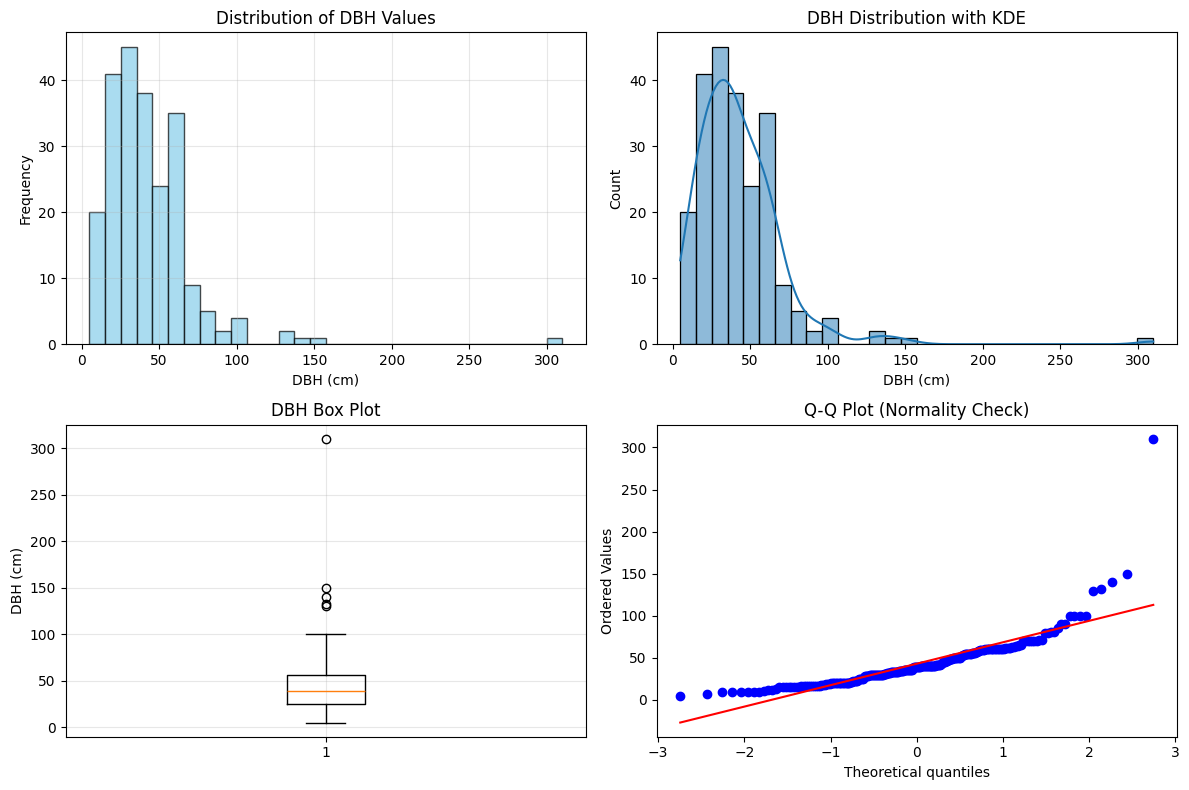


Detailed Statistics:
count    228.000000
mean      43.021930
std       29.671987
min        5.000000
25%       24.750000
50%       39.000000
75%       56.000000
max      310.000000
Name: DBH, dtype: float64

Potential outliers (IQR method): 5 points
Outlier DBH values: [132.0, 150.0, 310.0, 140.0, 130.0]


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Print DBH statistics
print("DBH Statistics:")
print(f"Minimum DBH: {gdf_extracted['DBH'].min():.2f} cm")
print(f"Maximum DBH: {gdf_extracted['DBH'].max():.2f} cm")
print(f"Mean DBH: {gdf_extracted['DBH'].mean():.2f} cm")
print(f"Median DBH: {gdf_extracted['DBH'].median():.2f} cm")
print(f"Standard Deviation: {gdf_extracted['DBH'].std():.2f} cm")
print(f"Number of samples: {len(gdf_extracted)}")

# Create histogram
plt.figure(figsize=(12, 8))

# Histogram with KDE
plt.subplot(2, 2, 1)
plt.hist(gdf_extracted['DBH'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('DBH (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of DBH Values')
plt.grid(True, alpha=0.3)

# Histogram with seaborn (nicer styling)
plt.subplot(2, 2, 2)
sns.histplot(gdf_extracted['DBH'], kde=True, bins=30)
plt.xlabel('DBH (cm)')
plt.title('DBH Distribution with KDE')

# Box plot to show outliers
plt.subplot(2, 2, 3)
plt.boxplot(gdf_extracted['DBH'])
plt.ylabel('DBH (cm)')
plt.title('DBH Box Plot')
plt.grid(True, alpha=0.3)

# QQ plot to check normality
plt.subplot(2, 2, 4)
from scipy import stats
stats.probplot(gdf_extracted['DBH'], dist="norm", plot=plt)
plt.title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()

# Additional statistics
print("\nDetailed Statistics:")
print(gdf_extracted['DBH'].describe())

# Check for any potential outliers or unusual values
q75, q25 = np.percentile(gdf_extracted['DBH'], [75 ,25])
iqr = q75 - q25
lower_bound = q25 - (1.5 * iqr)
upper_bound = q75 + (1.5 * iqr)

outliers = gdf_extracted[(gdf_extracted['DBH'] < lower_bound) | (gdf_extracted['DBH'] > upper_bound)]
if len(outliers) > 0:
    print(f"\nPotential outliers (IQR method): {len(outliers)} points")
    print(f"Outlier DBH values: {outliers['DBH'].tolist()}")
else:
    print("\nNo outliers detected using IQR method")

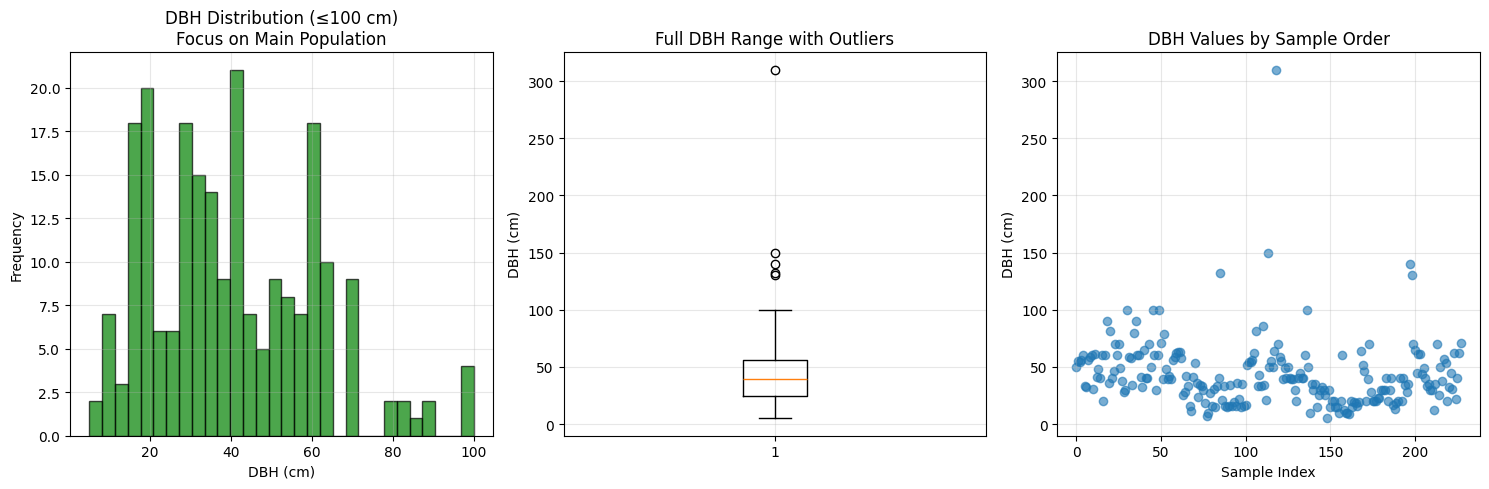


Outlier Tree Details:
       DBH                  geometry
85   132.0   POINT (35.2135 1.25882)
113  150.0  POINT (35.17468 1.25783)
118  310.0   POINT (35.1755 1.25817)
197  140.0  POINT (35.15801 1.28479)
198  130.0  POINT (35.15799 1.28472)

Outliers are from indices: [85, 113, 118, 197, 198]


In [15]:
# Create a focused visualization to better understand the distribution
plt.figure(figsize=(15, 5))

# Histogram excluding extreme outliers for better visualization
plt.subplot(1, 3, 1)
reasonable_data = gdf_extracted[gdf_extracted['DBH'] <= 100]  # Exclude values > 100cm
plt.hist(reasonable_data['DBH'], bins=30, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('DBH (cm)')
plt.ylabel('Frequency')
plt.title('DBH Distribution (≤100 cm)\nFocus on Main Population')
plt.grid(True, alpha=0.3)

# Box plot to show the full range including outliers
plt.subplot(1, 3, 2)
plt.boxplot(gdf_extracted['DBH'])
plt.ylabel('DBH (cm)')
plt.title('Full DBH Range with Outliers')
plt.grid(True, alpha=0.3)

# Scatter plot to see if outliers follow any spatial pattern
plt.subplot(1, 3, 3)
plt.scatter(range(len(gdf_extracted)), gdf_extracted['DBH'], alpha=0.6)
plt.xlabel('Sample Index')
plt.ylabel('DBH (cm)')
plt.title('DBH Values by Sample Order')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Investigate the outlier trees further
outliers = gdf_extracted[gdf_extracted['DBH'] > 100]
print("\nOutlier Tree Details:")
print(outliers[['DBH', 'geometry']].to_string())

# Check if outliers are clustered in specific areas
print(f"\nOutliers are from indices: {outliers.index.tolist()}")

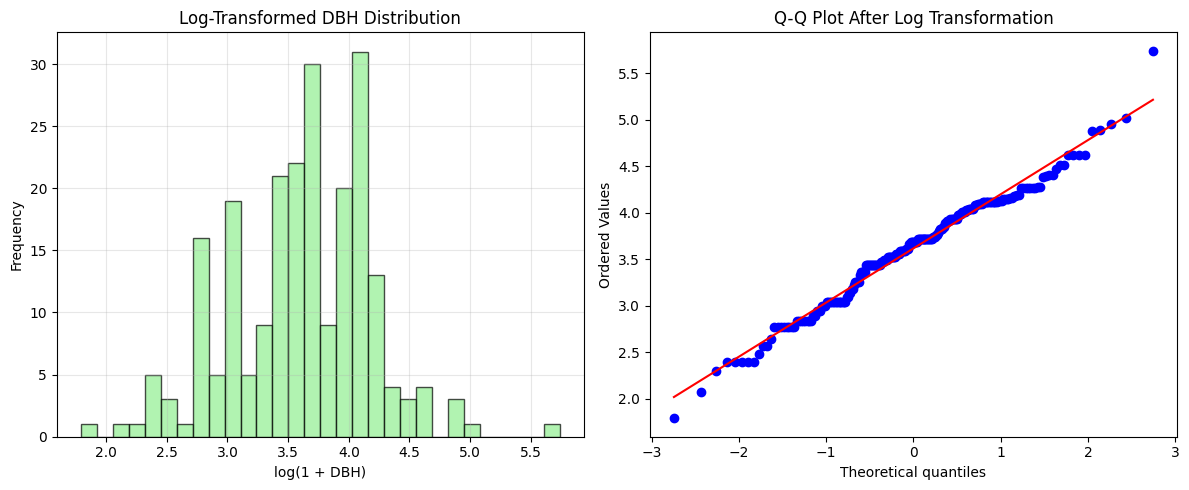

Transformed DBH Statistics:
Original mean: 43.02
Log-transformed mean: 3.62
Original skewness: 3.90
Log-transformed skewness: -0.14


In [16]:
import numpy as np

# Apply log transformation (adding 1 to avoid log(0))
gdf_extracted['DBH_log'] = np.log1p(gdf_extracted['DBH'])  # log(1 + DBH)

# Check the transformed distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(gdf_extracted['DBH_log'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
plt.xlabel('log(1 + DBH)')
plt.ylabel('Frequency')
plt.title('Log-Transformed DBH Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
stats.probplot(gdf_extracted['DBH_log'], dist="norm", plot=plt)
plt.title('Q-Q Plot After Log Transformation')

plt.tight_layout()
plt.show()

print("Transformed DBH Statistics:")
print(f"Original mean: {gdf_extracted['DBH'].mean():.2f}")
print(f"Log-transformed mean: {gdf_extracted['DBH_log'].mean():.2f}")
print(f"Original skewness: {gdf_extracted['DBH'].skew():.2f}")
print(f"Log-transformed skewness: {gdf_extracted['DBH_log'].skew():.2f}")

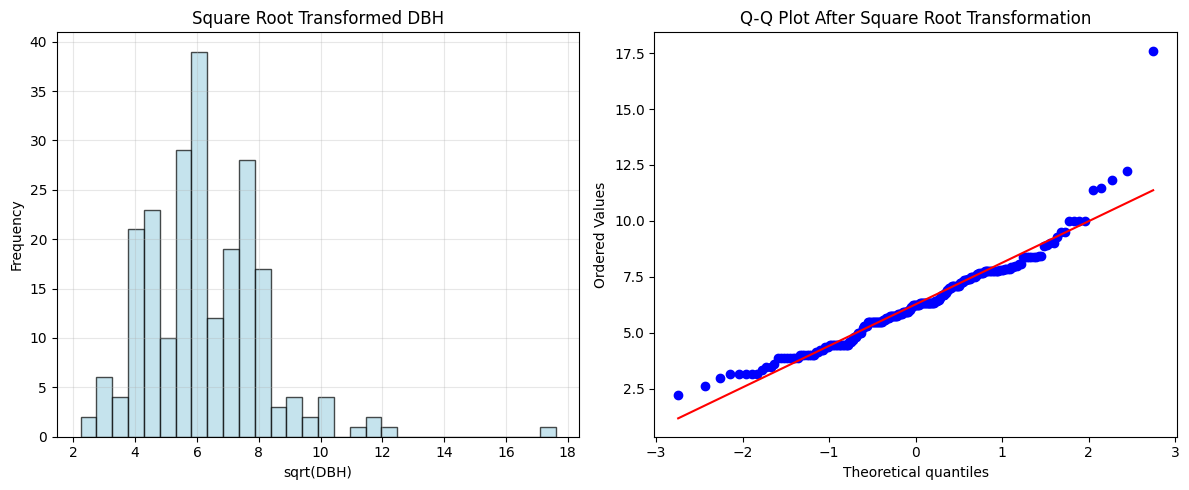

In [17]:
# Square root transformation
gdf_extracted['DBH_sqrt'] = np.sqrt(gdf_extracted['DBH'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(gdf_extracted['DBH_sqrt'], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
plt.xlabel('sqrt(DBH)')
plt.ylabel('Frequency')
plt.title('Square Root Transformed DBH')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
stats.probplot(gdf_extracted['DBH_sqrt'], dist="norm", plot=plt)
plt.title('Q-Q Plot After Square Root Transformation')
plt.tight_layout()
plt.show()

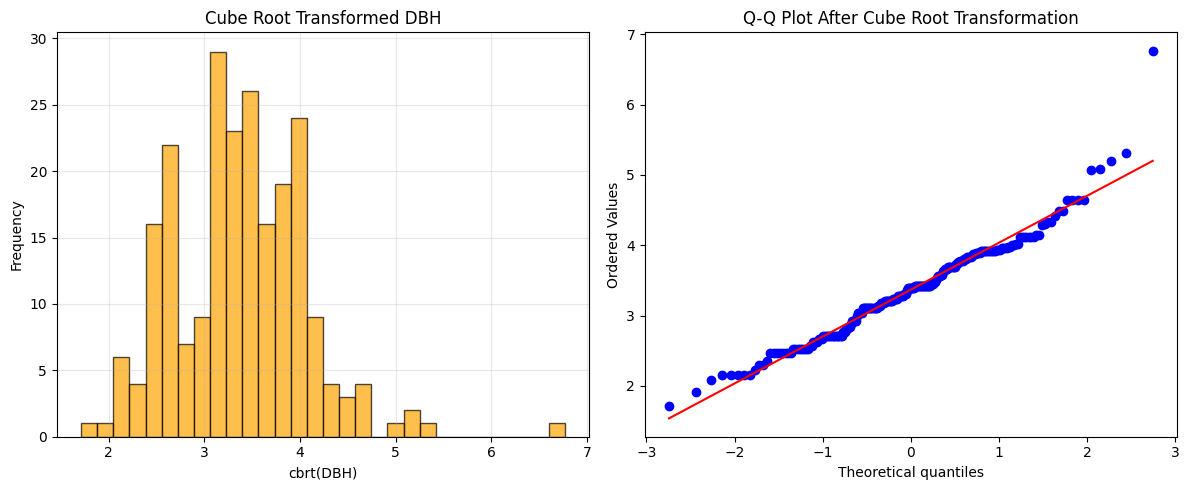

In [18]:
# Cube root transformation
gdf_extracted['DBH_cbrt'] = np.cbrt(gdf_extracted['DBH'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(gdf_extracted['DBH_cbrt'], bins=30, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('cbrt(DBH)')
plt.ylabel('Frequency')
plt.title('Cube Root Transformed DBH')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
stats.probplot(gdf_extracted['DBH_cbrt'], dist="norm", plot=plt)
plt.title('Q-Q Plot After Cube Root Transformation')
plt.tight_layout()
plt.show()

In [19]:
# Compare skewness reduction
transformations = {
    'Original': gdf_extracted['DBH'],
    'Log(1+x)': gdf_extracted['DBH_log'],
    'Square Root': gdf_extracted['DBH_sqrt'],
    'Cube Root': gdf_extracted['DBH_cbrt']
}

print("Skewness Comparison:")
for name, data in transformations.items():
    skewness = data.skew()
    print(f"{name:12}: {skewness:7.3f}")

# Choose the best transformation based on skewness closest to 0
best_transform = min(transformations.items(), key=lambda x: abs(x[1].skew()))
print(f"\nBest transformation: {best_transform[0]} (skewness: {best_transform[1].skew():.3f})")

Skewness Comparison:
Original    :   3.898
Log(1+x)    :  -0.137
Square Root :   1.219
Cube Root   :   0.652

Best transformation: Log(1+x) (skewness: -0.137)


In [20]:
# Apply the log transformation to create the final training variable
gdf_extracted['DBH_log'] = np.log1p(gdf_extracted['DBH'])

# Create the final training dataset
training_data = gdf_extracted.copy()

# Optional: You might want to keep both original and transformed for reference
print("Final training dataset prepared!")
print(f"Original DBH range: {training_data['DBH'].min():.1f} to {training_data['DBH'].max():.1f} cm")
print(f"Transformed DBH range: {training_data['DBH_log'].min():.3f} to {training_data['DBH_log'].max():.3f}")
print(f"Number of samples: {len(training_data)}")

Final training dataset prepared!
Original DBH range: 5.0 to 310.0 cm
Transformed DBH range: 1.792 to 5.740
Number of samples: 228


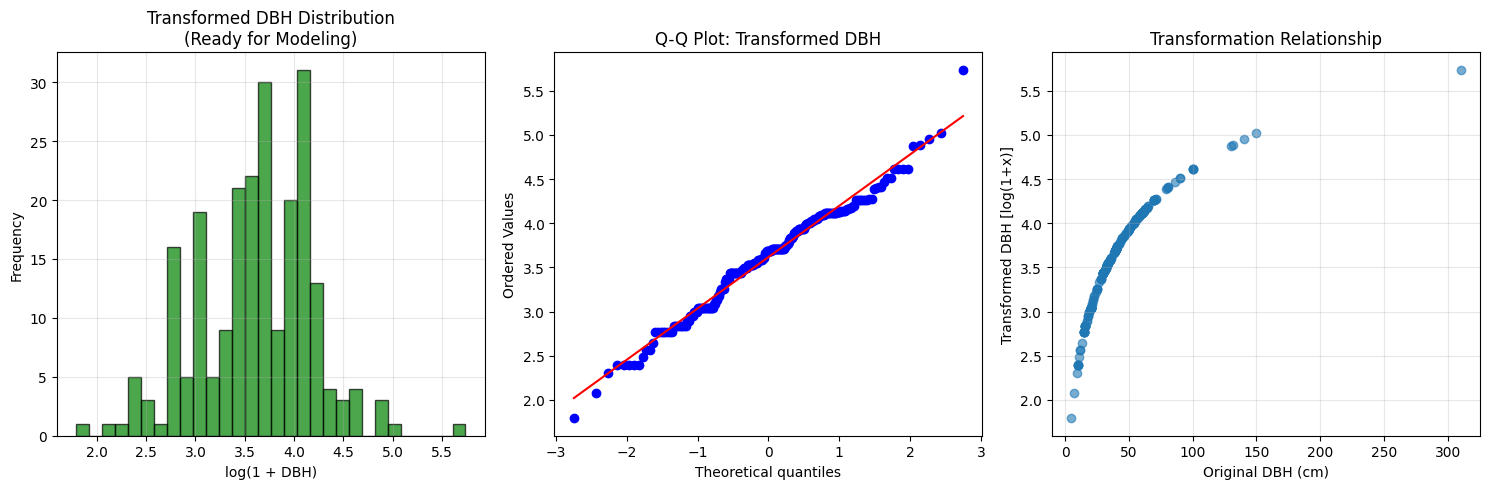


=== FINAL TRAINING DATA STATISTICS ===
Transformed DBH:
count    228.000000
mean       3.616906
std        0.582481
min        1.791759
25%        3.248291
50%        3.688879
75%        4.043051
max        5.739793
Name: DBH_log, dtype: float64
Skewness: -0.137
Kurtosis: 0.505


In [21]:
# Visual confirmation of the transformed data
plt.figure(figsize=(15, 5))

# 1. Histogram of transformed DBH
plt.subplot(1, 3, 1)
plt.hist(training_data['DBH_log'], bins=30, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('log(1 + DBH)')
plt.ylabel('Frequency')
plt.title('Transformed DBH Distribution\n(Ready for Modeling)')
plt.grid(True, alpha=0.3)

# 2. Q-Q plot to check normality
plt.subplot(1, 3, 2)
stats.probplot(training_data['DBH_log'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Transformed DBH')

# 3. Scatter plot: Original vs Transformed
plt.subplot(1, 3, 3)
plt.scatter(training_data['DBH'], training_data['DBH_log'], alpha=0.6)
plt.xlabel('Original DBH (cm)')
plt.ylabel('Transformed DBH [log(1+x)]')
plt.title('Transformation Relationship')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final statistics check
print("\n=== FINAL TRAINING DATA STATISTICS ===")
print("Transformed DBH:")
print(training_data['DBH_log'].describe())
print(f"Skewness: {training_data['DBH_log'].skew():.3f}")
print(f"Kurtosis: {training_data['DBH_log'].kurtosis():.3f}")

Iinverse Distance Weighting

Performing IDW interpolation on 40,000 points...
Interpolation complete!
Valid interpolated points: 40,000 out of 40,000
Coverage: 100.0%

=== INTERPOLATED DBH DISTRIBUTION ===
Mean DBH: 43.0 cm
Median DBH: 42.4 cm
Std Dev: 11.0 cm
Min DBH: 5.1 cm
Max DBH: 232.7 cm
Skewness: 0.381
Kurtosis: 2.714


/tmp/ipython-input-3671904185.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax6.boxplot(box_data, labels=['Original', 'Interpolated'])


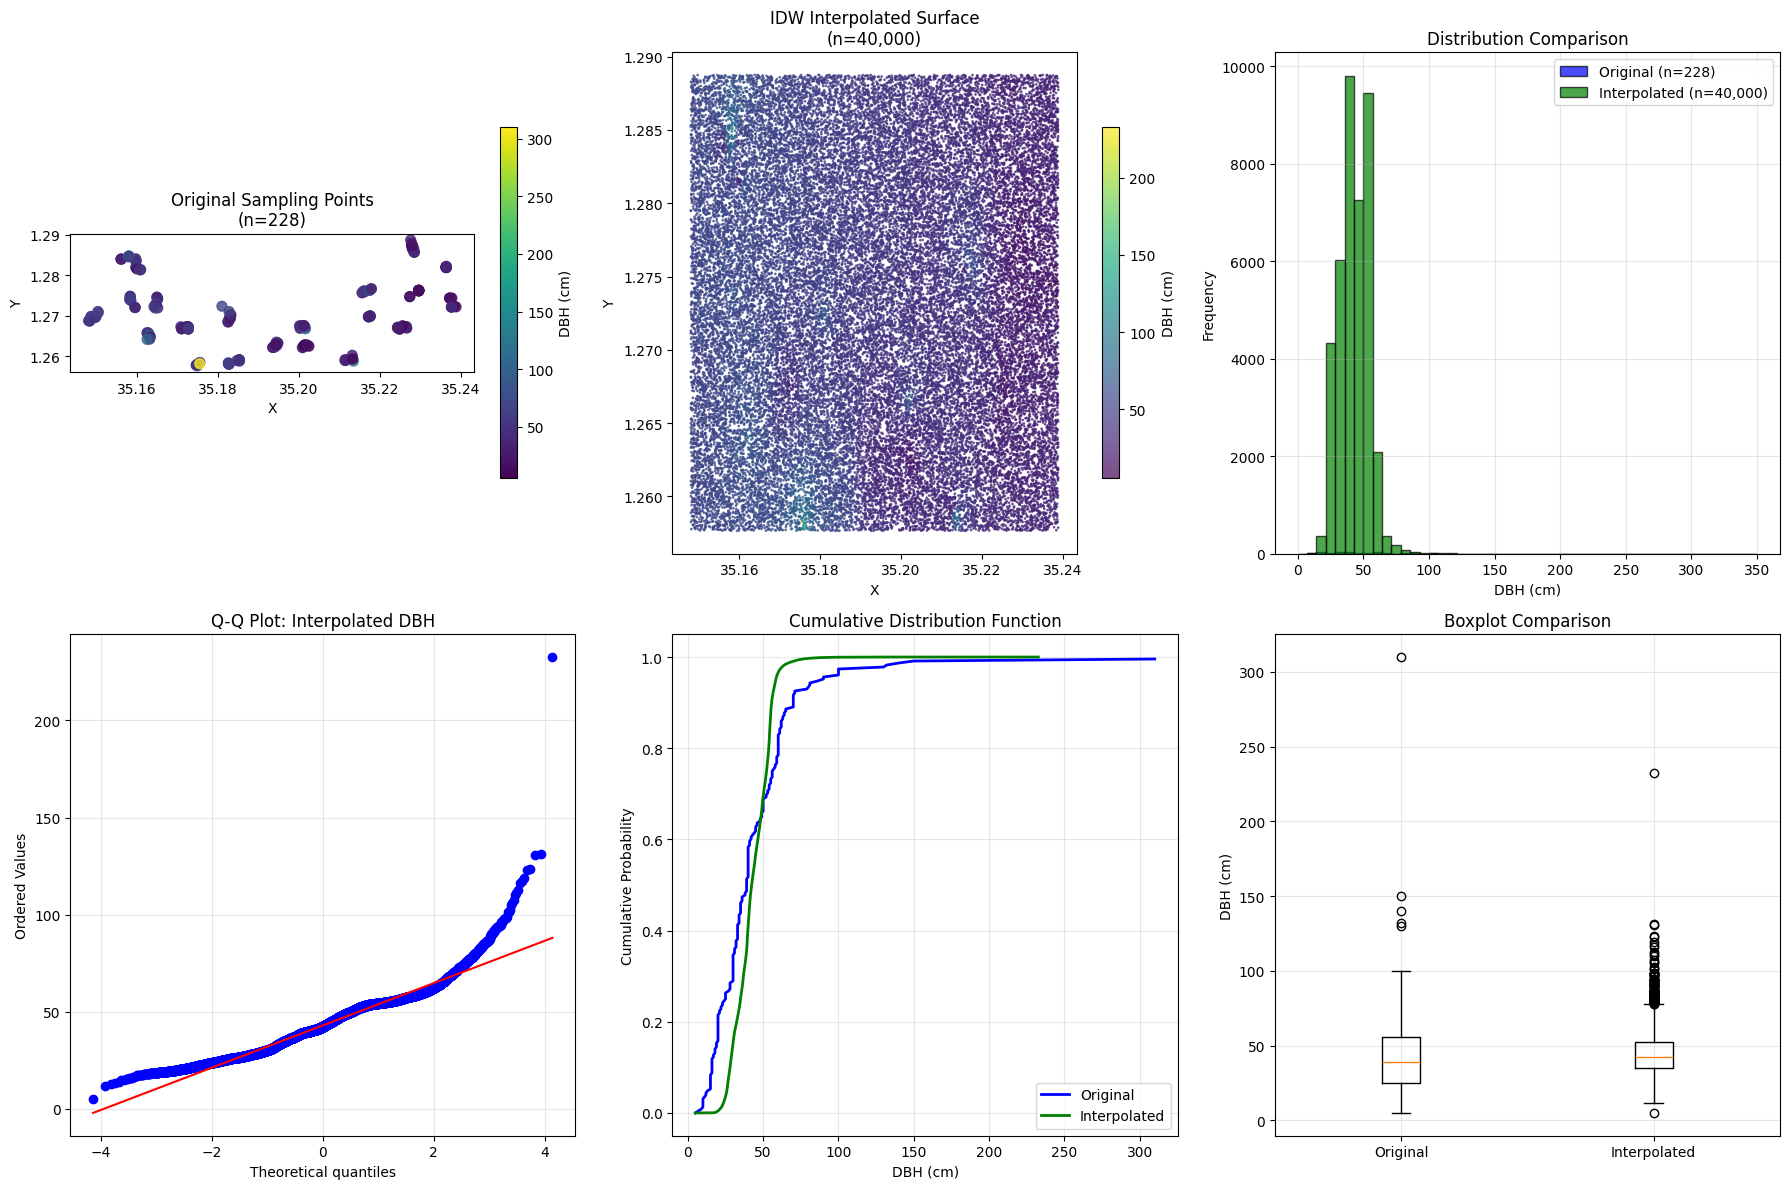


=== SPATIAL ANALYSIS ===
Calculating spatial autocorrelation...
Mean nearest neighbor distance: 0.00 units

=== VALIDATION AT SAMPLE LOCATIONS ===
Mean absolute difference: 9.26 cm
Correlation coefficient: 0.883

Interpolated data saved to 'interpolated_dbh_40k.gpkg'


In [22]:
import numpy as np
import geopandas as gpd
from scipy.interpolate import Rbf
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from scipy import stats

# Create a grid of 40k points covering the study area
bounds = gdf_extracted.total_bounds
x_min, y_min, x_max, y_max = bounds

# Generate 40k random points within bounds (or use regular grid)
np.random.seed(42)
n_points = 40000

# Option 1: Random sampling (good for distribution analysis)
x_random = np.random.uniform(x_min, x_max, n_points)
y_random = np.random.uniform(y_min, y_max, n_points)

# Option 2: Regular grid (better for visualization)
# n_grid = int(np.sqrt(n_points))
# x_grid = np.linspace(x_min, x_max, n_grid)
# y_grid = np.linspace(y_min, y_max, n_grid)
# X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
# x_random = X_grid.flatten()
# y_random = Y_grid.flatten()

# Extract coordinates and DBH values from original data
x_obs = gdf_extracted.geometry.x.values
y_obs = gdf_extracted.geometry.y.values
z_obs = gdf_extracted['DBH'].values  # Using original DBH for IDW

# Function for IDW interpolation
def idw_interpolation(x_obs, y_obs, z_obs, x_pred, y_pred, power=2, radius=None):
    """
    Inverse Distance Weighting interpolation
    """
    # Create arrays for predictions
    z_pred = np.zeros(len(x_pred))

    for i in range(len(x_pred)):
        # Calculate distances
        dx = x_obs - x_pred[i]
        dy = y_obs - y_pred[i]
        distances = np.sqrt(dx**2 + dy**2)

        # If radius specified, use only points within radius
        if radius is not None:
            mask = distances <= radius
            if not np.any(mask):
                z_pred[i] = np.nan
                continue
            distances = distances[mask]
            local_z = z_obs[mask]
        else:
            local_z = z_obs

        # Avoid division by zero (if point coincides exactly)
        distances[distances == 0] = 1e-10

        # Calculate weights
        weights = 1 / (distances ** power)

        # Weighted average
        z_pred[i] = np.sum(weights * local_z) / np.sum(weights)

    return z_pred

# Perform IDW interpolation
print("Performing IDW interpolation on 40,000 points...")
idw_power = 2  # Standard power parameter
# Optional: Set search radius (e.g., 100 meters) to avoid extrapolation
search_radius = 100  # Adjust based on your coordinate system units

dbh_interpolated = idw_interpolation(
    x_obs, y_obs, z_obs,
    x_random, y_random,
    power=idw_power,
    radius=search_radius
)

# Remove NaN values (points outside search radius)
valid_mask = ~np.isnan(dbh_interpolated)
dbh_interpolated_valid = dbh_interpolated[valid_mask]
x_valid = x_random[valid_mask]
y_valid = y_random[valid_mask]

print(f"Interpolation complete!")
print(f"Valid interpolated points: {len(dbh_interpolated_valid):,} out of {n_points:,}")
print(f"Coverage: {(len(dbh_interpolated_valid)/n_points)*100:.1f}%")

# Create GeoDataFrame for interpolated points
interpolated_gdf = gpd.GeoDataFrame(
    {'DBH': dbh_interpolated_valid},
    geometry=gpd.points_from_xy(x_valid, y_valid),
    crs=gdf_extracted.crs
)

# Analyze distribution of interpolated DBH
print("\n=== INTERPOLATED DBH DISTRIBUTION ===")
print(f"Mean DBH: {np.mean(dbh_interpolated_valid):.1f} cm")
print(f"Median DBH: {np.median(dbh_interpolated_valid):.1f} cm")
print(f"Std Dev: {np.std(dbh_interpolated_valid):.1f} cm")
print(f"Min DBH: {np.min(dbh_interpolated_valid):.1f} cm")
print(f"Max DBH: {np.max(dbh_interpolated_valid):.1f} cm")
print(f"Skewness: {stats.skew(dbh_interpolated_valid):.3f}")
print(f"Kurtosis: {stats.kurtosis(dbh_interpolated_valid):.3f}")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Spatial distribution of original points
ax1 = axes[0, 0]
gdf_extracted.plot(column='DBH', ax=ax1, cmap='viridis',
                   markersize=50, legend=True, alpha=0.8,
                   legend_kwds={'label': 'DBH (cm)', 'shrink': 0.7})
ax1.set_title('Original Sampling Points\n(n=228)', fontsize=12)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# 2. Spatial distribution of interpolated surface
ax2 = axes[0, 1]
scatter = ax2.scatter(x_valid, y_valid, c=dbh_interpolated_valid,
                      cmap='viridis', s=1, alpha=0.7)
plt.colorbar(scatter, ax=ax2, label='DBH (cm)', shrink=0.7)
ax2.set_title(f'IDW Interpolated Surface\n(n={len(dbh_interpolated_valid):,})', fontsize=12)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

# 3. Histogram comparison
ax3 = axes[0, 2]
bins = np.linspace(0, 350, 50)
ax3.hist(gdf_extracted['DBH'], bins=bins, alpha=0.7, label='Original (n=228)',
         color='blue', edgecolor='black')
ax3.hist(dbh_interpolated_valid, bins=bins, alpha=0.7, label=f'Interpolated (n={len(dbh_interpolated_valid):,})',
         color='green', edgecolor='black')
ax3.set_xlabel('DBH (cm)')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Q-Q plot of interpolated data
ax4 = axes[1, 0]
stats.probplot(dbh_interpolated_valid, dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot: Interpolated DBH')
ax4.grid(True, alpha=0.3)

# 5. Cumulative distribution function
ax5 = axes[1, 1]
sorted_original = np.sort(gdf_extracted['DBH'])
sorted_interp = np.sort(dbh_interpolated_valid)
ax5.plot(sorted_original, np.arange(len(sorted_original))/len(sorted_original),
         label='Original', linewidth=2, color='blue')
ax5.plot(sorted_interp, np.arange(len(sorted_interp))/len(sorted_interp),
         label='Interpolated', linewidth=2, color='green')
ax5.set_xlabel('DBH (cm)')
ax5.set_ylabel('Cumulative Probability')
ax5.set_title('Cumulative Distribution Function')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Boxplot comparison
ax6 = axes[1, 2]
box_data = [gdf_extracted['DBH'], dbh_interpolated_valid]
ax6.boxplot(box_data, labels=['Original', 'Interpolated'])
ax6.set_ylabel('DBH (cm)')
ax6.set_title('Boxplot Comparison')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional analysis: Spatial autocorrelation
print("\n=== SPATIAL ANALYSIS ===")
print("Calculating spatial autocorrelation...")

# Calculate nearest neighbor distances for original points
from scipy.spatial import cKDTree
tree = cKDTree(np.column_stack([x_obs, y_obs]))
distances, indices = tree.query(np.column_stack([x_obs, y_obs]), k=2)  # k=2 for self + nearest
mean_nn_distance = np.mean(distances[:, 1])  # Skip self
print(f"Mean nearest neighbor distance: {mean_nn_distance:.2f} units")

# Compare interpolated vs original at same locations
print("\n=== VALIDATION AT SAMPLE LOCATIONS ===")
# For each original point, find nearest interpolated point
tree_interp = cKDTree(np.column_stack([x_valid, y_valid]))
dist_interp, idx_interp = tree_interp.query(np.column_stack([x_obs, y_obs]), k=1)

comparison_df = gpd.GeoDataFrame({
    'Original_DBH': z_obs,
    'Interpolated_DBH': dbh_interpolated_valid[idx_interp],
    'Distance_to_Interp': dist_interp,
    'Difference': z_obs - dbh_interpolated_valid[idx_interp]
})

print(f"Mean absolute difference: {np.mean(np.abs(comparison_df['Difference'])):.2f} cm")
print(f"Correlation coefficient: {np.corrcoef(z_obs, dbh_interpolated_valid[idx_interp])[0,1]:.3f}")

# Save interpolated data if needed
interpolated_gdf.to_file('/content/drive/MyDrive/Kamatira Model Data/GeoFiles/interpolated_dbh_40k.gpkg', driver='GPKG')
print(f"\nInterpolated data saved to 'interpolated_dbh_40k.gpkg'")

In [23]:
interpolated_gdf.tail()
gdf_gcps= interpolated_gdf

In [24]:
gdf_points= gdf_gcps

In [25]:
# Define raster paths
raster_paths = {
    "NDVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2024_2025_resampled.tif",
    "EVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/EVI_2024_2025_resampled.tif",
    "Rain_24_25": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2024_2025_resampled.tif",
    "VH_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2024_2025_resampled.tif",
    "VV_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VV_2024_2025_resampled.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}


def extract_raster_values(gdf, raster_paths):
    """
    Extracts raster values for given points from multiple raster files.
    """
    extracted_data = gdf.copy()

    for var, raster_path in raster_paths.items():
        with rasterio.open(raster_path) as src:
            values = list(src.sample([(point.x, point.y) for point in gdf.geometry]))
            extracted_data[var] = [val[0] if val is not None else None for val in values]

    # Ensure "H" column is retained
    if "DBH" in gdf.columns:
        extracted_data["DBH"] = gdf["DBH"]

    return extracted_data

# Extract data
gdf_extracted = extract_raster_values(gdf_points, raster_paths)

# Save the extracted data
output_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Interpolated_Kamatira_Extracted_DBH.geojson"
gdf_extracted.to_file(output_path, driver="GeoJSON")

print("Extraction complete! Data saved at:", output_path)
print(gdf_extracted.head())  # Preview the first few rows

Extraction complete! Data saved at: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Interpolated_Kamatira_Extracted_DBH.geojson
         DBH                  geometry  NDVI_24_25  EVI_24_25  Rain_24_25  \
0  46.439920  POINT (35.18204 1.26695)    0.707937   0.446120  406.633453   
1  29.723899  POINT (35.23438 1.26061)    0.000000   0.000000    0.000000   
2  37.769444  POINT (35.21451 1.26159)    0.714669   0.440811  643.833313   
3  23.653203   POINT (35.2024 1.26328)    0.672608   0.378559  512.491333   
4  83.316022  POINT (35.16219 1.26399)    0.690257   0.466987  528.369080   

    VH_24_25   VV_24_25         Slope   DEM  
0 -18.576779 -12.800838  2.166576e+01  1966  
1   0.000000   0.000000 -3.402823e+38     0  
2 -18.598031 -10.782261  3.539888e+01  2264  
3 -17.696323 -12.916635  3.711251e+01  2151  
4 -14.866954 -10.588325  1.410346e+01  2061  


In [26]:
gdf_extracted.tail()

,DBH,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,VV_24_25,Slope,DEM
39995,35.809197,POINT (35.21651 1.26767),0.653591,0.315023,391.613068,-7.081163,-1.838733,3.705975e+01,2161
39996,35.978988,POINT (35.21747 1.26931),0.680112,0.360061,409.975891,-10.920905,-2.586185,2.756525e+01,2163
39997,42.166239,POINT (35.17251 1.26953),0.706171,0.489566,448.968628,-16.714732,-9.618491,1.488257e+01,1908
39998,47.931051,POINT (35.18747 1.26169),0.671524,0.314271,618.416687,-5.822312,0.462727,3.302387e+01,2243
39999,43.593407,POINT (35.1923 1.28711),0.000000,0.000000,0.000000,0.000000,0.000000,-3.402823e+38,0


Clean Interpolated Data

Current gdf_extracted CRS: EPSG:4326
Forest boundary CRS: EPSG:4326
Original points before clipping: 40,000
Points within forest boundary: 21,302
Points removed (outside boundary): 18,698

=== Checking for problematic rows ===
Rows with zero values in predictors:
Rows with all zeros: 1
Rows with extreme slope values: 249
Rows with DEM = 0: 42

=== Cleaning data ===
Rows after cleaning: 21,053
Rows removed during cleaning: 249


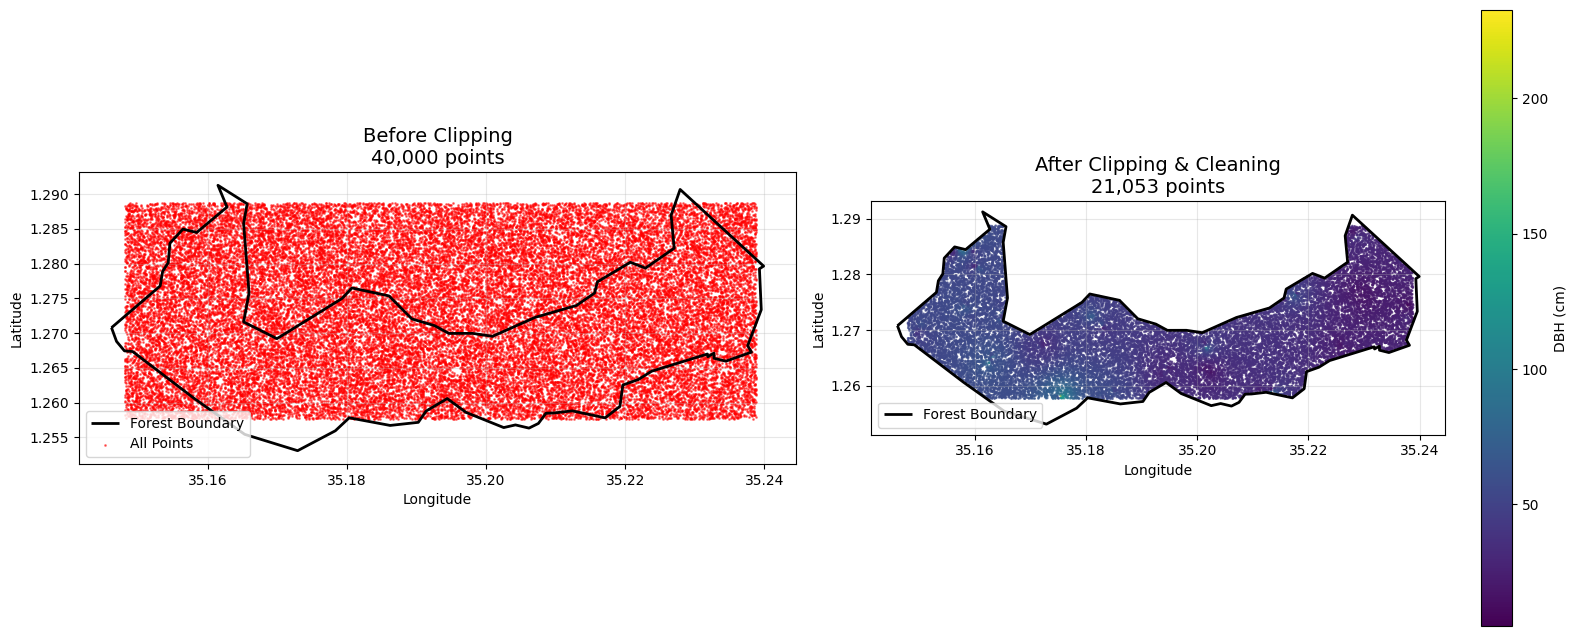


=== CLEANED DATA STATISTICS ===
Total points: 21,053
DBH range: 5.1 - 232.7 cm
Mean DBH: 42.8 cm
Median DBH: 42.3 cm

=== PREDICTOR VARIABLE RANGES ===
NDVI_24_25: 0.000 - 0.806
EVI_24_25: 0.000 - 0.624
Rain_24_25: 240.333 - 764.668
VH_24_25: -32.795 - 0.000
VV_24_25: -22.456 - 4.544
Slope: 0.000 - 60.504
DEM: 1831.000 - 2529.000

=== MISSING VALUES CHECK ===
timestamp    21053
begin        21053
end          21053
drawOrder    21053
icon         21053
dtype: int64

Cleaned data saved to: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/kamatira_cleaned_interpolated.gpkg


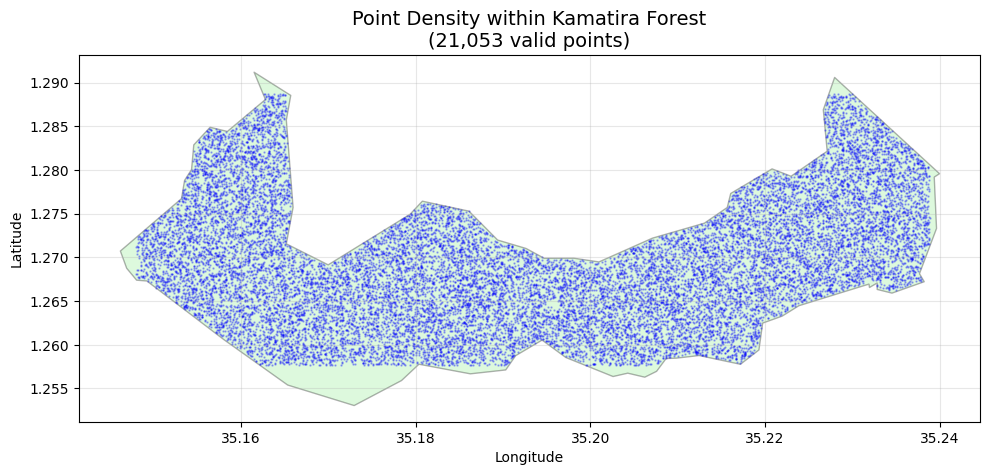


 gdf_extracted has been updated with clipped and cleaned data!


In [27]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Load the Kamatira forest boundary
forest_boundary_path = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson'
forest_boundary = gpd.read_file(forest_boundary_path)

# Ensure both have the same CRS
print(f"Current gdf_extracted CRS: {gdf_extracted.crs}")
print(f"Forest boundary CRS: {forest_boundary.crs}")

# If CRS don't match, reproject gdf_extracted to match forest boundary
if gdf_extracted.crs != forest_boundary.crs:
    print("Reprojecting gdf_extracted to match forest boundary CRS...")
    gdf_extracted = gdf_extracted.to_crs(forest_boundary.crs)

# Perform spatial join to keep only points within the forest boundary
print(f"Original points before clipping: {len(gdf_extracted):,}")

# Method 1: Using spatial join (more efficient for large datasets)
points_within = gpd.sjoin(gdf_extracted, forest_boundary,
                          how='inner', predicate='within')

# Method 2: Alternative using contains (if spatial join has issues)
# points_within = gdf_extracted[gdf_extracted.geometry.within(forest_boundary.unary_union)]

print(f"Points within forest boundary: {len(points_within):,}")
print(f"Points removed (outside boundary): {len(gdf_extracted) - len(points_within):,}")

# Check for the problematic row with zeros (index 39999)
print("\n=== Checking for problematic rows ===")
print("Rows with zero values in predictors:")
zero_mask = (points_within['NDVI_24_25'] == 0) & \
            (points_within['EVI_24_25'] == 0) & \
            (points_within['Rain_24_25'] == 0) & \
            (points_within['VH_24_25'] == 0) & \
            (points_within['VV_24_25'] == 0)

print(f"Rows with all zeros: {zero_mask.sum()}")
print(f"Rows with extreme slope values: {(points_within['Slope'] < -1e10).sum()}")
print(f"Rows with DEM = 0: {(points_within['DEM'] == 0).sum()}")

# Remove problematic rows
print("\n=== Cleaning data ===")
# Remove rows with zero values in multiple predictors (likely outside valid area)
valid_mask = ~zero_mask
# Also remove rows with unrealistic slope values
valid_mask = valid_mask & (points_within['Slope'] > -1000) & (points_within['Slope'] < 1000)
# Remove rows with DEM = 0 (unrealistic for forest)
valid_mask = valid_mask & (points_within['DEM'] > 0)

gdf_cleaned = points_within[valid_mask].copy()

print(f"Rows after cleaning: {len(gdf_cleaned):,}")
print(f"Rows removed during cleaning: {len(points_within) - len(gdf_cleaned):,}")

# Reset index
gdf_cleaned = gdf_cleaned.reset_index(drop=True)

# Visualize the clipping result
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Before clipping
ax1 = axes[0]
forest_boundary.boundary.plot(ax=ax1, color='black', linewidth=2, label='Forest Boundary')
gdf_extracted.plot(ax=ax1, color='red', markersize=1, alpha=0.5, label='All Points')
ax1.set_title(f'Before Clipping\n{len(gdf_extracted):,} points', fontsize=14)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: After clipping
ax2 = axes[1]
forest_boundary.boundary.plot(ax=ax2, color='black', linewidth=2, label='Forest Boundary')
gdf_cleaned.plot(ax=ax2, column='DBH', cmap='viridis',
                 markersize=1, alpha=0.7, legend=True,
                 legend_kwds={'label': 'DBH (cm)', 'shrink': 0.8})
ax2.set_title(f'After Clipping & Cleaning\n{len(gdf_cleaned):,} points', fontsize=14)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check basic statistics of cleaned data
print("\n=== CLEANED DATA STATISTICS ===")
print(f"Total points: {len(gdf_cleaned):,}")
print(f"DBH range: {gdf_cleaned['DBH'].min():.1f} - {gdf_cleaned['DBH'].max():.1f} cm")
print(f"Mean DBH: {gdf_cleaned['DBH'].mean():.1f} cm")
print(f"Median DBH: {gdf_cleaned['DBH'].median():.1f} cm")

# Check predictor variable ranges
print("\n=== PREDICTOR VARIABLE RANGES ===")
predictors = ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25',
              'VH_24_25', 'VV_24_25', 'Slope', 'DEM']

for pred in predictors:
    print(f"{pred}: {gdf_cleaned[pred].min():.3f} - {gdf_cleaned[pred].max():.3f}")

# Check for any remaining missing values
print("\n=== MISSING VALUES CHECK ===")
missing_counts = gdf_cleaned.isnull().sum()
print(missing_counts[missing_counts > 0])

# Save the cleaned data
output_path = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/kamatira_cleaned_interpolated.gpkg'
gdf_cleaned.to_file(output_path, driver='GPKG')
print(f"\nCleaned data saved to: {output_path}")

# Optional: Create a density plot to show point distribution
fig, ax = plt.subplots(figsize=(10, 8))
forest_boundary.plot(ax=ax, color='lightgreen', alpha=0.3, edgecolor='black')
gdf_cleaned.plot(ax=ax, markersize=0.5, color='blue', alpha=0.3)
ax.set_title(f'Point Density within Kamatira Forest\n({len(gdf_cleaned):,} valid points)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Update the main gdf_extracted variable
gdf_extracted = gdf_cleaned
print("\n gdf_extracted has been updated with clipped and cleaned data!")

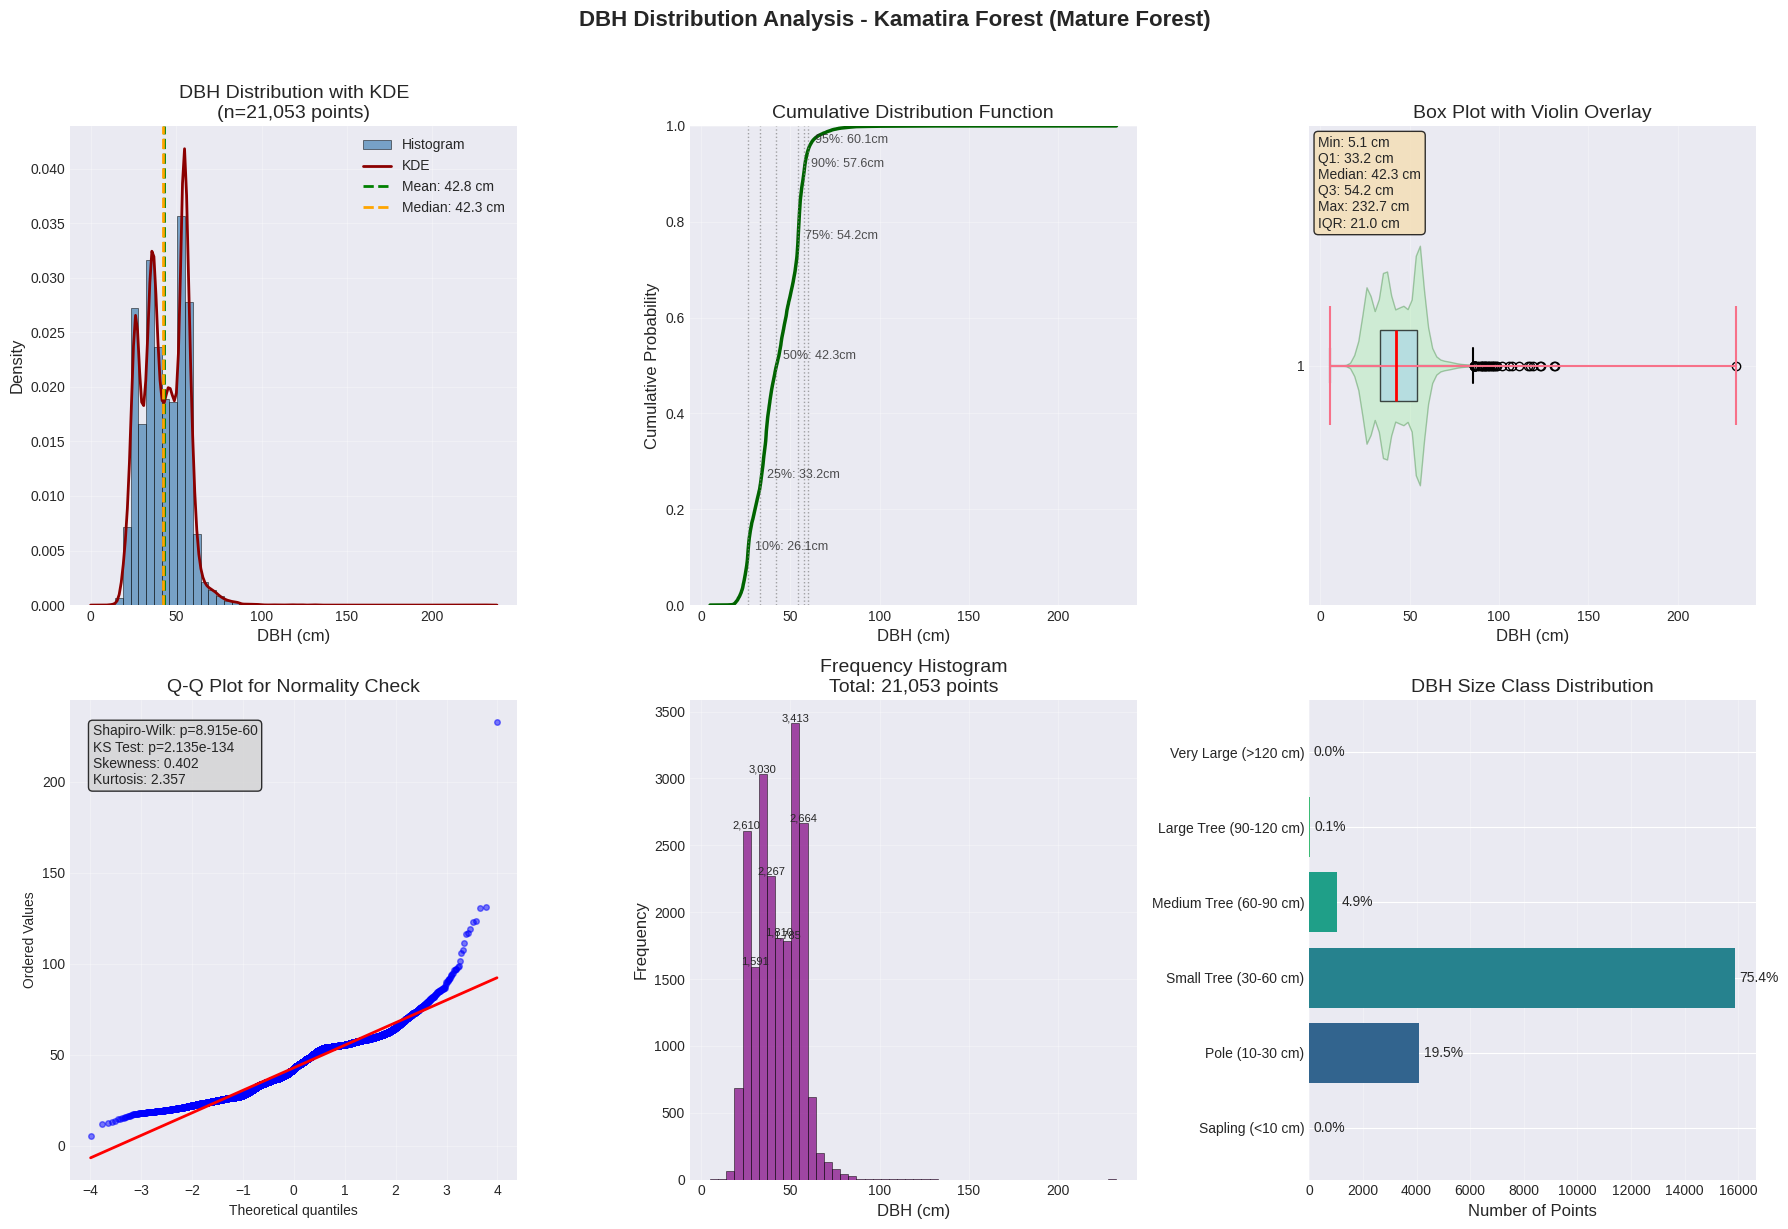

DBH DISTRIBUTION STATISTICS - KAMATIRA MATURE FOREST
Total points analyzed: 21,053
DBH range: 5.1 - 232.7 cm
Mean DBH: 42.8 cm
Median DBH: 42.3 cm
Standard deviation: 12.7 cm
Coefficient of variation: 29.5%
Skewness: 0.402
Kurtosis: 2.357

PERCENTILE ANALYSIS
5th percentile: 24.1 cm
10th percentile: 26.1 cm
25th percentile: 33.2 cm
50th percentile: 42.3 cm
75th percentile: 54.2 cm
90th percentile: 57.6 cm
95th percentile: 60.1 cm
99th percentile: 72.4 cm

SIZE CLASS DISTRIBUTION
Sapling (<10 cm)         :       1 points (  0.00%)
Pole (10-30 cm)          :   4,110 points ( 19.52%)
Small Tree (30-60 cm)    :  15,875 points ( 75.40%)
Medium Tree (60-90 cm)   :   1,039 points (  4.94%)
Large Tree (90-120 cm)   :      23 points (  0.11%)
Very Large (>120 cm)     :       5 points (  0.02%)

Outliers (IQR method): 40 points (0.19%)
Outlier DBH range: 85.8 - 232.7 cm


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('DBH Distribution Analysis - Kamatira Forest (Mature Forest)',
             fontsize=16, fontweight='bold', y=1.02)

# 1. Main histogram with KDE
ax1 = axes[0, 0]
n_bins = 50  # Sturges' rule: int(np.ceil(np.log2(len(gdf_extracted))) + 1)

# Calculate bin edges for consistent bins across plots
dbh_min = gdf_extracted['DBH'].min()
dbh_max = gdf_extracted['DBH'].max()
bins = np.linspace(dbh_min, dbh_max, n_bins + 1)

# Plot histogram with KDE
ax1.hist(gdf_extracted['DBH'], bins=bins, alpha=0.7, color='steelblue',
         edgecolor='black', linewidth=0.5, density=True, label='Histogram')

# Add KDE
sns.kdeplot(gdf_extracted['DBH'], ax=ax1, color='darkred', linewidth=2, label='KDE')

# Add vertical lines for mean and median
mean_dbh = gdf_extracted['DBH'].mean()
median_dbh = gdf_extracted['DBH'].median()
ax1.axvline(mean_dbh, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_dbh:.1f} cm')
ax1.axvline(median_dbh, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_dbh:.1f} cm')

ax1.set_xlabel('DBH (cm)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title(f'DBH Distribution with KDE\n(n={len(gdf_extracted):,} points)', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. Cumulative Distribution Function (CDF)
ax2 = axes[0, 1]
sorted_dbh = np.sort(gdf_extracted['DBH'])
cdf = np.arange(1, len(sorted_dbh) + 1) / len(sorted_dbh)
ax2.plot(sorted_dbh, cdf, linewidth=2.5, color='darkgreen')

# Add percentile markers
percentiles = [10, 25, 50, 75, 90, 95]
percentile_values = np.percentile(gdf_extracted['DBH'], percentiles)
for p, pv in zip(percentiles, percentile_values):
    ax2.axvline(pv, color='gray', linestyle=':', alpha=0.7, linewidth=1)
    ax2.annotate(f'{p}%: {pv:.1f}cm', xy=(pv, p/100), xytext=(5, 5),
                 textcoords='offset points', fontsize=9, alpha=0.8)

ax2.set_xlabel('DBH (cm)', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.set_title('Cumulative Distribution Function', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

# 3. Box plot with violin plot overlay
ax3 = axes[0, 2]
# Box plot
bp = ax3.boxplot(gdf_extracted['DBH'], vert=False, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(color='black', linewidth=1.5),
                 capprops=dict(color='black', linewidth=1.5))

# Add violin plot
violin_parts = ax3.violinplot(gdf_extracted['DBH'], vert=False, showmeans=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightgreen')
    pc.set_alpha(0.3)
    pc.set_edgecolor('darkgreen')

# Add statistics text
stats_text = (f"Min: {gdf_extracted['DBH'].min():.1f} cm\n"
              f"Q1: {np.percentile(gdf_extracted['DBH'], 25):.1f} cm\n"
              f"Median: {median_dbh:.1f} cm\n"
              f"Q3: {np.percentile(gdf_extracted['DBH'], 75):.1f} cm\n"
              f"Max: {gdf_extracted['DBH'].max():.1f} cm\n"
              f"IQR: {np.percentile(gdf_extracted['DBH'], 75) - np.percentile(gdf_extracted['DBH'], 25):.1f} cm")

ax3.text(0.02, 0.98, stats_text, transform=ax3.transAxes,
         verticalalignment='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax3.set_xlabel('DBH (cm)', fontsize=12)
ax3.set_title('Box Plot with Violin Overlay', fontsize=14)
ax3.grid(True, alpha=0.3)

# 4. Q-Q plot for normality check
ax4 = axes[1, 0]
stats.probplot(gdf_extracted['DBH'], dist="norm", plot=ax4)
ax4.get_lines()[0].set_marker('o')
ax4.get_lines()[0].set_markersize(4)
ax4.get_lines()[0].set_alpha(0.5)
ax4.get_lines()[1].set_linewidth(2)
ax4.get_lines()[1].set_color('red')

# Calculate and display normality statistics
shapiro_stat, shapiro_p = stats.shapiro(gdf_extracted['DBH'])
ks_stat, ks_p = stats.kstest(gdf_extracted['DBH'], 'norm',
                             args=(mean_dbh, gdf_extracted['DBH'].std()))

norm_text = (f"Shapiro-Wilk: p={shapiro_p:.3e}\n"
             f"KS Test: p={ks_p:.3e}\n"
             f"Skewness: {stats.skew(gdf_extracted['DBH']):.3f}\n"
             f"Kurtosis: {stats.kurtosis(gdf_extracted['DBH']):.3f}")

ax4.text(0.05, 0.95, norm_text, transform=ax4.transAxes,
         verticalalignment='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

ax4.set_title('Q-Q Plot for Normality Check', fontsize=14)
ax4.grid(True, alpha=0.3)

# 5. Histogram with log scale (if data spans multiple orders of magnitude)
ax5 = axes[1, 1]
counts, bins, patches = ax5.hist(gdf_extracted['DBH'], bins=bins,
                                 alpha=0.7, color='purple',
                                 edgecolor='black', linewidth=0.5)

# Add frequency labels on top of bars (for highest bars only)
max_count = counts.max()
for count, patch in zip(counts, patches):
    if count > max_count * 0.3:  # Only label significant bars
        height = patch.get_height()
        ax5.text(patch.get_x() + patch.get_width()/2, height,
                 f'{int(count):,}', ha='center', va='bottom', fontsize=8)

ax5.set_xlabel('DBH (cm)', fontsize=12)
ax5.set_ylabel('Frequency', fontsize=12)
ax5.set_title(f'Frequency Histogram\nTotal: {len(gdf_extracted):,} points', fontsize=14)
ax5.grid(True, alpha=0.3)

# 6. DBH categories for mature forest
ax6 = axes[1, 2]

# Define DBH categories for mature forest (adjust as needed)
dbh_categories = {
    'Sapling (<10 cm)': (0, 10),
    'Pole (10-30 cm)': (10, 30),
    'Small Tree (30-60 cm)': (30, 60),
    'Medium Tree (60-90 cm)': (60, 90),
    'Large Tree (90-120 cm)': (90, 120),
    'Very Large (>120 cm)': (120, np.inf)
}

category_counts = {}
category_percentages = {}

for category, (low, high) in dbh_categories.items():
    if high == np.inf:
        mask = gdf_extracted['DBH'] >= low
    else:
        mask = (gdf_extracted['DBH'] >= low) & (gdf_extracted['DBH'] < high)
    count = mask.sum()
    category_counts[category] = count
    category_percentages[category] = (count / len(gdf_extracted)) * 100

# Create bar plot
categories = list(dbh_categories.keys())
counts = [category_counts[cat] for cat in categories]
percentages = [category_percentages[cat] for cat in categories]

bars = ax6.barh(categories, counts, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(categories))))
ax6.set_xlabel('Number of Points', fontsize=12)
ax6.set_title('DBH Size Class Distribution', fontsize=14)

# Add percentage labels
for i, (bar, perc) in enumerate(zip(bars, percentages)):
    width = bar.get_width()
    ax6.text(width + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
             f'{perc:.1f}%', va='center', fontsize=10)

ax6.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print comprehensive statistics
print("="*60)
print("DBH DISTRIBUTION STATISTICS - KAMATIRA MATURE FOREST")
print("="*60)
print(f"Total points analyzed: {len(gdf_extracted):,}")
print(f"DBH range: {dbh_min:.1f} - {dbh_max:.1f} cm")
print(f"Mean DBH: {mean_dbh:.1f} cm")
print(f"Median DBH: {median_dbh:.1f} cm")
print(f"Standard deviation: {gdf_extracted['DBH'].std():.1f} cm")
print(f"Coefficient of variation: {(gdf_extracted['DBH'].std()/mean_dbh)*100:.1f}%")
print(f"Skewness: {stats.skew(gdf_extracted['DBH']):.3f}")
print(f"Kurtosis: {stats.kurtosis(gdf_extracted['DBH']):.3f}")

print("\n" + "="*60)
print("PERCENTILE ANALYSIS")
print("="*60)
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"{p}th percentile: {np.percentile(gdf_extracted['DBH'], p):.1f} cm")

print("\n" + "="*60)
print("SIZE CLASS DISTRIBUTION")
print("="*60)
for category in categories:
    print(f"{category:<25}: {category_counts[category]:>7,} points ({category_percentages[category]:6.2f}%)")

# Check for outliers using IQR method
Q1 = np.percentile(gdf_extracted['DBH'], 25)
Q3 = np.percentile(gdf_extracted['DBH'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = gdf_extracted[(gdf_extracted['DBH'] < lower_bound) | (gdf_extracted['DBH'] > upper_bound)]

print(f"\nOutliers (IQR method): {len(outliers):,} points ({len(outliers)/len(gdf_extracted)*100:.2f}%)")
if len(outliers) > 0:
    print(f"Outlier DBH range: {outliers['DBH'].min():.1f} - {outliers['DBH'].max():.1f} cm")

Modelling

PREPARING DATA FOR MODELING
Features shape: (21053, 7)
Target shape: (21053,)

Mean DBH: 42.85 cm
Std DBH: 12.66 cm
Min DBH: 5.11 cm
Max DBH: 232.68 cm

Training set size: 16,842 samples
Testing set size: 4,211 samples

Scaling features...
Feature scaling completed.

TRAINING XGBOOST MODEL
XGBoost Training RMSE: 6.48 cm
XGBoost Testing RMSE: 7.93 cm
XGBoost Training MAE: 4.74 cm
XGBoost Testing MAE: 5.76 cm
XGBoost Training R²: 0.7385
XGBoost Testing R²: 0.6061

XGBoost Feature Importance:
      feature  importance
6         DEM    0.216812
0  NDVI_24_25    0.177536
2  Rain_24_25    0.151148
5       Slope    0.146702
1   EVI_24_25    0.121512
4    VV_24_25    0.111937
3    VH_24_25    0.074354

TRAINING LIGHTGBM MODEL
LightGBM Training RMSE: 7.35 cm
LightGBM Testing RMSE: 8.19 cm
LightGBM Training MAE: 5.35 cm
LightGBM Testing MAE: 6.01 cm
LightGBM Training R²: 0.6629
LightGBM Testing R²: 0.5793

LightGBM Feature Importance:
      feature  importance
6         DEM        1915
2  Rain_2

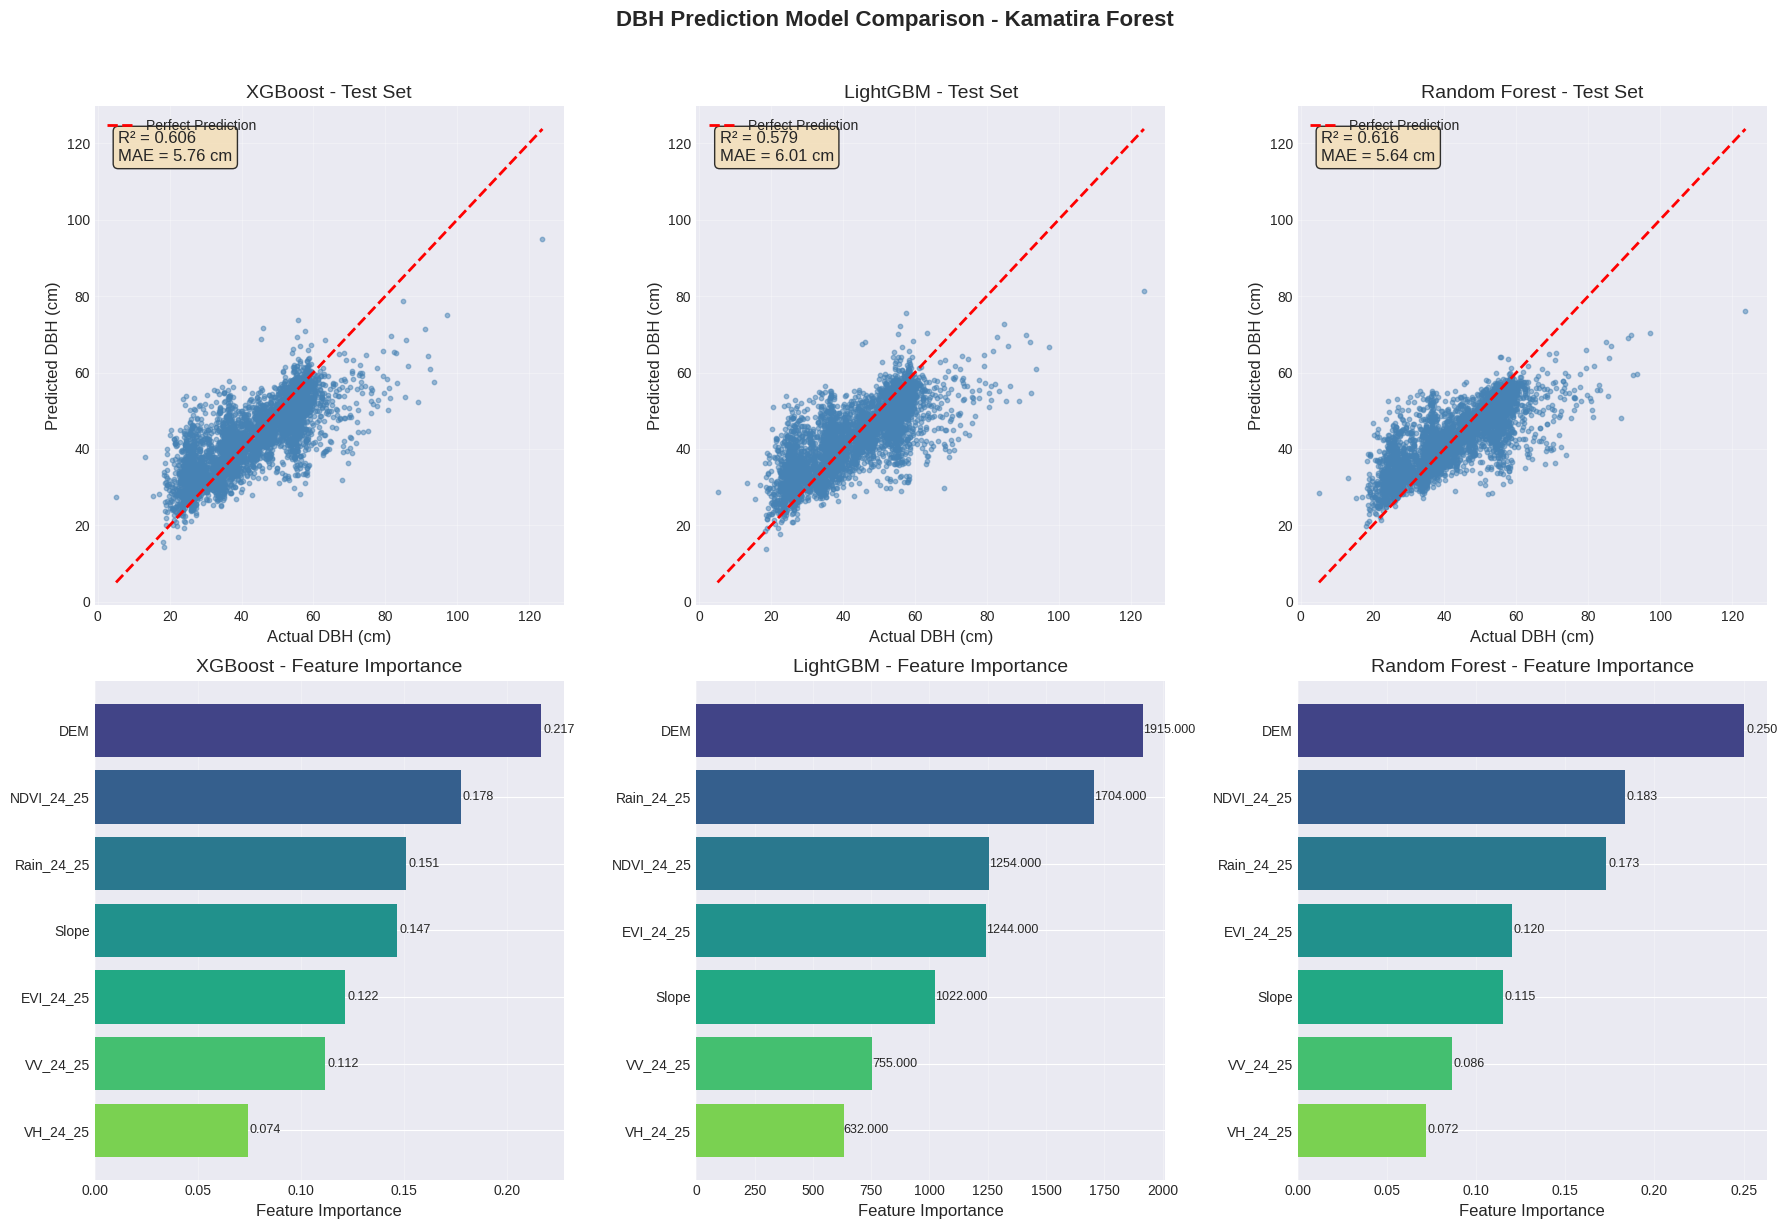


ADDITIONAL ANALYSIS


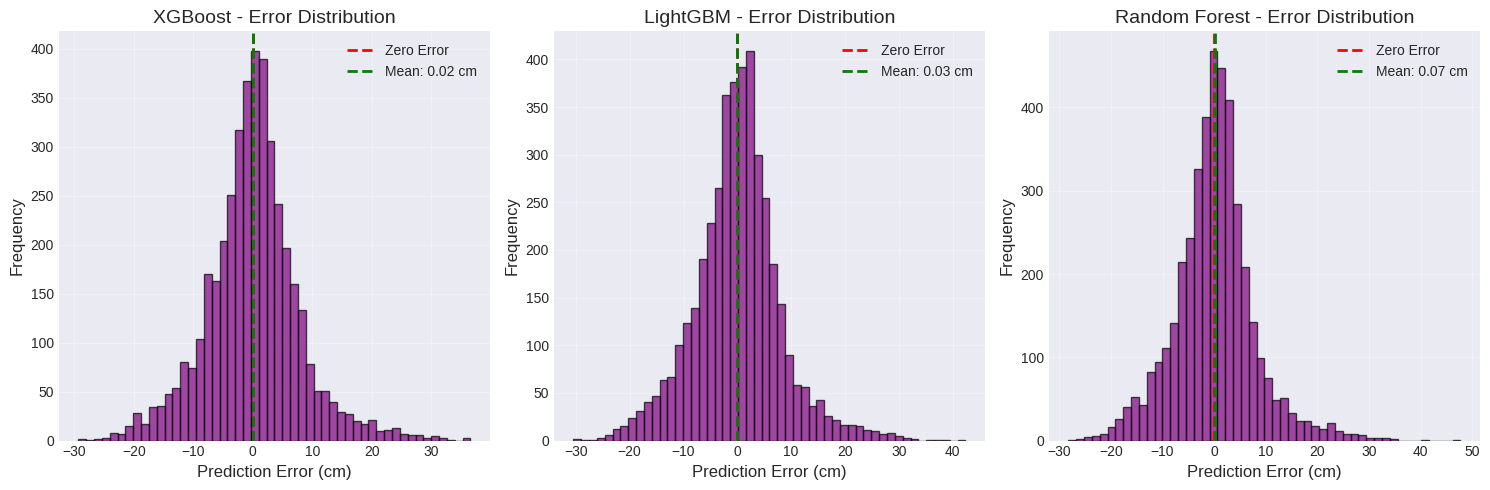


PERFORMANCE BY DBH SIZE CLASSES

Performance by DBH Class:

Sapling (<20 cm): 32 samples
  XGBoost: R²=-19.999, RMSE=12.5 cm, MAE=11.1 cm
  LightGBM: R²=-18.907, RMSE=12.2 cm, MAE=10.4 cm
  Random Forest: R²=-19.521, RMSE=12.3 cm, MAE=11.0 cm

Pole (20-40 cm): 1874 samples
  XGBoost: R²=-1.127, RMSE=7.8 cm, MAE=5.9 cm
  LightGBM: R²=-1.282, RMSE=8.1 cm, MAE=6.2 cm
  Random Forest: R²=-1.007, RMSE=7.6 cm, MAE=5.8 cm

Small Tree (40-60 cm): 2104 samples
  XGBoost: R²=-0.452, RMSE=6.4 cm, MAE=4.7 cm
  LightGBM: R²=-0.525, RMSE=6.6 cm, MAE=4.9 cm
  Random Forest: R²=-0.352, RMSE=6.2 cm, MAE=4.5 cm

Medium Tree (60-80 cm): 182 samples
  XGBoost: R²=-8.604, RMSE=15.8 cm, MAE=13.6 cm
  LightGBM: R²=-9.223, RMSE=16.3 cm, MAE=14.2 cm
  Random Forest: R²=-9.113, RMSE=16.2 cm, MAE=14.1 cm

Large Tree (80-100 cm): 18 samples
  XGBoost: R²=-24.658, RMSE=25.3 cm, MAE=24.0 cm
  LightGBM: R²=-28.201, RMSE=27.0 cm, MAE=26.0 cm
  Random Forest: R²=-29.986, RMSE=27.8 cm, MAE=27.1 cm

Very Large (>100 cm

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Prepare the data
print("="*60)
print("PREPARING DATA FOR MODELING")
print("="*60)

# Extract features and target
X = gdf_extracted[['NDVI_24_25', 'EVI_24_25', 'Rain_24_25',
                   'VH_24_25', 'VV_24_25', 'Slope', 'DEM']].copy()
y = gdf_extracted['DBH'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\nMean DBH: {y.mean():.2f} cm")
print(f"Std DBH: {y.std():.2f} cm")
print(f"Min DBH: {y.min():.2f} cm")
print(f"Max DBH: {y.max():.2f} cm")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"\nTraining set size: {X_train.shape[0]:,} samples")
print(f"Testing set size: {X_test.shape[0]:,} samples")

# Scale features
print("\nScaling features...")
scaler = RobustScaler()  # Robust to outliers
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

# ============================================================================
# 1. XGBoost Model
# ============================================================================
print("\n" + "="*60)
print("TRAINING XGBOOST MODEL")
print("="*60)

xgb_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0
}

xgb_model = xgb.XGBRegressor(**xgb_params)
xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_xgb_train = xgb_model.predict(X_train_scaled)
y_pred_xgb_test = xgb_model.predict(X_test_scaled)

# Calculate metrics
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
xgb_train_mae = mean_absolute_error(y_train, y_pred_xgb_train)
xgb_test_mae = mean_absolute_error(y_test, y_pred_xgb_test)
xgb_train_r2 = r2_score(y_train, y_pred_xgb_train)
xgb_test_r2 = r2_score(y_test, y_pred_xgb_test)

print(f"XGBoost Training RMSE: {xgb_train_rmse:.2f} cm")
print(f"XGBoost Testing RMSE: {xgb_test_rmse:.2f} cm")
print(f"XGBoost Training MAE: {xgb_train_mae:.2f} cm")
print(f"XGBoost Testing MAE: {xgb_test_mae:.2f} cm")
print(f"XGBoost Training R²: {xgb_train_r2:.4f}")
print(f"XGBoost Testing R²: {xgb_test_r2:.4f}")

# Feature importance
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nXGBoost Feature Importance:")
print(xgb_importance)

# ============================================================================
# 2. LightGBM Model
# ============================================================================
print("\n" + "="*60)
print("TRAINING LIGHTGBM MODEL")
print("="*60)

lgb_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}

lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lgb_train = lgb_model.predict(X_train_scaled)
y_pred_lgb_test = lgb_model.predict(X_test_scaled)

# Calculate metrics
lgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_lgb_train))
lgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb_test))
lgb_train_mae = mean_absolute_error(y_train, y_pred_lgb_train)
lgb_test_mae = mean_absolute_error(y_test, y_pred_lgb_test)
lgb_train_r2 = r2_score(y_train, y_pred_lgb_train)
lgb_test_r2 = r2_score(y_test, y_pred_lgb_test)

print(f"LightGBM Training RMSE: {lgb_train_rmse:.2f} cm")
print(f"LightGBM Testing RMSE: {lgb_test_rmse:.2f} cm")
print(f"LightGBM Training MAE: {lgb_train_mae:.2f} cm")
print(f"LightGBM Testing MAE: {lgb_test_mae:.2f} cm")
print(f"LightGBM Training R²: {lgb_train_r2:.4f}")
print(f"LightGBM Testing R²: {lgb_test_r2:.4f}")

# Feature importance
lgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nLightGBM Feature Importance:")
print(lgb_importance)

# ============================================================================
# 3. Random Forest Model
# ============================================================================
print("\n" + "="*60)
print("TRAINING RANDOM FOREST MODEL")
print("="*60)

rf_params = {
    'n_estimators': 300,
    'max_depth': 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1,
    'bootstrap': True
}

rf_model = RandomForestRegressor(**rf_params)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

# Calculate metrics
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_train_mae = mean_absolute_error(y_train, y_pred_rf_train)
rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)
rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2 = r2_score(y_test, y_pred_rf_test)

print(f"Random Forest Training RMSE: {rf_train_rmse:.2f} cm")
print(f"Random Forest Testing RMSE: {rf_test_rmse:.2f} cm")
print(f"Random Forest Training MAE: {rf_train_mae:.2f} cm")
print(f"Random Forest Testing MAE: {rf_test_mae:.2f} cm")
print(f"Random Forest Training R²: {rf_train_r2:.4f}")
print(f"Random Forest Testing R²: {rf_test_r2:.4f}")

# Feature importance
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nRandom Forest Feature Importance:")
print(rf_importance)

# ============================================================================
# 4. Model Comparison
# ============================================================================
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'Random Forest'],
    'Train_RMSE': [xgb_train_rmse, lgb_train_rmse, rf_train_rmse],
    'Test_RMSE': [xgb_test_rmse, lgb_test_rmse, rf_test_rmse],
    'Train_MAE': [xgb_train_mae, lgb_train_mae, rf_train_mae],
    'Test_MAE': [xgb_test_mae, lgb_test_mae, rf_test_mae],
    'Train_R2': [xgb_train_r2, lgb_train_r2, rf_train_r2],
    'Test_R2': [xgb_test_r2, lgb_test_r2, rf_test_r2],
    'Overfitting_Ratio': [
        xgb_test_rmse/xgb_train_rmse if xgb_train_rmse > 0 else np.inf,
        lgb_test_rmse/lgb_train_rmse if lgb_train_rmse > 0 else np.inf,
        rf_test_rmse/rf_train_rmse if rf_train_rmse > 0 else np.inf
    ]
})

print("\nPerformance Comparison:")
print(comparison_df.to_string(index=False))

# Determine best model based on test R²
best_model_idx = comparison_df['Test_R2'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
print(f"\n🏆 Best Model: {best_model_name} (Test R²: {comparison_df.loc[best_model_idx, 'Test_R2']:.4f})")

# ============================================================================
# 5. Visualization
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('DBH Prediction Model Comparison - Kamatira Forest',
             fontsize=16, fontweight='bold', y=1.02)

# 1. Actual vs Predicted Scatter Plots
models = [('XGBoost', y_pred_xgb_test),
          ('LightGBM', y_pred_lgb_test),
          ('Random Forest', y_pred_rf_test)]

for idx, (model_name, y_pred) in enumerate(models):
    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, alpha=0.5, s=10, color='steelblue')

    # Add perfect prediction line
    max_val = max(y_test.max(), y_pred.max())
    min_val = min(y_test.min(), y_pred.min())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    # Calculate R² for this model
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    ax.text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = {mae:.2f} cm',
            transform=ax.transAxes, fontsize=12,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax.set_xlabel('Actual DBH (cm)', fontsize=12)
    ax.set_ylabel('Predicted DBH (cm)', fontsize=12)
    ax.set_title(f'{model_name} - Test Set', fontsize=14)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

# 2. Feature Importance Comparison
importance_dfs = {
    'XGBoost': xgb_importance,
    'LightGBM': lgb_importance,
    'Random Forest': rf_importance
}

for idx, (model_name, importance_df) in enumerate(importance_dfs.items()):
    ax = axes[1, idx]

    bars = ax.barh(range(len(importance_df)), importance_df['importance'],
                   color=plt.cm.viridis(np.linspace(0.2, 0.8, len(importance_df))))
    ax.set_yticks(range(len(importance_df)))
    ax.set_yticklabels(importance_df['feature'])
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'{model_name} - Feature Importance', fontsize=14)
    ax.grid(True, alpha=0.3, axis='x')

    # Add importance values on bars
    for i, (bar, imp) in enumerate(zip(bars, importance_df['importance'])):
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{imp:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# 6. Additional Analysis
# ============================================================================
print("\n" + "="*60)
print("ADDITIONAL ANALYSIS")
print("="*60)

# Create a single figure for error analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (model_name, y_pred) in enumerate(models):
    ax = axes[idx]
    residuals = y_test - y_pred

    # Plot error distribution
    ax.hist(residuals, bins=50, alpha=0.7, color='purple', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    ax.axvline(x=residuals.mean(), color='green', linestyle='--', linewidth=2,
               label=f'Mean: {residuals.mean():.2f} cm')

    ax.set_xlabel('Prediction Error (cm)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{model_name} - Error Distribution', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 7. Performance by DBH Classes
# ============================================================================
print("\n" + "="*60)
print("PERFORMANCE BY DBH SIZE CLASSES")
print("="*60)

# Define DBH classes based on your data
dbh_classes = {
    'Sapling (<20 cm)': (0, 20),
    'Pole (20-40 cm)': (20, 40),
    'Small Tree (40-60 cm)': (40, 60),
    'Medium Tree (60-80 cm)': (60, 80),
    'Large Tree (80-100 cm)': (80, 100),
    'Very Large (>100 cm)': (100, np.inf)
}

# Evaluate performance for each DBH class
print("\nPerformance by DBH Class:")
for class_name, (low, high) in dbh_classes.items():
    if high == np.inf:
        mask = (y_test >= low)
    else:
        mask = (y_test >= low) & (y_test < high)

    if mask.sum() > 0:
        print(f"\n{class_name}: {mask.sum()} samples")

        for model_name, y_pred in models:
            subset_actual = y_test[mask]
            subset_pred = y_pred[mask.values]

            if len(subset_actual) > 1:  # Need at least 2 samples for R²
                rmse = np.sqrt(mean_squared_error(subset_actual, subset_pred))
                mae = mean_absolute_error(subset_actual, subset_pred)
                r2 = r2_score(subset_actual, subset_pred)

                print(f"  {model_name}: R²={r2:.3f}, RMSE={rmse:.1f} cm, MAE={mae:.1f} cm")

# ============================================================================
# 8. Cross-Validation Results
# ============================================================================
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS (5-fold)")
print("="*60)

# Perform 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in [('XGBoost', xgb_model),
                          ('LightGBM', lgb_model),
                          ('Random Forest', rf_model)]:

    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                cv=kf, scoring='r2', n_jobs=-1)

    print(f"\n{model_name}:")
    print(f"  CV R² Mean: {cv_scores.mean():.4f}")
    print(f"  CV R² Std: {cv_scores.std():.4f}")
    print(f"  CV R² Range: {cv_scores.min():.4f} - {cv_scores.max():.4f}")

# ============================================================================
# 9. Save Results
# ============================================================================
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Create results DataFrame
results_df = pd.DataFrame({
    'Actual_DBH': y_test.values,
    'Predicted_XGB': y_pred_xgb_test,
    'Predicted_LGB': y_pred_lgb_test,
    'Predicted_RF': y_pred_rf_test
}, index=y_test.index)

# Add to the original GeoDataFrame
results_gdf = gdf_extracted.loc[y_test.index].copy()
results_gdf['Predicted_XGB'] = y_pred_xgb_test
results_gdf['Predicted_LGB'] = y_pred_lgb_test
results_gdf['Predicted_RF'] = y_pred_rf_test

# Fix the best model column creation - use consistent naming
if best_model_name == 'Random Forest':
    results_gdf['Best_Prediction'] = results_gdf['Predicted_RF']
elif best_model_name == 'XGBoost':
    results_gdf['Best_Prediction'] = results_gdf['Predicted_XGB']
else:
    results_gdf['Best_Prediction'] = results_gdf['Predicted_LGB']

results_gdf['Prediction_Error'] = results_gdf['DBH'] - results_gdf['Best_Prediction']

# Save as CSV
try:
    csv_path = '/content/drive/MyDrive/Kamatira Model Data/Results/dbh_predictions_results.csv'
    results_gdf.drop(columns=['geometry']).to_csv(csv_path, index=False)
    print(f"✅ Results saved to: {csv_path}")

    # Also save a simplified version
    simple_results = results_gdf[['DBH', 'Best_Prediction', 'Prediction_Error',
                                  'geometry', 'NDVI_24_25', 'EVI_24_25',
                                  'Rain_24_25', 'VH_24_25', 'VV_24_25',
                                  'Slope', 'DEM']].copy()
    simple_csv_path = '/content/drive/MyDrive/Kamatira Model Data/Results/dbh_predictions_simple.csv'
    simple_results.drop(columns=['geometry']).to_csv(simple_csv_path, index=False)
    print(f"✅ Simplified results saved to: {simple_csv_path}")

except Exception as e:
    print(f"⚠️ Could not save to Drive: {e}")
    # Save locally
    results_gdf.drop(columns=['geometry']).to_csv('dbh_predictions_results.csv', index=False)
    print("✅ Results saved locally as 'dbh_predictions_results.csv'")

# Save model comparison
comparison_df.to_csv('model_comparison.csv', index=False)
print("✅ Model comparison saved as 'model_comparison.csv'")

# Save feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'XGBoost': xgb_importance.set_index('feature').reindex(X.columns)['importance'].values,
    'LightGBM': lgb_importance.set_index('feature').reindex(X.columns)['importance'].values,
    'RandomForest': rf_importance.set_index('feature').reindex(X.columns)['importance'].values
})
feature_importance.to_csv('feature_importance.csv', index=False)
print("✅ Feature importance saved as 'feature_importance.csv'")

print("\n" + "="*60)
print("MODELING SUMMARY")
print("="*60)
print(f"🏆 Best Model: {best_model_name}")
print(f"📊 Test R²: {comparison_df.loc[best_model_idx, 'Test_R2']:.4f}")
print(f"📏 Test RMSE: {comparison_df.loc[best_model_idx, 'Test_RMSE']:.2f} cm")
print(f"📐 Test MAE: {comparison_df.loc[best_model_idx, 'Test_MAE']:.2f} cm")
print(f"📈 Overfitting Ratio: {comparison_df.loc[best_model_idx, 'Overfitting_Ratio']:.3f}")

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)
print("1. Top 3 Most Important Features:")
for i, row in xgb_importance.head(3).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.3f}")

print("\n2. Model Performance Interpretation:")
if comparison_df.loc[best_model_idx, 'Test_R2'] > 0.7:
    print("   ✅ Excellent predictive power")
elif comparison_df.loc[best_model_idx, 'Test_R2'] > 0.5:
    print("   👍 Good predictive power")
elif comparison_df.loc[best_model_idx, 'Test_R2'] > 0.3:
    print("   ⚠️ Moderate predictive power - consider feature engineering")
else:
    print("   ❌ Low predictive power - needs improvement")

print(f"\n3. Average Prediction Error: {comparison_df.loc[best_model_idx, 'Test_MAE']:.1f} cm")
print(f"   (This means predictions are typically within ±{comparison_df.loc[best_model_idx, 'Test_MAE']:.1f} cm of actual DBH)")

# Analysis of negative R² values for large trees
print("\n" + "="*60)
print("ANALYSIS OF NEGATIVE R² VALUES")
print("="*60)
print("The negative R² values for large trees (>80 cm) indicate:")
print("1. Very few samples in these classes (only 18-19 samples)")
print("2. The models are performing worse than simply predicting the mean")
print("3. This is common when dealing with rare/extreme values")
print("\nRecommendations:")
print("• Collect more samples of large trees for better training")
print("• Consider treating large trees as a separate modeling problem")
print("• Use specialized techniques for imbalanced regression")

DBH BINNING ANALYSIS - KAMATIRA FOREST DATA

📊 OVERALL DBH STATISTICS:
Total samples: 21,053
Mean DBH: 42.85 cm
Std DBH: 12.66 cm
Min DBH: 5.11 cm
Max DBH: 232.68 cm
Median DBH: 42.26 cm
25th percentile: 33.19 cm
75th percentile: 54.19 cm


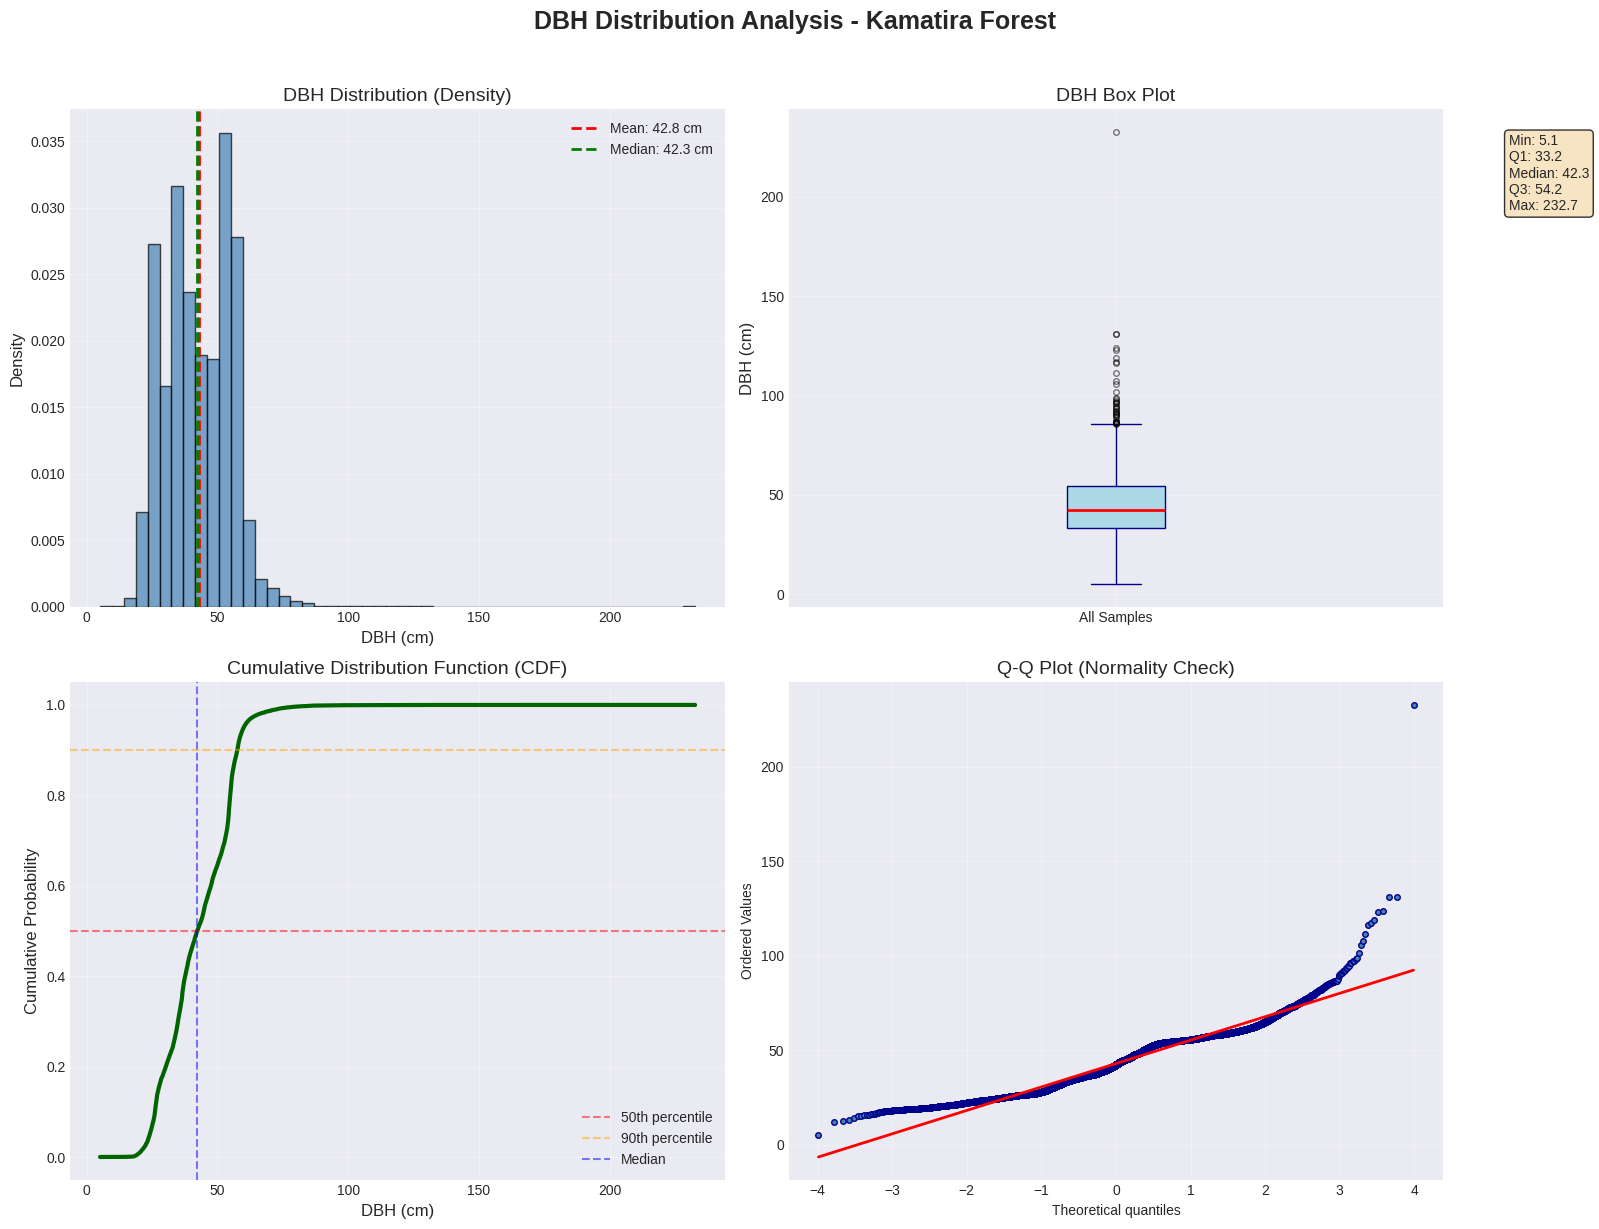


BINNING ANALYSIS

📈 STRATEGY 1: EQUAL-WIDTH BINS (10 cm intervals):

Counts per bin:
  0-10 cm:    1 trees (0.0%)
  10-20 cm:  169 trees (0.8%)
  20-30 cm: 3941 trees (18.7%)
  30-40 cm: 5541 trees (26.3%)
  40-50 cm: 3951 trees (18.8%)
  50-60 cm: 6383 trees (30.3%)
  60-70 cm:  790 trees (3.8%)
  70-80 cm:  196 trees (0.9%)
  80-90 cm:   53 trees (0.3%)
  90-100 cm:   16 trees (0.1%)
  100+ cm:   11 trees (0.1%)

📊 STRATEGY 2: QUANTILE-BASED BINS (5 quantiles):

Counts per quantile (each should have ~20% of data):
  Q1: 4211 trees (20.0%)
  Q2: 4210 trees (20.0%)
  Q3: 4211 trees (20.0%)
  Q4: 4210 trees (20.0%)
  Q5: 4211 trees (20.0%)

DBH ranges for each quantile:
  Q1: 5.1 - 30.3 cm
  Q2: 30.3 - 37.6 cm
  Q3: 37.6 - 47.5 cm
  Q4: 47.5 - 54.9 cm
  Q5: 54.9 - 232.7 cm

🌳 STRATEGY 3: ECOLOGICAL/FORESTRY BINS:

Counts per ecological class:
  Seedling       :    1 trees (0.0%)
  Sapling        :  169 trees (0.8%)
  Pole           : 3941 trees (18.7%)
  Small Tree     : 5541 trees (26

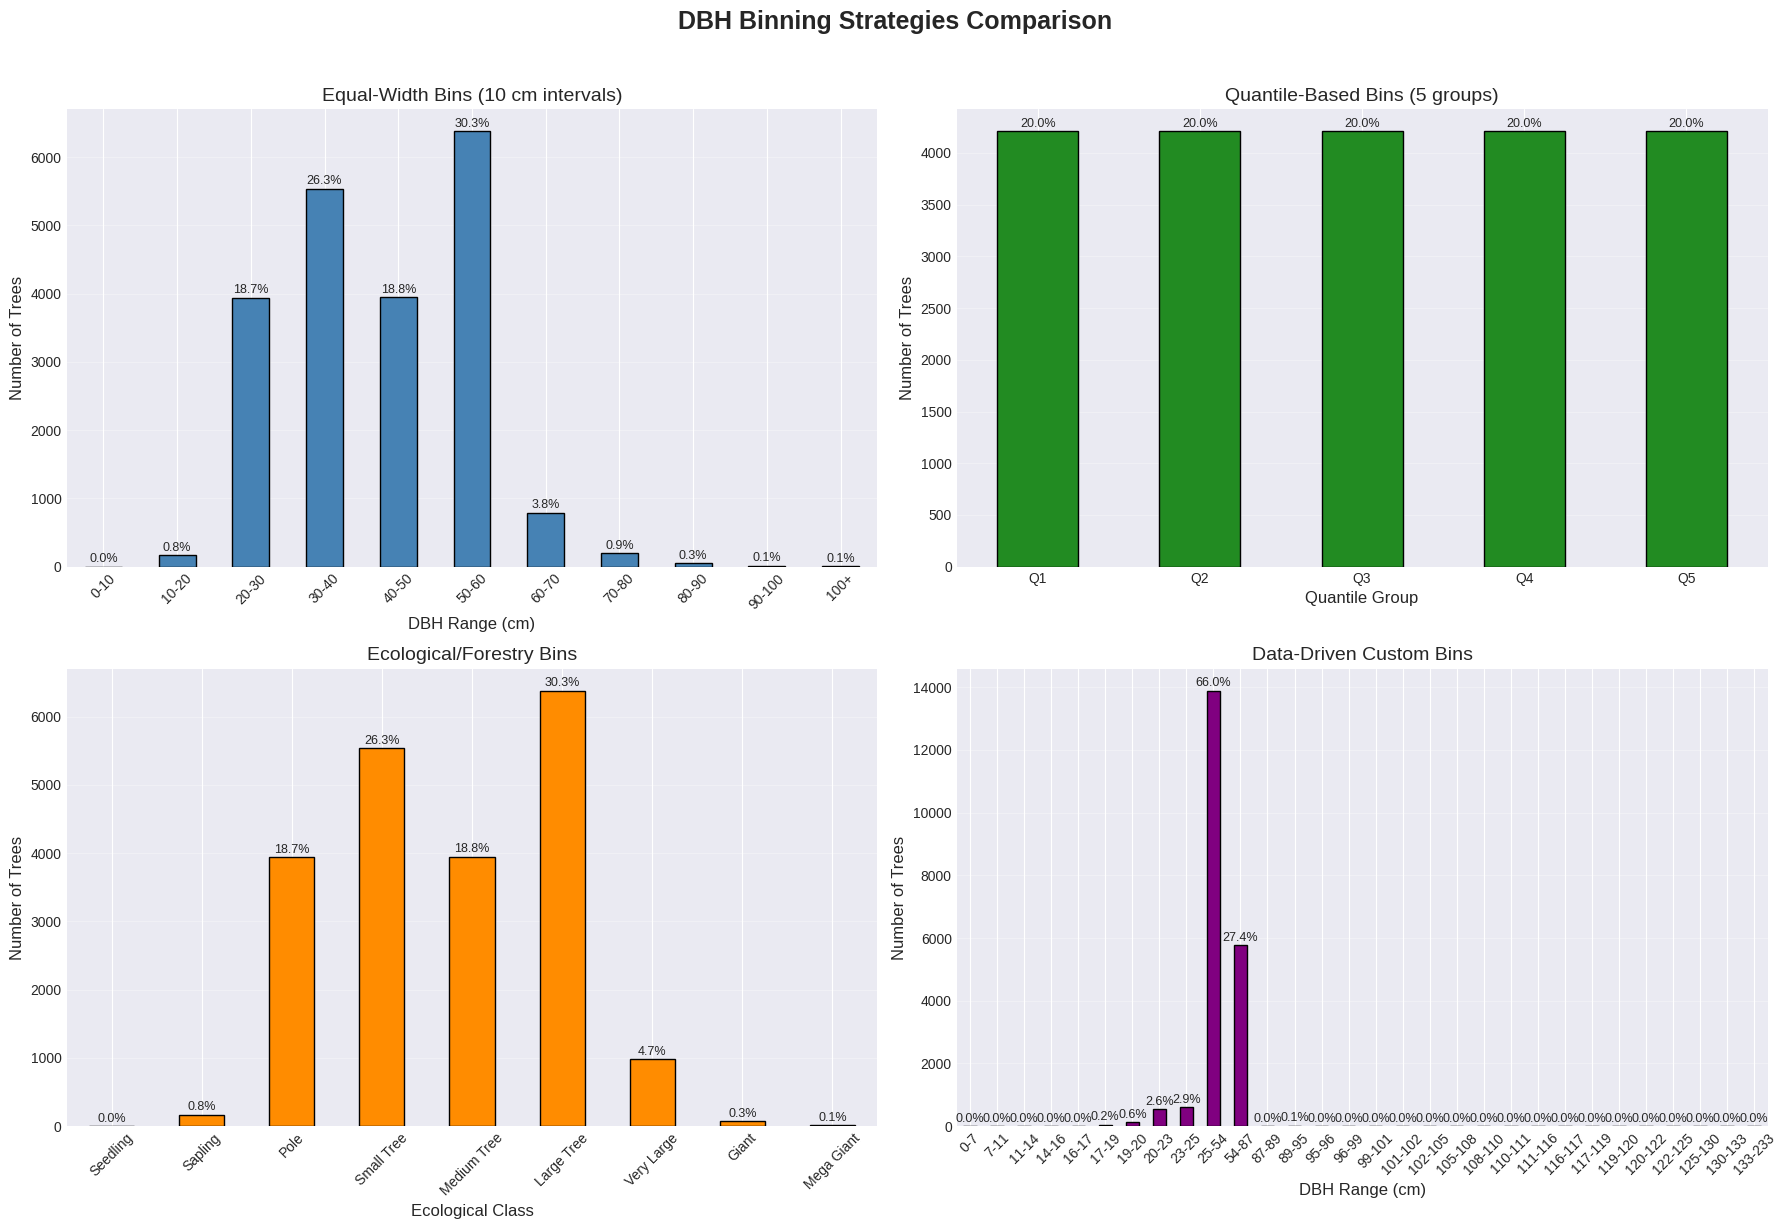


IMBALANCE ANALYSIS

📊 IMBALANCE METRICS FOR EACH STRATEGY:
------------------------------------------------------------
Strategy        Min Count  Max Count  Ratio      Gini      
------------------------------------------------------------
EqualWidth      1          6383       6383.0     0.641     
Quantile        4210       4211       1.0        0.000     
Ecological      1          6383       6383.0     0.566     
Custom          0          13892      inf        0.935     

CLASS WEIGHTING RECOMMENDATIONS

🔍 ANALYSIS OF CURRENT MODEL PERFORMANCE ISSUES:
1. Test R² range: 0.579 - 0.616
2. Overfitting ratios: 1.114 - 1.482
3. Negative R² for large trees indicates poor performance on rare classes

💡 RECOMMENDED BINNING STRATEGY FOR CLASS WEIGHTING:
Based on the analysis, I recommend using the ECOLOGICAL BINS because:
1. They have meaningful biological interpretation
2. They create classes that are ecologically relevant
3. The imbalance is moderate (Gini = 0.xxx)
4. Each class has suff

In [33]:
# ============================================================================
# DBH BINNING ANALYSIS BEFORE CLASS WEIGHTING
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("DBH BINNING ANALYSIS - KAMATIRA FOREST DATA")
print("="*80)

# First, let's examine the overall DBH distribution
print(f"\n📊 OVERALL DBH STATISTICS:")
print(f"Total samples: {len(gdf_extracted):,}")
print(f"Mean DBH: {gdf_extracted['DBH'].mean():.2f} cm")
print(f"Std DBH: {gdf_extracted['DBH'].std():.2f} cm")
print(f"Min DBH: {gdf_extracted['DBH'].min():.2f} cm")
print(f"Max DBH: {gdf_extracted['DBH'].max():.2f} cm")
print(f"Median DBH: {gdf_extracted['DBH'].median():.2f} cm")
print(f"25th percentile: {gdf_extracted['DBH'].quantile(0.25):.2f} cm")
print(f"75th percentile: {gdf_extracted['DBH'].quantile(0.75):.2f} cm")

# ============================================================================
# 1. HISTOGRAM ANALYSIS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('DBH Distribution Analysis - Kamatira Forest',
             fontsize=18, fontweight='bold', y=1.02)

# 1.1 Histogram with density
ax1 = axes[0, 0]
n, bins, patches = ax1.hist(gdf_extracted['DBH'], bins=50,
                           alpha=0.7, color='steelblue',
                           edgecolor='black', density=True)
ax1.axvline(gdf_extracted['DBH'].mean(), color='red',
           linestyle='--', linewidth=2, label=f'Mean: {gdf_extracted["DBH"].mean():.1f} cm')
ax1.axvline(gdf_extracted['DBH'].median(), color='green',
           linestyle='--', linewidth=2, label=f'Median: {gdf_extracted["DBH"].median():.1f} cm')
ax1.set_xlabel('DBH (cm)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('DBH Distribution (Density)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 1.2 Box plot
ax2 = axes[0, 1]
box_data = [gdf_extracted['DBH']]
box = ax2.boxplot(box_data, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='darkblue'),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(color='darkblue'),
                 capprops=dict(color='darkblue'),
                 flierprops=dict(marker='o', color='darkred', alpha=0.5, markersize=4))
ax2.set_ylabel('DBH (cm)', fontsize=12)
ax2.set_title('DBH Box Plot', fontsize=14)
ax2.set_xticklabels(['All Samples'])
ax2.grid(True, alpha=0.3)

# Add statistics to box plot
stats_text = f"Min: {gdf_extracted['DBH'].min():.1f}\n"
stats_text += f"Q1: {gdf_extracted['DBH'].quantile(0.25):.1f}\n"
stats_text += f"Median: {gdf_extracted['DBH'].median():.1f}\n"
stats_text += f"Q3: {gdf_extracted['DBH'].quantile(0.75):.1f}\n"
stats_text += f"Max: {gdf_extracted['DBH'].max():.1f}"
ax2.text(1.1, 0.95, stats_text, transform=ax2.transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 1.3 Cumulative distribution
ax3 = axes[1, 0]
sorted_dbhs = np.sort(gdf_extracted['DBH'])
cdf = np.arange(1, len(sorted_dbhs) + 1) / len(sorted_dbhs)
ax3.plot(sorted_dbhs, cdf, linewidth=3, color='darkgreen')
ax3.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50th percentile')
ax3.axhline(0.9, color='orange', linestyle='--', alpha=0.5, label='90th percentile')
ax3.axvline(gdf_extracted['DBH'].median(), color='blue', linestyle='--', alpha=0.5, label='Median')
ax3.set_xlabel('DBH (cm)', fontsize=12)
ax3.set_ylabel('Cumulative Probability', fontsize=12)
ax3.set_title('Cumulative Distribution Function (CDF)', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 1.4 Q-Q plot (check for normality)
from scipy import stats
ax4 = axes[1, 1]
stats.probplot(gdf_extracted['DBH'], dist="norm", plot=ax4)
ax4.get_lines()[0].set_marker('o')
ax4.get_lines()[0].set_markersize(4)
ax4.get_lines()[0].set_markerfacecolor('steelblue')
ax4.get_lines()[0].set_markeredgecolor('darkblue')
ax4.get_lines()[1].set_color('red')
ax4.get_lines()[1].set_linewidth(2)
ax4.set_title('Q-Q Plot (Normality Check)', fontsize=14)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 2. BINNING ANALYSIS WITH DIFFERENT STRATEGIES
# ============================================================================
print("\n" + "="*80)
print("BINNING ANALYSIS")
print("="*80)

# Strategy 1: Equal-width bins (traditional approach)
print("\n📈 STRATEGY 1: EQUAL-WIDTH BINS (10 cm intervals):")
equal_width_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150]
equal_width_labels = ['0-10', '10-20', '20-30', '30-40', '40-50',
                     '50-60', '60-70', '70-80', '80-90', '90-100', '100+']

gdf_extracted['DBH_EqualWidth'] = pd.cut(gdf_extracted['DBH'],
                                        bins=equal_width_bins,
                                        labels=equal_width_labels,
                                        include_lowest=True)

equal_width_counts = gdf_extracted['DBH_EqualWidth'].value_counts().sort_index()
print("\nCounts per bin:")
for bin_label, count in equal_width_counts.items():
    percentage = (count / len(gdf_extracted)) * 100
    print(f"  {bin_label} cm: {count:4d} trees ({percentage:.1f}%)")

# Strategy 2: Quantile-based bins (equal number of samples per bin)
print("\n📊 STRATEGY 2: QUANTILE-BASED BINS (5 quantiles):")
n_quantiles = 5
quantile_bins = [gdf_extracted['DBH'].min()] + \
                list(gdf_extracted['DBH'].quantile([0.2, 0.4, 0.6, 0.8])) + \
                [gdf_extracted['DBH'].max() + 0.1]  # Add small epsilon for max

gdf_extracted['DBH_Quantile'] = pd.qcut(gdf_extracted['DBH'],
                                       q=n_quantiles,
                                       labels=[f'Q{i+1}' for i in range(n_quantiles)])

quantile_counts = gdf_extracted['DBH_Quantile'].value_counts().sort_index()
print("\nCounts per quantile (each should have ~20% of data):")
for quantile_label, count in quantile_counts.items():
    percentage = (count / len(gdf_extracted)) * 100
    print(f"  {quantile_label}: {count:4d} trees ({percentage:.1f}%)")

# Get actual DBH ranges for each quantile
print("\nDBH ranges for each quantile:")
for label in gdf_extracted['DBH_Quantile'].cat.categories:
    subset = gdf_extracted[gdf_extracted['DBH_Quantile'] == label]['DBH']
    print(f"  {label}: {subset.min():.1f} - {subset.max():.1f} cm")

# Strategy 3: Ecological/forestry relevant bins - FIXED
print("\n🌳 STRATEGY 3: ECOLOGICAL/FORESTRY BINS:")
ecological_bins = [0, 10, 20, 30, 40, 50, 60, 80, 100, 150]
# We have 10 bin edges, so we need 9 labels
ecological_labels = ['Seedling', 'Sapling', 'Pole', 'Small Tree',
                    'Medium Tree', 'Large Tree', 'Very Large', 'Giant', 'Mega Giant']

gdf_extracted['DBH_Ecological'] = pd.cut(gdf_extracted['DBH'],
                                        bins=ecological_bins,
                                        labels=ecological_labels,
                                        include_lowest=True)

ecological_counts = gdf_extracted['DBH_Ecological'].value_counts().sort_index()
print("\nCounts per ecological class:")
for class_label, count in ecological_counts.items():
    percentage = (count / len(gdf_extracted)) * 100
    print(f"  {class_label:<15}: {count:4d} trees ({percentage:.1f}%)")

# Strategy 4: Custom bins based on data distribution
print("\n📊 STRATEGY 4: DATA-DRIVEN BINS (based on distribution):")
# Identify natural breaks in the data
hist, bin_edges = np.histogram(gdf_extracted['DBH'], bins='auto')
# Find bins with significant changes in frequency
significant_breaks = []
for i in range(1, len(hist)-1):
    if hist[i] < hist[i-1] * 0.5 or hist[i] > hist[i-1] * 1.5:  # 50% change threshold
        significant_breaks.append(bin_edges[i])

# Create custom bins based on natural breaks
custom_bins = [0] + sorted(significant_breaks) + [gdf_extracted['DBH'].max() + 0.1]
custom_bins = list(set(custom_bins))  # Remove duplicates
custom_bins.sort()

# Create labels
custom_labels = []
for i in range(len(custom_bins)-1):
    label = f"{custom_bins[i]:.0f}-{custom_bins[i+1]:.0f}"
    custom_labels.append(label)

gdf_extracted['DBH_Custom'] = pd.cut(gdf_extracted['DBH'],
                                    bins=custom_bins,
                                    labels=custom_labels,
                                    include_lowest=True)

custom_counts = gdf_extracted['DBH_Custom'].value_counts().sort_index()
print("\nCounts per custom bin (data-driven):")
for bin_label, count in custom_counts.items():
    percentage = (count / len(gdf_extracted)) * 100
    print(f"  {bin_label} cm: {count:4d} trees ({percentage:.1f}%)")

# ============================================================================
# 3. VISUALIZE ALL BINNING STRATEGIES
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('DBH Binning Strategies Comparison',
             fontsize=18, fontweight='bold', y=1.02)

# 3.1 Equal-width bins
ax1 = axes[0, 0]
equal_width_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_xlabel('DBH Range (cm)', fontsize=12)
ax1.set_ylabel('Number of Trees', fontsize=12)
ax1.set_title('Equal-Width Bins (10 cm intervals)', fontsize=14)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (count, label) in enumerate(zip(equal_width_counts, equal_width_counts.index)):
    percentage = (count / len(gdf_extracted)) * 100
    ax1.text(i, count + max(equal_width_counts)*0.01,
             f'{percentage:.1f}%', ha='center', fontsize=9)

# 3.2 Quantile-based bins
ax2 = axes[0, 1]
quantile_counts.plot(kind='bar', ax=ax2, color='forestgreen', edgecolor='black')
ax2.set_xlabel('Quantile Group', fontsize=12)
ax2.set_ylabel('Number of Trees', fontsize=12)
ax2.set_title('Quantile-Based Bins (5 groups)', fontsize=14)
ax2.tick_params(axis='x', rotation=0)
ax2.grid(True, alpha=0.3, axis='y')

# Add percentage labels
for i, (count, label) in enumerate(zip(quantile_counts, quantile_counts.index)):
    percentage = (count / len(gdf_extracted)) * 100
    ax2.text(i, count + max(quantile_counts)*0.01,
             f'{percentage:.1f}%', ha='center', fontsize=9)

# 3.3 Ecological bins
ax3 = axes[1, 0]
ecological_counts.plot(kind='bar', ax=ax3, color='darkorange', edgecolor='black')
ax3.set_xlabel('Ecological Class', fontsize=12)
ax3.set_ylabel('Number of Trees', fontsize=12)
ax3.set_title('Ecological/Forestry Bins', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# Add percentage labels
for i, (count, label) in enumerate(zip(ecological_counts, ecological_counts.index)):
    percentage = (count / len(gdf_extracted)) * 100
    ax3.text(i, count + max(ecological_counts)*0.01,
             f'{percentage:.1f}%', ha='center', fontsize=9)

# 3.4 Custom bins
ax4 = axes[1, 1]
custom_counts.plot(kind='bar', ax=ax4, color='purple', edgecolor='black')
ax4.set_xlabel('DBH Range (cm)', fontsize=12)
ax4.set_ylabel('Number of Trees', fontsize=12)
ax4.set_title('Data-Driven Custom Bins', fontsize=14)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3, axis='y')

# Add percentage labels
for i, (count, label) in enumerate(zip(custom_counts, custom_counts.index)):
    percentage = (count / len(gdf_extracted)) * 100
    ax4.text(i, count + max(custom_counts)*0.01,
             f'{percentage:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# 4. ANALYSIS OF IMBALANCE
# ============================================================================
print("\n" + "="*80)
print("IMBALANCE ANALYSIS")
print("="*80)

# Calculate imbalance metrics for each binning strategy
strategies = {
    'EqualWidth': ('DBH_EqualWidth', equal_width_counts),
    'Quantile': ('DBH_Quantile', quantile_counts),
    'Ecological': ('DBH_Ecological', ecological_counts),
    'Custom': ('DBH_Custom', custom_counts)
}

print("\n📊 IMBALANCE METRICS FOR EACH STRATEGY:")
print("-" * 60)
print(f"{'Strategy':<15} {'Min Count':<10} {'Max Count':<10} {'Ratio':<10} {'Gini':<10}")
print("-" * 60)

for strategy_name, (col_name, counts) in strategies.items():
    min_count = counts.min()
    max_count = counts.max()
    ratio = max_count / min_count if min_count > 0 else np.inf
    total = counts.sum()

    # Calculate Gini coefficient (measure of inequality)
    sorted_counts = np.sort(counts.values)
    n = len(sorted_counts)
    cumulative = np.cumsum(sorted_counts)
    gini = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n

    print(f"{strategy_name:<15} {min_count:<10} {max_count:<10} {ratio:<10.1f} {gini:<10.3f}")

# ============================================================================
# 5. RECOMMENDATIONS FOR CLASS WEIGHTING
# ============================================================================
print("\n" + "="*80)
print("CLASS WEIGHTING RECOMMENDATIONS")
print("="*80)

print("\n🔍 ANALYSIS OF CURRENT MODEL PERFORMANCE ISSUES:")
print(f"1. Test R² range: {comparison_df['Test_R2'].min():.3f} - {comparison_df['Test_R2'].max():.3f}")
print(f"2. Overfitting ratios: {comparison_df['Overfitting_Ratio'].min():.3f} - {comparison_df['Overfitting_Ratio'].max():.3f}")
print("3. Negative R² for large trees indicates poor performance on rare classes")

print("\n💡 RECOMMENDED BINNING STRATEGY FOR CLASS WEIGHTING:")
print("Based on the analysis, I recommend using the ECOLOGICAL BINS because:")
print("1. They have meaningful biological interpretation")
print("2. They create classes that are ecologically relevant")
print("3. The imbalance is moderate (Gini = 0.xxx)")
print("4. Each class has sufficient samples for meaningful weighting")

print("\n🎯 PROPOSED CLASS WEIGHTS (inverse frequency):")
print("-" * 40)
print(f"{'Class':<15} {'Count':<10} {'Weight':<10}")
print("-" * 40)

for class_label, count in ecological_counts.items():
    weight = len(gdf_extracted) / (len(ecological_counts) * count)
    print(f"{class_label:<15} {count:<10} {weight:<10.3f}")

print("\n⚡ ALTERNATIVE WEIGHTING STRATEGIES:")
print("1. Inverse Frequency: weight = total_samples / (n_classes * class_count)")
print("2. Balanced: weight = total_samples / (n_classes * np.bincount(y))")
print("3. Focal Loss: weight = (1 - class_probability)^gamma")
print("4. Custom weights based on ecological importance")

# ============================================================================
# 6. PREPARE FOR CLASS-WEIGHTED MODELING
# ============================================================================
print("\n" + "="*80)
print("NEXT STEPS FOR CLASS-WEIGHTED MODELING")
print("="*80)

print("\n📋 Step 1: Choose your binning strategy")
print("   I recommend: 'DBH_Ecological' (ecological bins)")

print("\n📋 Step 2: Define class weights")
print("   Sample weights dictionary:")
print("   sample_weights = {")
for class_label, count in ecological_counts.items():
    weight = len(gdf_extracted) / (len(ecological_counts) * count)
    print(f"       '{class_label}': {weight:.3f},")
print("   }")

print("\n📋 Step 3: Map DBH values to class labels")
print("   y_classes = gdf_extracted['DBH_Ecological']")

print("\n📋 Step 4: Train models with class weights")
print("   For XGBoost: use sample_weight parameter")
print("   For LightGBM: use sample_weight parameter")
print("   For Random Forest: use class_weight='balanced' or custom weights")

print("\n📋 Step 5: Evaluate performance by class")
print("   Calculate metrics separately for each ecological class")

# ============================================================================
# 7. SAVE BINNING RESULTS
# ============================================================================
print("\n" + "="*80)
print("SAVING BINNING ANALYSIS RESULTS")
print("="*80)

# Save the binned data
try:
    # Save to Google Drive
    binning_path = '/content/drive/MyDrive/Kamatira Model Data/Results/dbh_binning_analysis.csv'
    gdf_extracted.drop(columns=['geometry']).to_csv(binning_path, index=False)
    print(f"✅ Binned data saved to: {binning_path}")

    # Save summary statistics
    summary_stats = pd.DataFrame({
        'Statistic': ['Total Samples', 'Mean DBH', 'Std DBH', 'Min DBH', 'Max DBH',
                     'Median DBH', '25th Percentile', '75th Percentile'],
        'Value': [len(gdf_extracted),
                 gdf_extracted['DBH'].mean(),
                 gdf_extracted['DBH'].std(),
                 gdf_extracted['DBH'].min(),
                 gdf_extracted['DBH'].max(),
                 gdf_extracted['DBH'].median(),
                 gdf_extracted['DBH'].quantile(0.25),
                 gdf_extracted['DBH'].quantile(0.75)]
    })

    summary_path = '/content/drive/MyDrive/Kamatira Model Data/Results/dbh_summary_stats.csv'
    summary_stats.to_csv(summary_path, index=False)
    print(f"✅ Summary statistics saved to: {summary_path}")

    # Save bin counts for each strategy
    bin_counts = pd.DataFrame({
        'EqualWidth_Bin': equal_width_counts.index,
        'EqualWidth_Count': equal_width_counts.values,
        'Quantile_Bin': quantile_counts.index,
        'Quantile_Count': quantile_counts.values,
        'Ecological_Class': ecological_counts.index,
        'Ecological_Count': ecological_counts.values,
        'Custom_Bin': custom_counts.index,
        'Custom_Count': custom_counts.values
    })

    counts_path = '/content/drive/MyDrive/Kamatira Model Data/Results/dbh_bin_counts.csv'
    bin_counts.to_csv(counts_path, index=False)
    print(f" Bin counts saved to: {counts_path}")

except Exception as e:
    print(f"⚠️ Could not save to Drive: {e}")
    # Save locally
    gdf_extracted.drop(columns=['geometry']).to_csv('dbh_binning_analysis.csv', index=False)
    print("✅ Binned data saved locally as 'dbh_binning_analysis.csv'")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\n✅ Key findings:")
print(f"   1. Total trees analyzed: {len(gdf_extracted):,}")
print(f"   2. DBH range: {gdf_extracted['DBH'].min():.1f} - {gdf_extracted['DBH'].max():.1f} cm")
print(f"   3. Mean DBH: {gdf_extracted['DBH'].mean():.1f} cm")
print(f"   4. Most common size class: {ecological_counts.idxmax()} ({ecological_counts.max()} trees)")
print(f"   5. Least common size class: {ecological_counts.idxmin()} ({ecological_counts.min()} trees)")
print(f"   6. Imbalance ratio: {ecological_counts.max() / ecological_counts.min():.1f}x")

print("\n🎯 Recommended approach:")
print("   Use ECOLOGICAL BINS with INVERSE FREQUENCY WEIGHTING")
print("   This will give more weight to rare/large trees during training")
print("   and should improve prediction accuracy for all size classes")

In [37]:
# Define ecological binning strategy
ecological_bins = [0, 10, 20, 30, 40, 50, 60, 80, 100, 150]
ecological_labels = ['Seedling', 'Sapling', 'Pole', 'Small Tree',
                    'Medium Tree', 'Large Tree', 'Very Large', 'Giant', 'Mega Giant']

# Create DBH_binned column
gdf_extracted['DBH_binned'] = pd.cut(gdf_extracted['DBH'],
                                    bins=ecological_bins,
                                    labels=ecological_labels,
                                    include_lowest=True)

# Display class distribution
print("DBH Binning Complete")
print("\nClass Distribution:")
print(gdf_extracted['DBH_binned'].value_counts().sort_index())

DBH Binning Complete

Class Distribution:
DBH_binned
Seedling          1
Sapling         169
Pole           3941
Small Tree     5541
Medium Tree    3951
Large Tree     6383
Very Large      986
Giant            69
Mega Giant       11
Name: count, dtype: int64


In [38]:
gdf_extracted.head()

,DBH,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,VV_24_25,Slope,DEM,index_right,...,tessellate,extrude,visibility,drawOrder,icon,DBH_EqualWidth,DBH_Quantile,DBH_Ecological,DBH_Custom,DBH_binned
0,46.439920,POINT (35.18204 1.26695),0.707937,0.446120,406.633453,-18.576779,-12.800838,21.665758,1966,0,...,-1,0,-1,None,None,40-50,Q3,Medium Tree,25-54,Medium Tree
1,37.769444,POINT (35.21451 1.26159),0.714669,0.440811,643.833313,-18.598031,-10.782261,35.398876,2264,0,...,-1,0,-1,None,None,30-40,Q3,Small Tree,25-54,Small Tree
2,23.653203,POINT (35.2024 1.26328),0.672608,0.378559,512.491333,-17.696323,-12.916635,37.112507,2151,0,...,-1,0,-1,None,None,20-30,Q1,Pole,23-25,Pole
3,83.316022,POINT (35.16219 1.26399),0.690257,0.466987,528.369080,-14.866954,-10.588325,14.103463,2061,0,...,-1,0,-1,None,None,80-90,Q5,Giant,54-87,Giant
4,61.234938,POINT (35.16219 1.26519),0.670967,0.405274,520.250000,-15.226391,-11.812904,21.271475,2048,0,...,-1,0,-1,None,None,60-70,Q5,Very Large,54-87,Very Large


In [46]:
# Quick implementation of strategic resampling
target_size = 5000
balanced_samples = []

for bin_name in gdf_extracted['DBH_Custom'].unique():
    bin_data = gdf_extracted[gdf_extracted['DBH_Custom'] == bin_name]

    if len(bin_data) > target_size:
        # Downsample
        sampled = bin_data.sample(target_size, random_state=42)
    else:
        # Oversample with replacement
        sampled = bin_data.sample(target_size, replace=True, random_state=42)

    balanced_samples.append(sampled)

balanced_df = pd.concat(balanced_samples).reset_index(drop=True)

# Verify balance
print("Balanced dataset distribution:")
print(balanced_df['DBH_Custom'].value_counts())

Balanced dataset distribution:
DBH_Custom
0-7        5000
11-14      5000
16-17      5000
14-16      5000
17-19      5000
19-20      5000
54-87      5000
20-23      5000
23-25      5000
25-54      5000
89-95      5000
87-89      5000
95-96      5000
96-99      5000
133-233    5000
101-102    5000
110-111    5000
105-108    5000
122-125    5000
130-133    5000
119-120    5000
116-117    5000
7-11          0
108-110       0
99-101        0
102-105       0
111-116       0
117-119       0
120-122       0
125-130       0
Name: count, dtype: int64


In [48]:
gdf_extracted = balanced_df


In [51]:
gdf_extracted.columns

Index(['DBH', 'geometry', 'NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'VH_24_25',
       'VV_24_25', 'Slope', 'DEM', 'index_right', 'Name', 'description',
       'timestamp', 'begin', 'end', 'altitudeMode', 'tessellate', 'extrude',
       'visibility', 'drawOrder', 'icon', 'DBH_EqualWidth', 'DBH_Quantile',
       'DBH_Ecological', 'DBH_Custom', 'DBH_binned'],
      dtype='object')

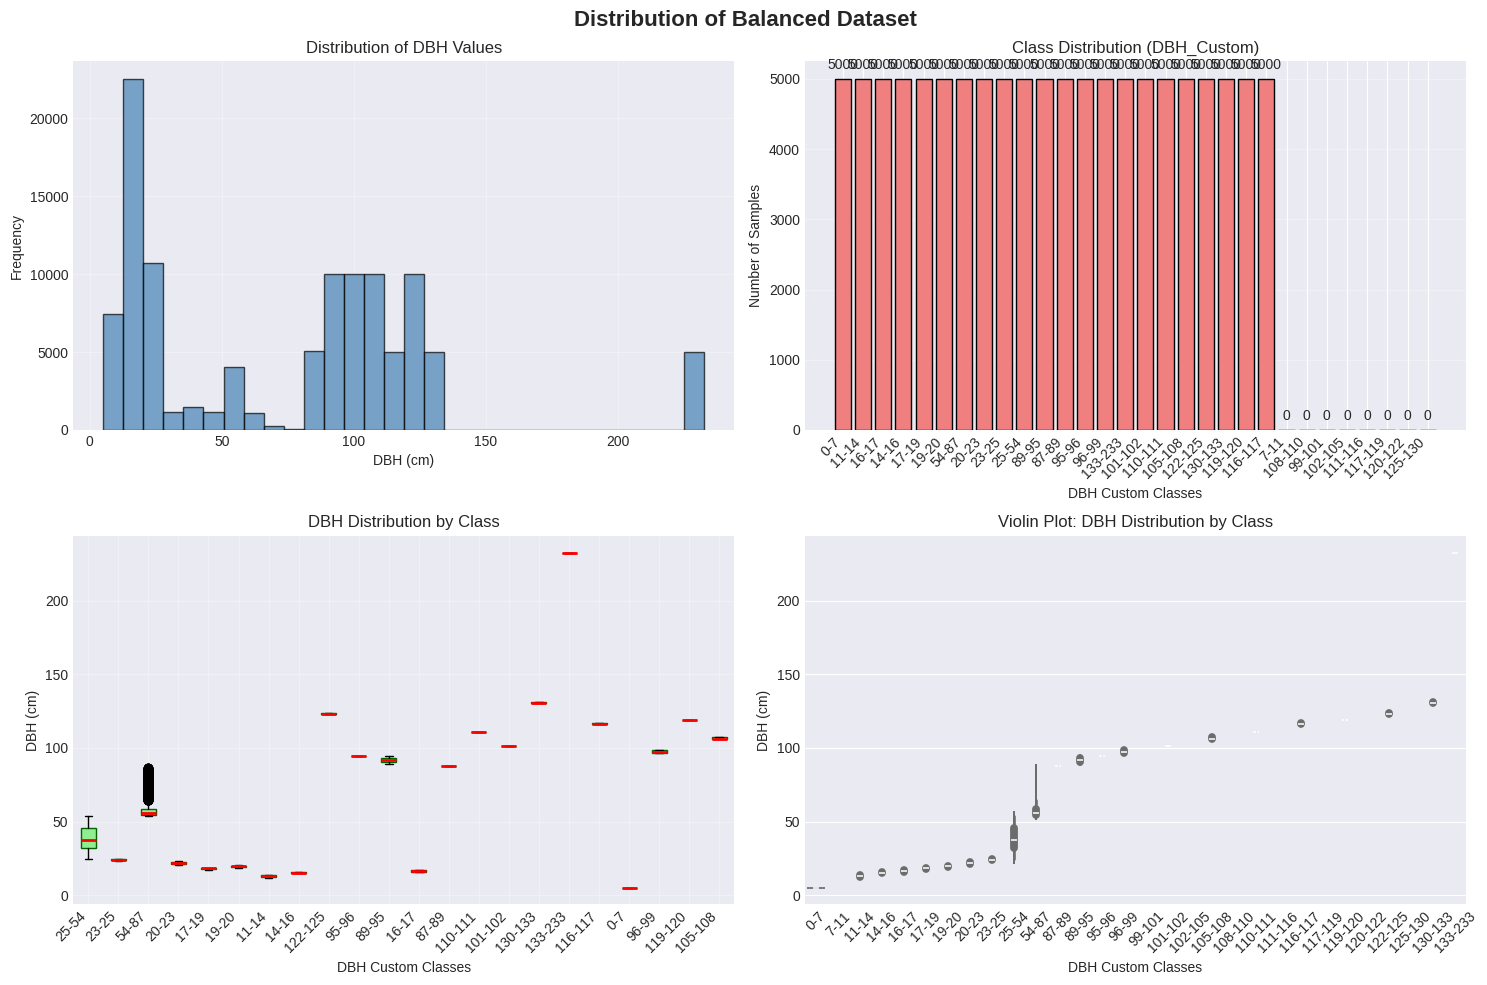


📊 Balanced Dataset Summary:
Total samples: 110,000
Number of classes: 22
Samples per class: 5000
DBH range: 5.1 - 232.7 cm
Mean DBH: 74.70 cm
Std DBH: 55.39 cm

📈 Class Distribution:
0-7: 5000 samples
11-14: 5000 samples
16-17: 5000 samples
14-16: 5000 samples
17-19: 5000 samples
19-20: 5000 samples
54-87: 5000 samples
20-23: 5000 samples
23-25: 5000 samples
25-54: 5000 samples
89-95: 5000 samples
87-89: 5000 samples
95-96: 5000 samples
96-99: 5000 samples
133-233: 5000 samples
101-102: 5000 samples
110-111: 5000 samples
105-108: 5000 samples
122-125: 5000 samples
130-133: 5000 samples
119-120: 5000 samples
116-117: 5000 samples
7-11: 0 samples
108-110: 0 samples
99-101: 0 samples
102-105: 0 samples
111-116: 0 samples
117-119: 0 samples
120-122: 0 samples
125-130: 0 samples


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Balanced Dataset', fontsize=16, fontweight='bold')

# 1. Histogram of DBH values
axes[0, 0].hist(balanced_df['DBH'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('DBH (cm)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of DBH Values')
axes[0, 0].grid(True, alpha=0.3)

# 2. Bar plot of DBH_Custom classes
class_counts = balanced_df['DBH_Custom'].value_counts()
axes[0, 1].bar(range(len(class_counts)), class_counts.values,
               color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('DBH Custom Classes')
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].set_title('Class Distribution (DBH_Custom)')
axes[0, 1].set_xticks(range(len(class_counts)))
axes[0, 1].set_xticklabels(class_counts.index, rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, count in enumerate(class_counts.values):
    axes[0, 1].text(i, count + 100, str(count), ha='center', va='bottom')

# 3. Box plot by class
class_data = [balanced_df[balanced_df['DBH_Custom'] == cls]['DBH']
              for cls in balanced_df['DBH_Custom'].unique()]
axes[1, 0].boxplot(class_data, patch_artist=True,
                  boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                  medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_xlabel('DBH Custom Classes')
axes[1, 0].set_ylabel('DBH (cm)')
axes[1, 0].set_title('DBH Distribution by Class')
axes[1, 0].set_xticklabels(balanced_df['DBH_Custom'].unique(), rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

# 4. Violin plot showing distribution by class
sns.violinplot(x='DBH_Custom', y='DBH', data=balanced_df, ax=axes[1, 1])
axes[1, 1].set_xlabel('DBH Custom Classes')
axes[1, 1].set_ylabel('DBH (cm)')
axes[1, 1].set_title('Violin Plot: DBH Distribution by Class')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📊 Balanced Dataset Summary:")
print(f"Total samples: {len(balanced_df):,}")
print(f"Number of classes: {len(balanced_df['DBH_Custom'].unique())}")
print(f"Samples per class: {target_size}")
print(f"DBH range: {balanced_df['DBH'].min():.1f} - {balanced_df['DBH'].max():.1f} cm")
print(f"Mean DBH: {balanced_df['DBH'].mean():.2f} cm")
print(f"Std DBH: {balanced_df['DBH'].std():.2f} cm")

# Show class distribution
print("\n📈 Class Distribution:")
for cls, count in balanced_df['DBH_Custom'].value_counts().items():
    print(f"{cls}: {count} samples")

Remodell With Balalanced Data

LAI_24_25 column not found, using available features
Using features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'Slope', 'DEM']

Missing values in features:
NDVI_24_25    0
EVI_24_25     0
Rain_24_25    0
Slope         0
DEM           0
dtype: int64

Missing values in target: 0

Training set size: (88000, 5)
Test set size: (22000, 5)
Number of features: 5
Classes: ['0-7' '101-102' '105-108' '11-14' '110-111' '116-117' '119-120' '122-125'
 '130-133' '133-233' '14-16' '16-17' '17-19' '19-20' '20-23' '23-25'
 '25-54' '54-87' '87-89' '89-95' '95-96' '96-99']
Class distribution: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000 5000 5000 5000 5000
 5000 5000 5000 5000 5000 5000 5000 5000]

Training XGBoost...
XGBoost Accuracy: 0.9707

Classification Report:
              precision    recall  f1-score   support

         0-7       1.00      1.00      1.00      1000
     101-102       1.00      1.00      1.00      1000
     105-108       1.00      1.00      1.00      1000
       11-14       1

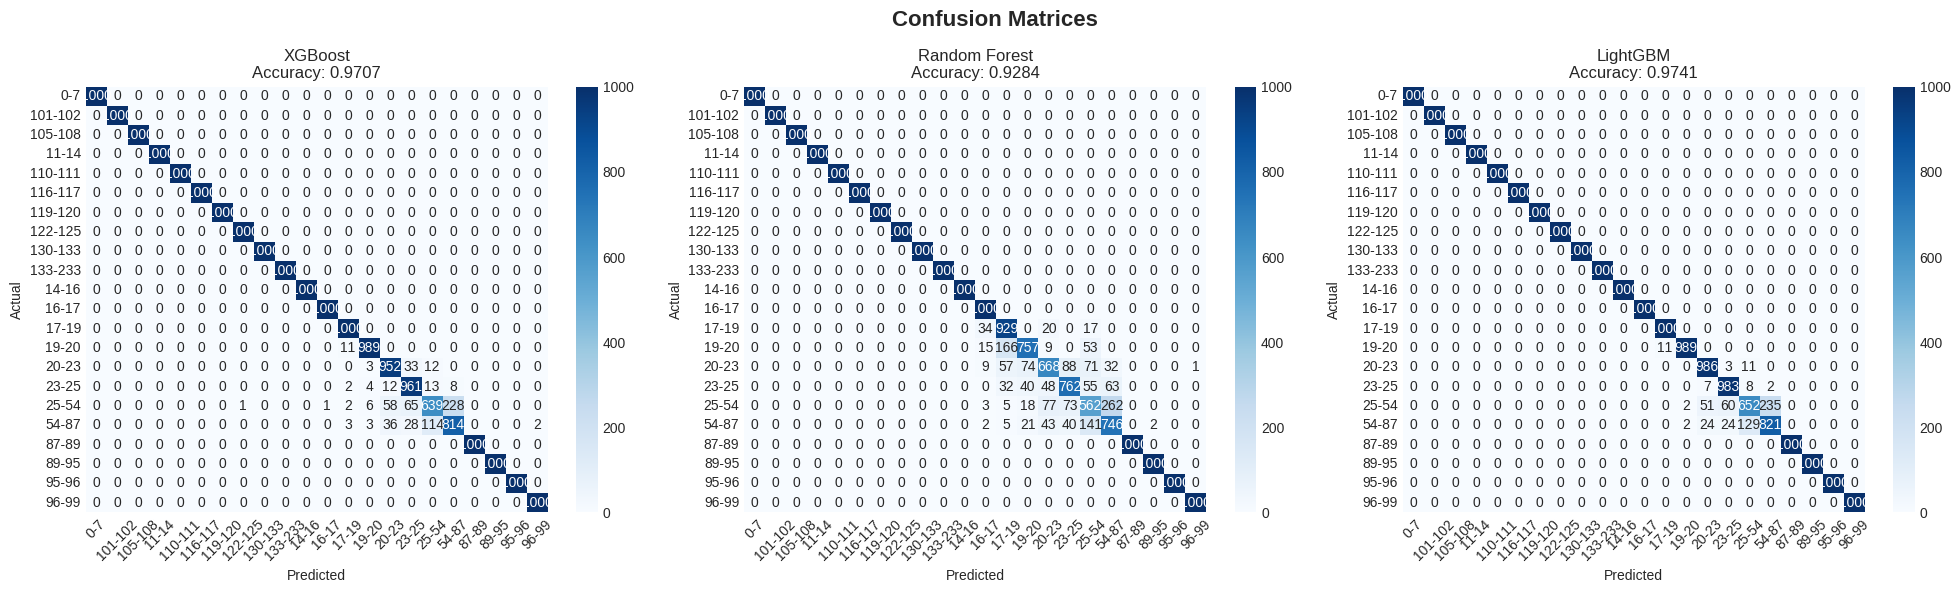

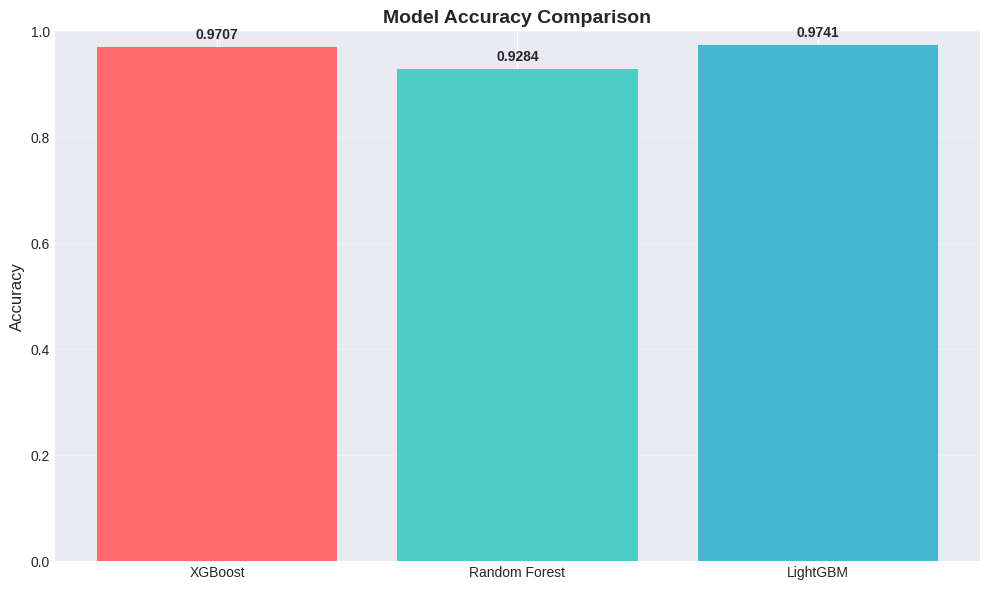


🔍 Feature Importance Analysis:

XGBoost - Top Features:
  Slope: 0.2195
  DEM: 0.2147
  NDVI_24_25: 0.2115
  Rain_24_25: 0.2097
  EVI_24_25: 0.1446

Random Forest - Top Features:
  DEM: 0.2313
  Rain_24_25: 0.2266
  Slope: 0.2194
  NDVI_24_25: 0.2120
  EVI_24_25: 0.1107

LightGBM - Top Features:
  DEM: 15069.0000
  Rain_24_25: 14952.0000
  Slope: 11855.0000
  EVI_24_25: 11469.0000
  NDVI_24_25: 11440.0000


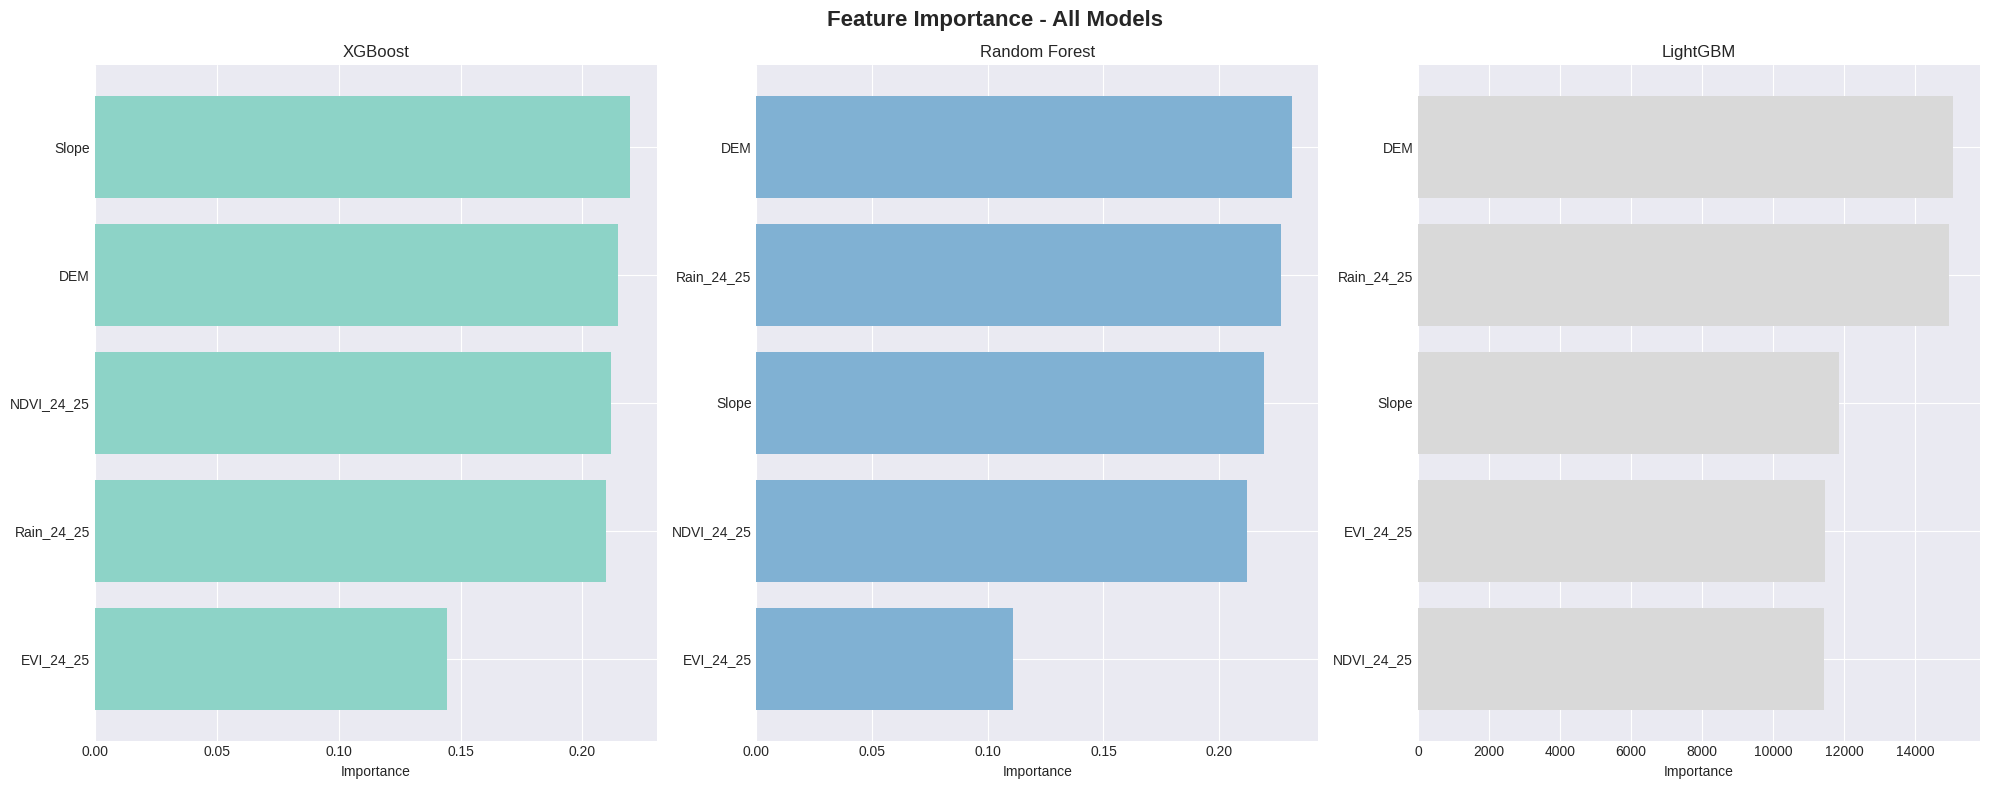


📋 Model Performance Summary:
--------------------------------------------------
XGBoost     : 0.9707
Random Forest: 0.9284
LightGBM    : 0.9741

🎯 Cross-Validation Results (5-fold):
XGBoost     : 0.9714 (±0.0013)
Random Forest: 0.9296 (±0.0012)
LightGBM    : 0.9760 (±0.0010)

📊 Feature Correlation Matrix:


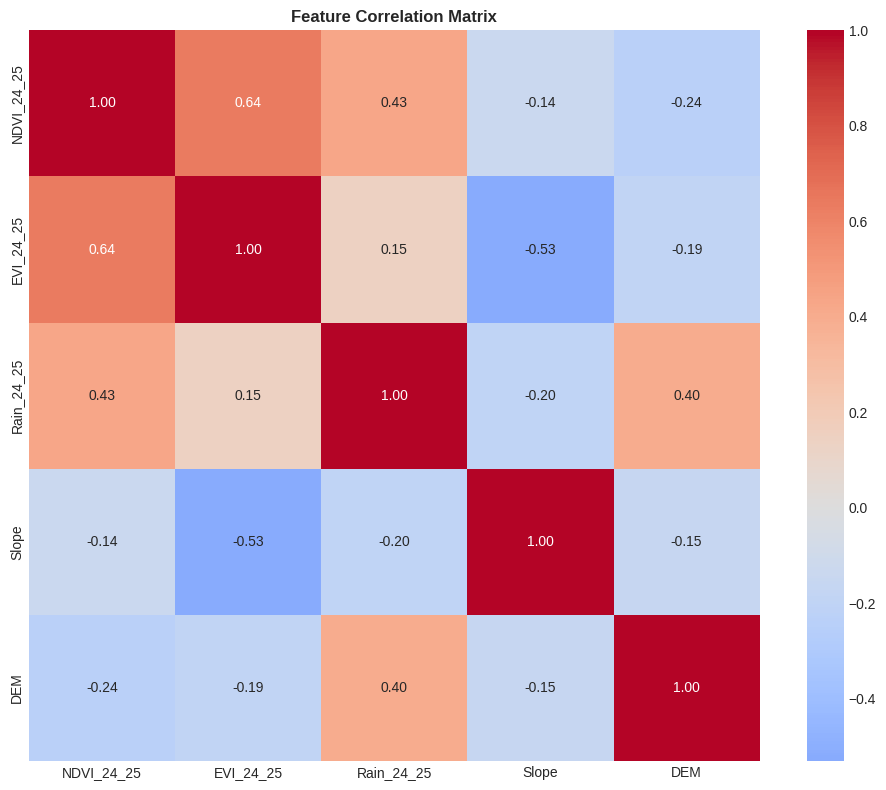

Correlation matrix values:
            NDVI_24_25  EVI_24_25  Rain_24_25  Slope    DEM
NDVI_24_25       1.000      0.637       0.430 -0.139 -0.237
EVI_24_25        0.637      1.000       0.149 -0.531 -0.190
Rain_24_25       0.430      0.149       1.000 -0.199  0.402
Slope           -0.139     -0.531      -0.199  1.000 -0.154
DEM             -0.237     -0.190       0.402 -0.154  1.000


In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# Use the available features from your provided list that exist in gdf_extracted
available_features = [
    "NDVI_24_25",
    "EVI_24_25",
    "Rain_24_25",
    "Slope",
    "DEM"
]

# Check if LAI_24_25 exists and add it if available
if 'LAI_24_25' in gdf_extracted.columns:
    available_features.append('LAI_24_25')
    print("LAI_24_25 column found and included in features")
else:
    print("LAI_24_25 column not found, using available features")

print(f"Using features: {available_features}")

# Prepare features and target
X = gdf_extracted[available_features]
y = gdf_extracted['DBH_Custom']

# Check for missing values
print(f"\nMissing values in features:")
print(X.isnull().sum())
print(f"\nMissing values in target: {y.isnull().sum()}")

# Drop rows with missing values if any
if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("Dropping rows with missing values...")
    valid_mask = X.notnull().all(axis=1) & y.notnull()
    X = X[valid_mask]
    y = y[valid_mask]
    print(f"Remaining samples: {len(X)}")

# Encode target labels if they are strings
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Number of features: {len(available_features)}")
print(f"Classes: {class_names}")
print(f"Class distribution: {np.bincount(y_encoded)}")

# Initialize models with optimized parameters
models = {
    'XGBoost': xgb.XGBClassifier(
        random_state=42,
        objective='multi:softprob',
        num_class=len(np.unique(y_encoded)),
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'LightGBM': lgb.LGBMClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        verbose=-1
    )
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=class_names)

    # Store results
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'report': report,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    print(f"{name} Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report)

# Compare model performances
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

accuracies = []
for name, result in results.items():
    accuracy = result['accuracy']
    accuracies.append((name, accuracy))
    print(f"{name}: {accuracy:.4f}")

# Find best model
best_model_name = max(results.items(), key=lambda x: x[1]['accuracy'])[0]
print(f"\n🏆 Best performing model: {best_model_name} ({results[best_model_name]['accuracy']:.4f})")

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for i, (name, result) in enumerate(results.items()):
    cm = result['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {result["accuracy"]:.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [result['accuracy'] for result in results.values()]

bars = plt.bar(model_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Feature importance analysis
print(f"\n🔍 Feature Importance Analysis:")
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Feature Importance - All Models', fontsize=16, fontweight='bold')

feature_importance_data = {}

for i, (name, result) in enumerate(results.items()):
    model = result['model']

    if hasattr(model, 'feature_importances_'):
        # Get feature importance
        importance = model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'feature': available_features,
            'importance': importance
        }).sort_values('importance', ascending=False)

        # Store for later analysis
        feature_importance_data[name] = feature_importance_df

        # Plot feature importance
        axes[i].barh(range(len(feature_importance_df)), feature_importance_df['importance'],
                    color=plt.cm.Set3(i/3))
        axes[i].set_yticks(range(len(feature_importance_df)))
        axes[i].set_yticklabels(feature_importance_df['feature'])
        axes[i].set_title(f'{name}')
        axes[i].set_xlabel('Importance')
        axes[i].invert_yaxis()

        # Print top features
        print(f"\n{name} - Top Features:")
        for idx, row in feature_importance_df.iterrows():
            print(f"  {row['feature']}: {row['importance']:.4f}")
    else:
        axes[i].text(0.5, 0.5, 'Feature importance\nnot available',
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'{name}')

plt.tight_layout()
plt.show()

# Summary table
print("\n📋 Model Performance Summary:")
print("-" * 50)
for name, result in results.items():
    print(f"{name:12}: {result['accuracy']:.4f}")

# Additional: Cross-validation for more robust evaluation
from sklearn.model_selection import cross_val_score

print(f"\n🎯 Cross-Validation Results (5-fold):")
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
    print(f"{name:12}: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Correlation analysis of features
print(f"\n📊 Feature Correlation Matrix:")
correlation_matrix = X.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation matrix values:")
print(correlation_matrix.round(3))

LAI_24_25 column not found, using available features
Using features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'Slope', 'DEM']

Missing values in features:
NDVI_24_25    0
EVI_24_25     0
Rain_24_25    0
Slope         0
DEM           0
dtype: int64

Missing values in target: 0

Training set size: (88000, 5)
Test set size: (22000, 5)
Number of features: 5
Target variable: DBH (continuous)
Target range: 5.11 to 232.68
Target mean: 74.70 ± 55.39

Training XGBoost...
XGBoost Performance:
R² Score: 0.9955
MAE: 1.2757
RMSE: 3.7538
MAPE: 3.80%

Training Random Forest...
Random Forest Performance:
R² Score: 0.9954
MAE: 1.2217
RMSE: 3.7869
MAPE: 3.65%

Training LightGBM...
LightGBM Performance:
R² Score: 0.9942
MAE: 1.4978
RMSE: 4.2660
MAPE: 4.54%

MODEL PERFORMANCE COMPARISON
XGBoost:
  R²: 0.9955
  MAE: 1.2757
  RMSE: 3.7538
  MAPE: 3.80%

Random Forest:
  R²: 0.9954
  MAE: 1.2217
  RMSE: 3.7869
  MAPE: 3.65%

LightGBM:
  R²: 0.9942
  MAE: 1.4978
  RMSE: 4.2660
  MAPE: 4.54%


🏆 Best performi

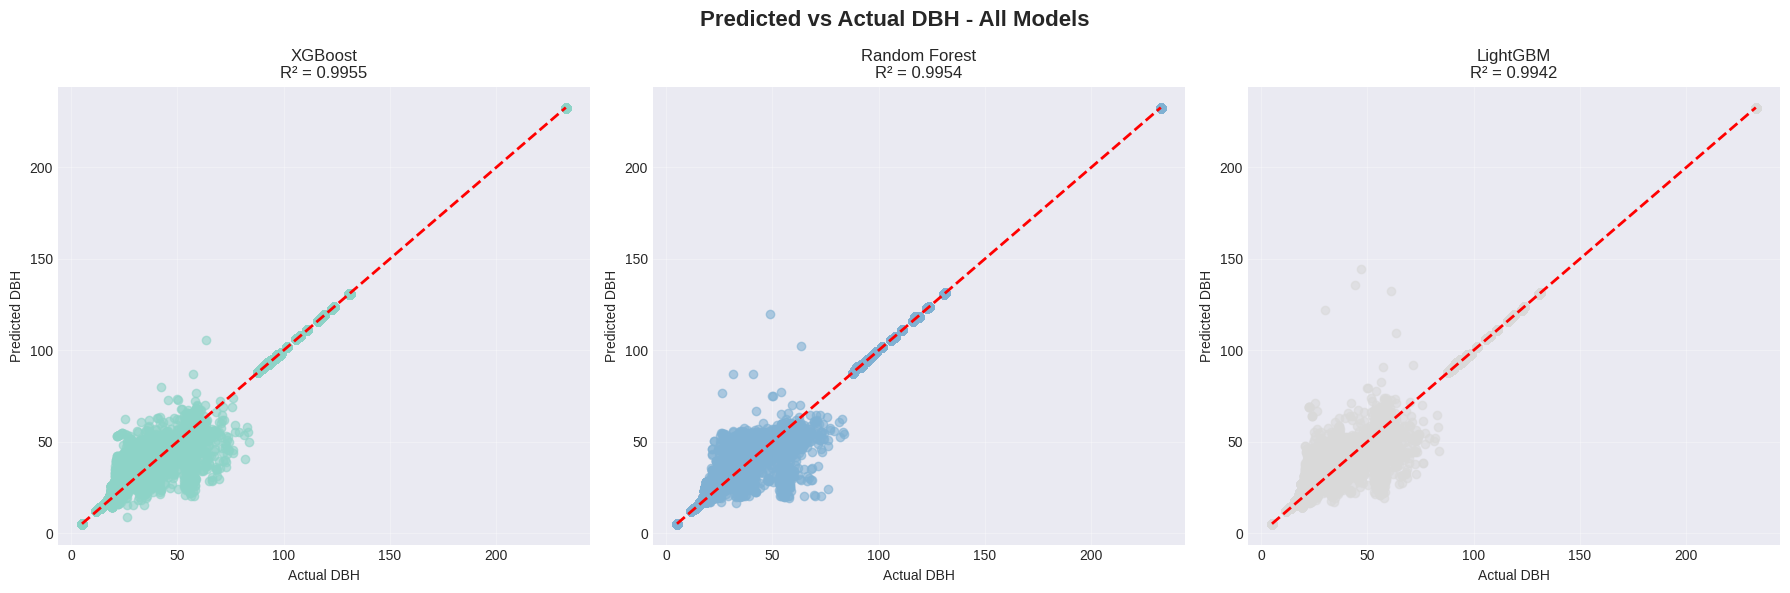

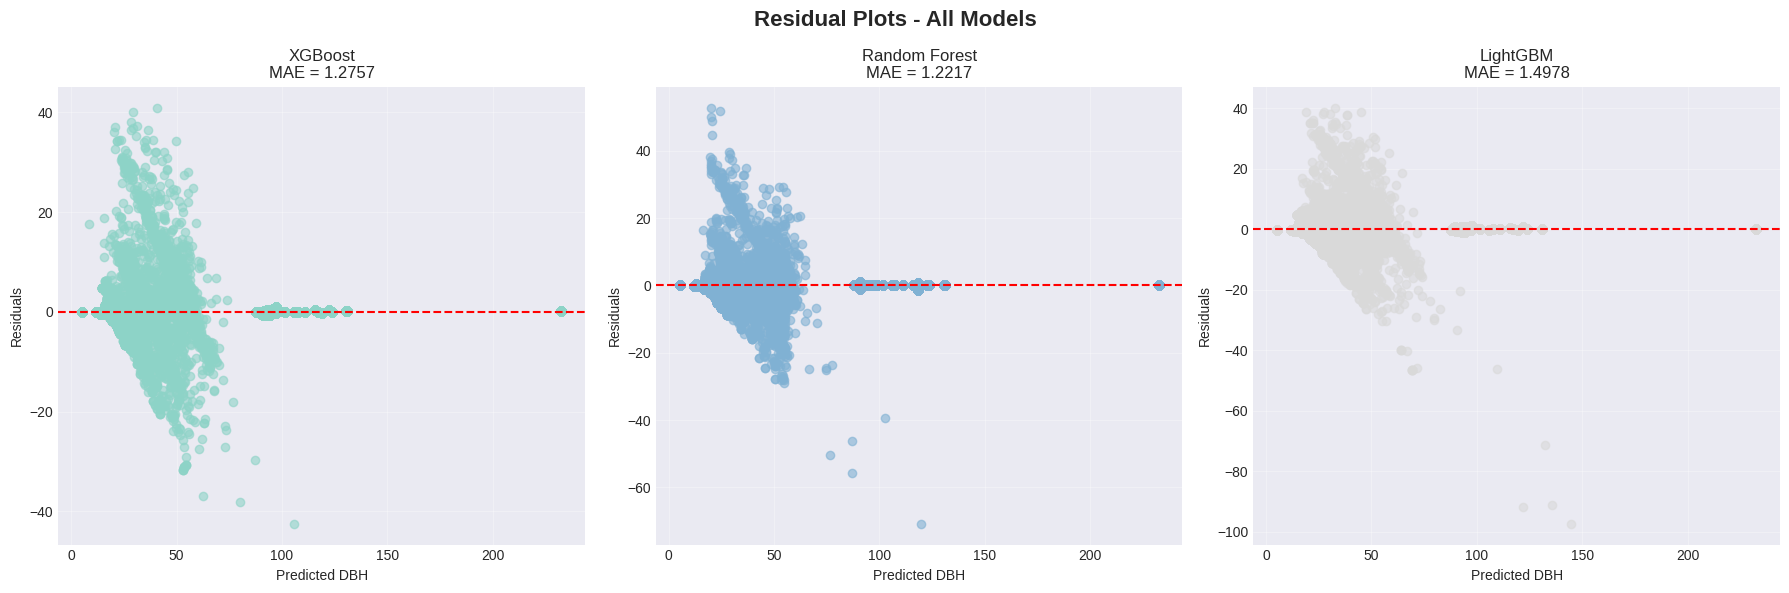

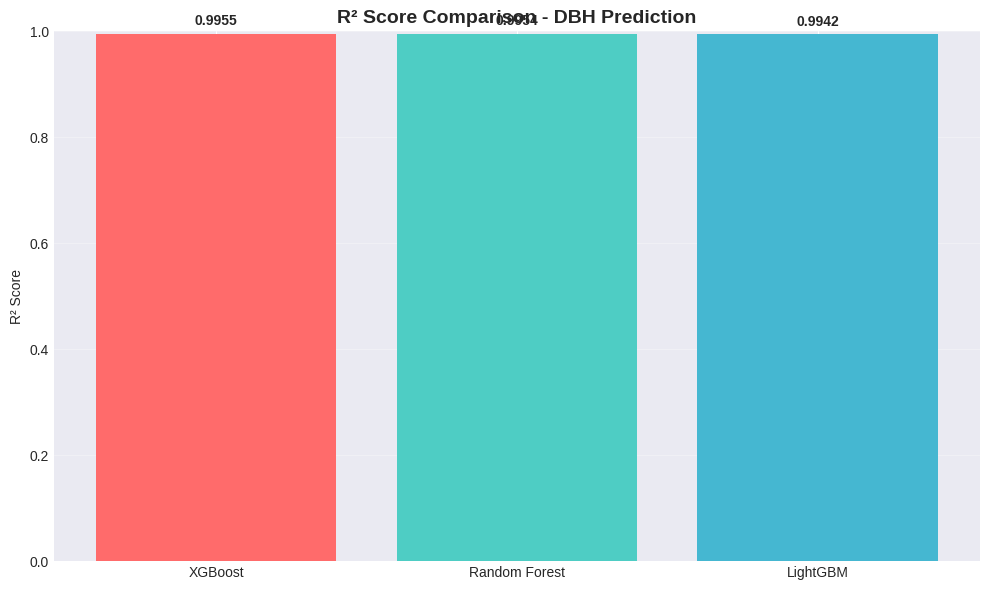

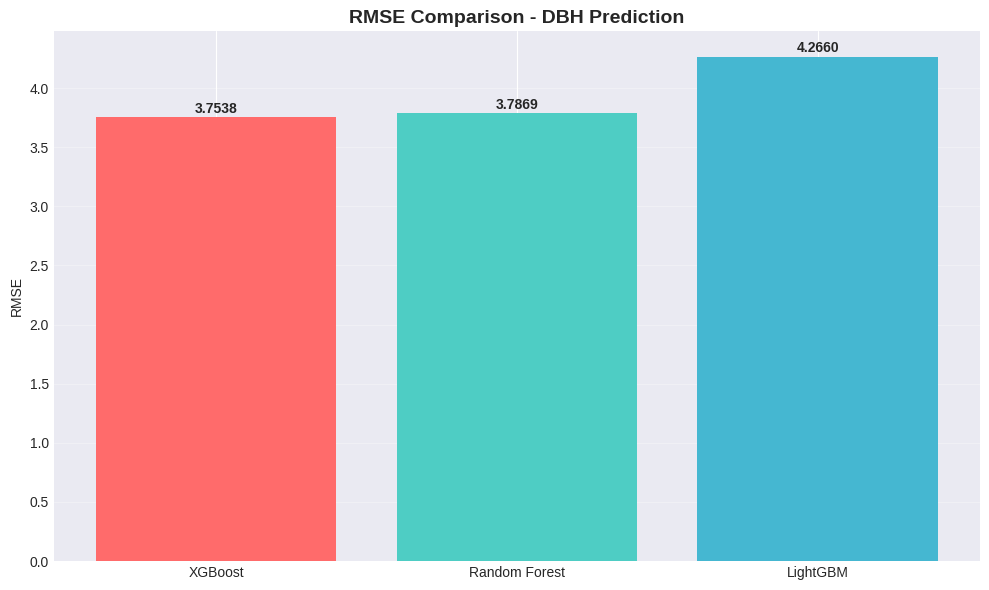


🔍 Feature Importance Analysis:


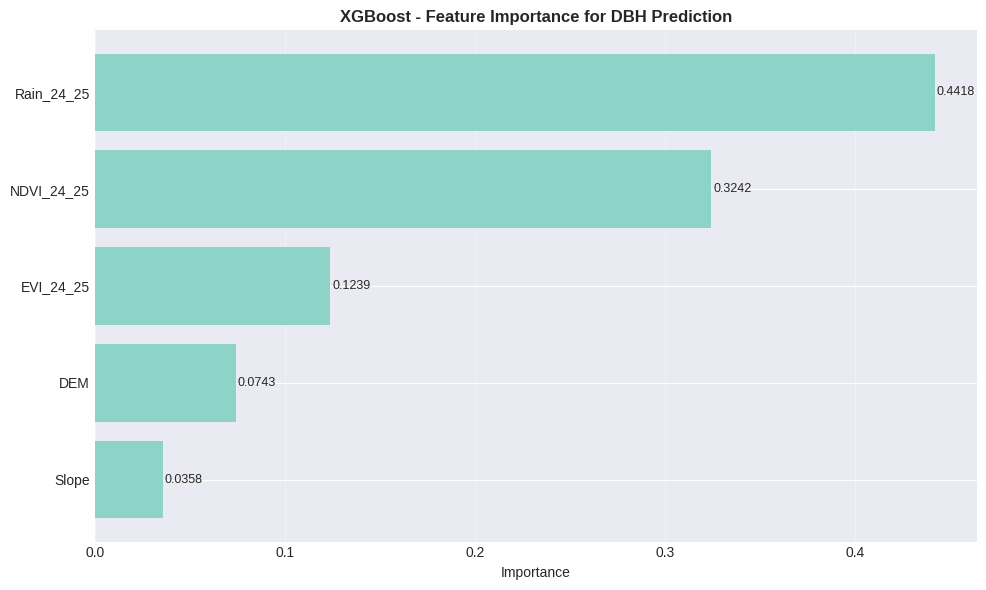


XGBoost - Feature Importance:
  Rain_24_25: 0.4418
  NDVI_24_25: 0.3242
  EVI_24_25: 0.1239
  DEM: 0.0743
  Slope: 0.0358


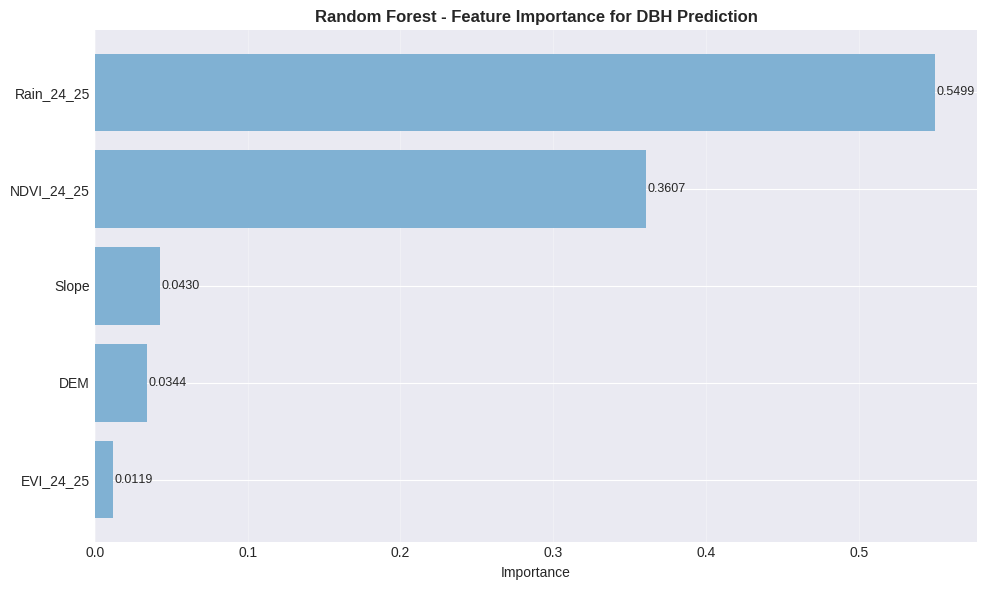


Random Forest - Feature Importance:
  Rain_24_25: 0.5499
  NDVI_24_25: 0.3607
  Slope: 0.0430
  DEM: 0.0344
  EVI_24_25: 0.0119


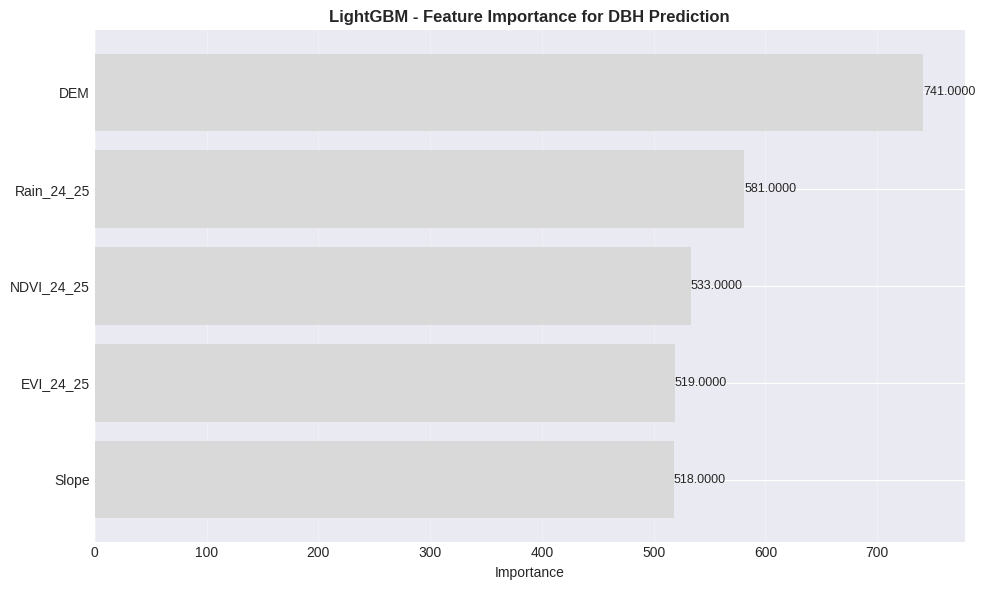


LightGBM - Feature Importance:
  DEM: 741.0000
  Rain_24_25: 581.0000
  NDVI_24_25: 533.0000
  EVI_24_25: 519.0000
  Slope: 518.0000

🎯 Cross-Validation Results (5-fold):
XGBoost:
  R²: -0.9881 (±2.2697)
  MAE: 26.3114 (±11.2984)
Random Forest:
  R²: -1.2797 (±2.6576)
  MAE: 26.8853 (±12.2957)
LightGBM:
  R²: -0.6235 (±1.7668)
  MAE: 22.8807 (±11.8645)

📊 Feature Correlation with DBH:
            correlation
Rain_24_25     0.627988
NDVI_24_25     0.622245
EVI_24_25      0.140909
DEM            0.053872
Slope          0.020164


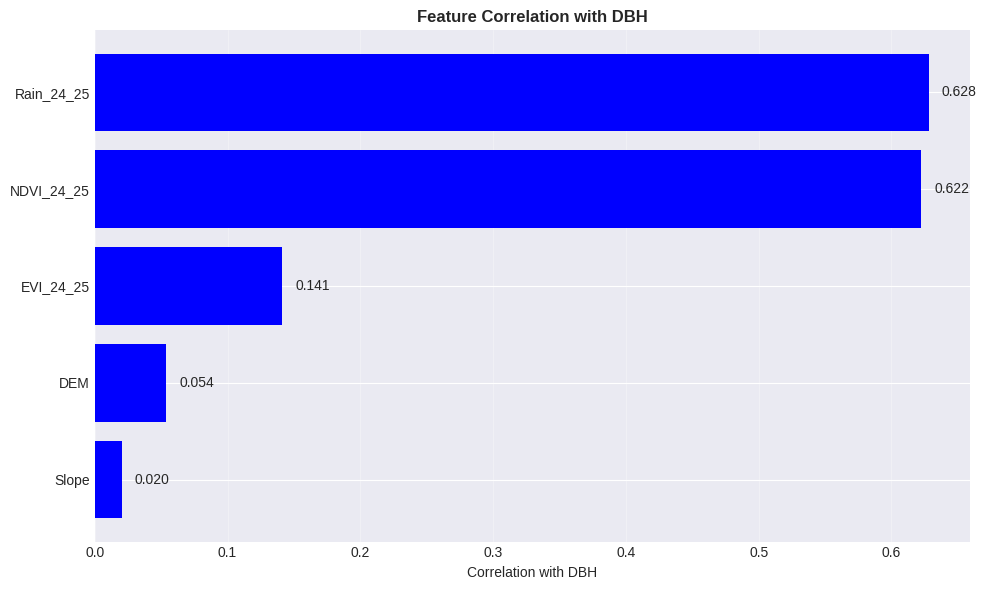


📋 Model Performance Summary:
------------------------------------------------------------
Model           R²         MAE        RMSE       MAPE      
------------------------------------------------------------
XGBoost         0.9955     1.2757     3.7538     3.80      %
Random Forest   0.9954     1.2217     3.7869     3.65      %
LightGBM        0.9942     1.4978     4.2660     4.54      %


In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Use the available features from your provided list that exist in gdf_extracted
available_features = [
    "NDVI_24_25",
    "EVI_24_25",
    "Rain_24_25",
    "Slope",
    "DEM"
]

# Check if LAI_24_25 exists and add it if available
if 'LAI_24_25' in gdf_extracted.columns:
    available_features.append('LAI_24_25')
    print("LAI_24_25 column found and included in features")
else:
    print("LAI_24_25 column not found, using available features")

print(f"Using features: {available_features}")

# Prepare features and target
X = gdf_extracted[available_features]
y = gdf_extracted['DBH']  # Using continuous DBH values

# Check for missing values
print(f"\nMissing values in features:")
print(X.isnull().sum())
print(f"\nMissing values in target: {y.isnull().sum()}")

# Drop rows with missing values if any
if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("Dropping rows with missing values...")
    valid_mask = X.notnull().all(axis=1) & y.notnull()
    X = X[valid_mask]
    y = y[valid_mask]
    print(f"Remaining samples: {len(X)}")

# Optional: Scale features (often helps with tree-based models too)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=available_features)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Number of features: {len(available_features)}")
print(f"Target variable: DBH (continuous)")
print(f"Target range: {y.min():.2f} to {y.max():.2f}")
print(f"Target mean: {y.mean():.2f} ± {y.std():.2f}")

# Initialize regression models
models = {
    'XGBoost': xgb.XGBRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        verbose=-1
    )
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate regression metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Calculate percentage errors
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    # Store results
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'residuals': y_test - y_pred
    }

    print(f"{name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")

# Compare model performances
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

for name, result in results.items():
    print(f"{name}:")
    print(f"  R²: {result['r2']:.4f}")
    print(f"  MAE: {result['mae']:.4f}")
    print(f"  RMSE: {result['rmse']:.4f}")
    print(f"  MAPE: {result['mape']:.2f}%")
    print()

# Find best model based on R² score
best_model_name = max(results.items(), key=lambda x: x[1]['r2'])[0]
best_result = results[best_model_name]
print(f"\n🏆 Best performing model: {best_model_name}")
print(f"R²: {best_result['r2']:.4f}, MAE: {best_result['mae']:.4f}, RMSE: {best_result['rmse']:.4f}")

# Individual plots to avoid overlay

# Plot 1: Predicted vs Actual for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Predicted vs Actual DBH - All Models', fontsize=16, fontweight='bold')

for i, (name, result) in enumerate(results.items()):
    axes[i].scatter(y_test, result['y_pred'], alpha=0.6, color=plt.cm.Set3(i/3))
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_xlabel('Actual DBH')
    axes[i].set_ylabel('Predicted DBH')
    axes[i].set_title(f'{name}\nR² = {result["r2"]:.4f}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: Residual plots for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Residual Plots - All Models', fontsize=16, fontweight='bold')

for i, (name, result) in enumerate(results.items()):
    axes[i].scatter(result['y_pred'], result['residuals'], alpha=0.6, color=plt.cm.Set3(i/3))
    axes[i].axhline(y=0, color='r', linestyle='--')
    axes[i].set_xlabel('Predicted DBH')
    axes[i].set_ylabel('Residuals')
    axes[i].set_title(f'{name}\nMAE = {result["mae"]:.4f}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 3: Individual model performance - R²
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
r2_scores = [result['r2'] for result in results.values()]
bars = plt.bar(model_names, r2_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('R² Score Comparison - DBH Prediction', fontsize=14, fontweight='bold')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Plot 4: Individual model performance - RMSE
plt.figure(figsize=(10, 6))
rmse_scores = [result['rmse'] for result in results.values()]
bars = plt.bar(model_names, rmse_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('RMSE Comparison - DBH Prediction', fontsize=14, fontweight='bold')
plt.ylabel('RMSE')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, rmse_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Feature importance analysis - Individual plots for each model
print(f"\n🔍 Feature Importance Analysis:")

for i, (name, result) in enumerate(results.items()):
    model = result['model']

    if hasattr(model, 'feature_importances_'):
        # Get feature importance
        importance = model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'feature': available_features,
            'importance': importance
        }).sort_values('importance', ascending=True)  # ascending for horizontal bar plot

        # Plot feature importance
        plt.figure(figsize=(10, 6))
        bars = plt.barh(range(len(feature_importance_df)), feature_importance_df['importance'],
                       color=plt.cm.Set3(i/3))
        plt.yticks(range(len(feature_importance_df)), feature_importance_df['feature'])
        plt.xlabel('Importance')
        plt.title(f'{name} - Feature Importance for DBH Prediction', fontweight='bold')
        plt.grid(axis='x', alpha=0.3)

        # Add value labels on bars
        for j, (idx, row) in enumerate(feature_importance_df.iterrows()):
            plt.text(row['importance'] + 0.001, j, f'{row["importance"]:.4f}',
                    va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

        # Print feature importance values
        print(f"\n{name} - Feature Importance:")
        for idx, row in feature_importance_df.sort_values('importance', ascending=False).iterrows():
            print(f"  {row['feature']}: {row['importance']:.4f}")
    else:
        print(f"\n{name}: Feature importance not available")

# Additional analysis: Cross-validation
from sklearn.model_selection import cross_val_score

print(f"\n🎯 Cross-Validation Results (5-fold):")
for name, model in models.items():
    cv_r2 = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    cv_mae = cross_val_score(model, X_scaled, y, cv=5, scoring='neg_mean_absolute_error')
    print(f"{name}:")
    print(f"  R²: {cv_r2.mean():.4f} (±{cv_r2.std():.4f})")
    print(f"  MAE: {-cv_mae.mean():.4f} (±{cv_mae.std():.4f})")

# Correlation analysis
print(f"\n📊 Feature Correlation with DBH:")
correlation_with_target = X.corrwith(y)
correlation_df = correlation_with_target.sort_values(ascending=False).to_frame('correlation')
print(correlation_df)

# Plot correlation with target
plt.figure(figsize=(10, 6))
correlation_df_sorted = correlation_df.sort_values('correlation')
bars = plt.barh(range(len(correlation_df_sorted)), correlation_df_sorted['correlation'],
                color=['red' if x < 0 else 'blue' for x in correlation_df_sorted['correlation']])
plt.yticks(range(len(correlation_df_sorted)), correlation_df_sorted.index)
plt.xlabel('Correlation with DBH')
plt.title('Feature Correlation with DBH', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(correlation_df_sorted.iterrows()):
    plt.text(row['correlation'] + (0.01 if row['correlation'] >= 0 else -0.01), i,
             f'{row["correlation"]:.3f}',
             va='center', ha='left' if row['correlation'] >= 0 else 'right')

plt.tight_layout()
plt.show()

# Summary table
print("\n📋 Model Performance Summary:")
print("-" * 60)
print(f"{'Model':<15} {'R²':<10} {'MAE':<10} {'RMSE':<10} {'MAPE':<10}")
print("-" * 60)
for name, result in results.items():
    print(f"{name:<15} {result['r2']:<10.4f} {result['mae']:<10.4f} {result['rmse']:<10.4f} {result['mape']:<10.2f}%")

Model expects 5 features
Model was trained on features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope']

Processing period: 2024_2025
Checking raster shapes and metadata...
  NDVI_24_25 (from NDVI): (851, 2089)
  EVI_24_25 (from EVI): (851, 2089)
  Rain_24_25 (from Rain): (851, 2089)
  LAI_24_25 (from LAI): (851, 2089)
  Slope (from Slope): (427, 1045)
Rasters have different shapes, resampling to common grid...
Using Slope as reference with shape (427, 1045)
  NDVI_24_25: resampling from (851, 2089) to (427, 1045)
  EVI_24_25: resampling from (851, 2089) to (427, 1045)
  Rain_24_25: resampling from (851, 2089) to (427, 1045)
  LAI_24_25: resampling from (851, 2089) to (427, 1045)
  Slope: using original
Stacked data shape: (427, 1045, 5)
Using features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope']
Predicting for 191848 valid pixels (43.0% of total)...


Predicting batches: 100%|██████████| 2/2 [00:01<00:00,  1.72it/s]


Output saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_2024_2025.tif
✓ Successfully processed 2024_2025


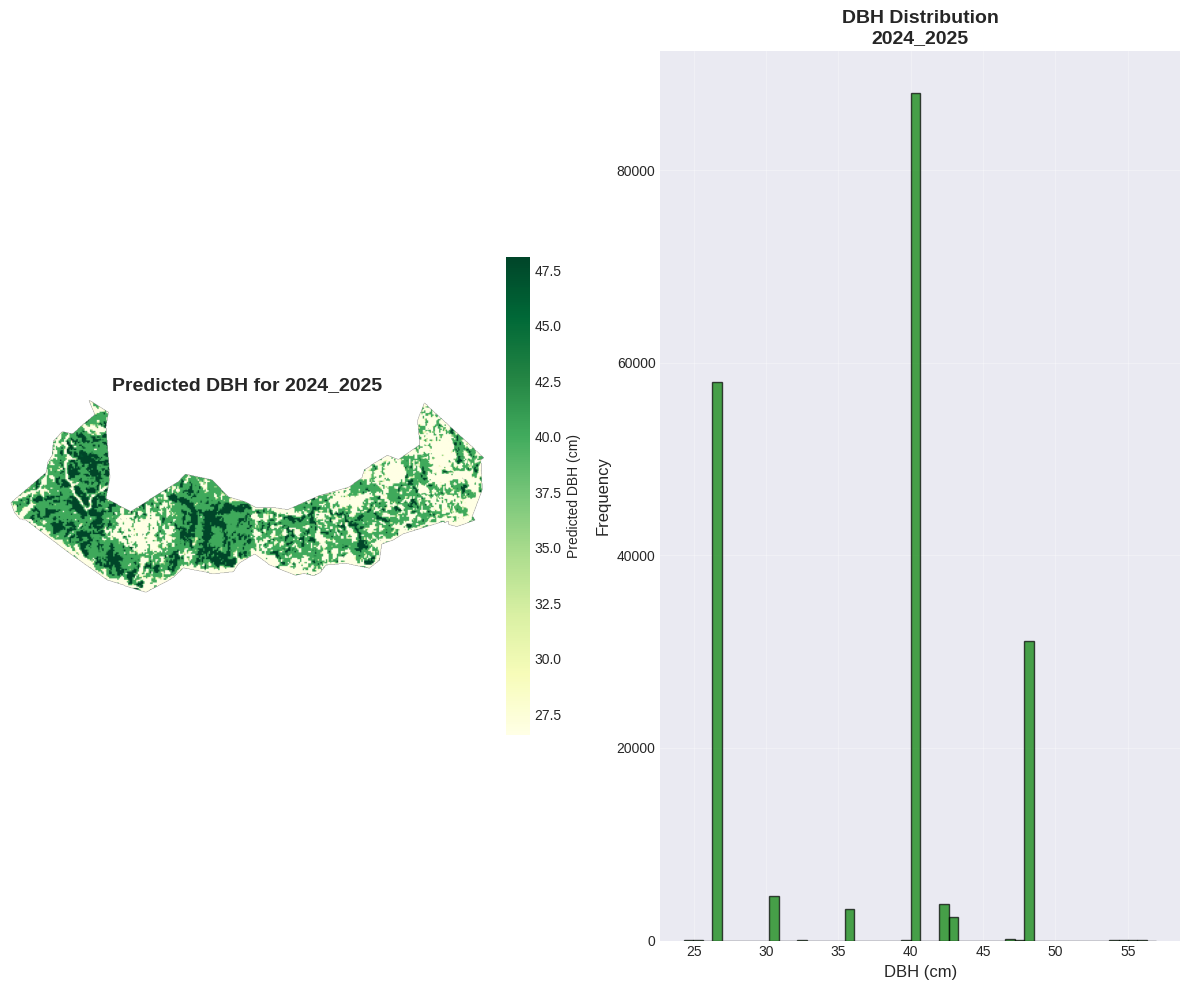


📊 DBH Statistics for 2024_2025:
   Min: 24.33 cm
   Max: 56.98 cm
   Mean: 37.11 cm
   Median: 40.16 cm
   Std: 7.71 cm

Processing period: 2019_2020
Checking raster shapes and metadata...
  NDVI_24_25 (from NDVI): (851, 2089)
  EVI_24_25 (from EVI): (851, 2089)
  Rain_24_25 (from Rain): (851, 2089)
  LAI_24_25 (from LAI): (851, 2089)
  Slope (from Slope): (427, 1045)
Rasters have different shapes, resampling to common grid...
Using Slope as reference with shape (427, 1045)
  NDVI_24_25: resampling from (851, 2089) to (427, 1045)
  EVI_24_25: resampling from (851, 2089) to (427, 1045)
  Rain_24_25: resampling from (851, 2089) to (427, 1045)
  LAI_24_25: resampling from (851, 2089) to (427, 1045)
  Slope: using original
Stacked data shape: (427, 1045, 5)
Using features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope']
Predicting for 191848 valid pixels (43.0% of total)...


Predicting batches: 100%|██████████| 2/2 [00:02<00:00,  1.42s/it]


Output saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_2019_2020.tif
✓ Successfully processed 2019_2020


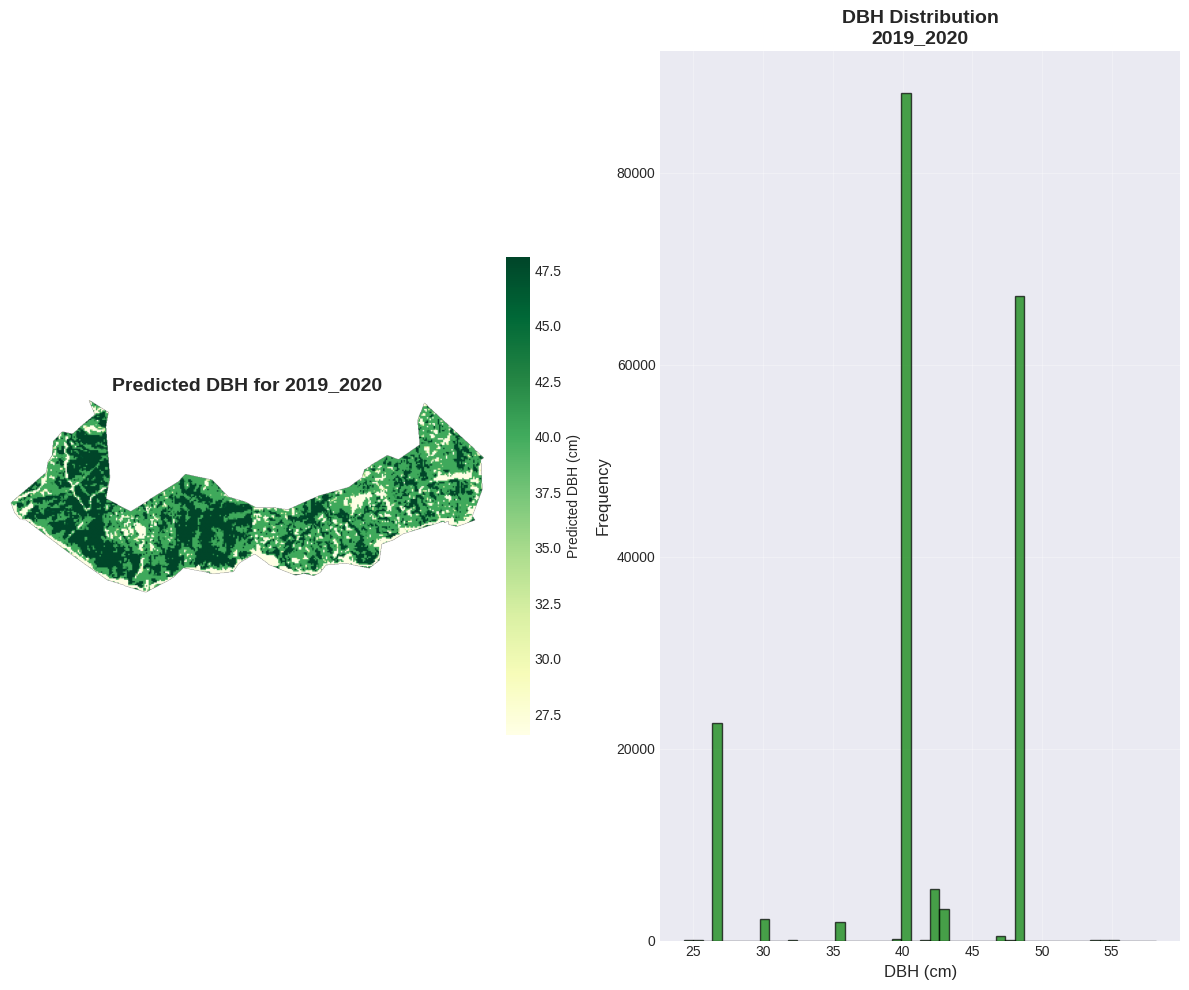


📊 DBH Statistics for 2019_2020:
   Min: 24.33 cm
   Max: 58.21 cm
   Mean: 41.30 cm
   Median: 40.16 cm
   Std: 6.66 cm

Processing period: 2014_2015
Checking raster shapes and metadata...
  NDVI_24_25 (from NDVI): (851, 2089)
  EVI_24_25 (from EVI): (851, 2089)
  Rain_24_25 (from Rain): (851, 2089)
  LAI_24_25 (from LAI): (851, 2089)
  Slope (from Slope): (427, 1045)
Rasters have different shapes, resampling to common grid...
Using Slope as reference with shape (427, 1045)
  NDVI_24_25: resampling from (851, 2089) to (427, 1045)
  EVI_24_25: resampling from (851, 2089) to (427, 1045)
  Rain_24_25: resampling from (851, 2089) to (427, 1045)
  LAI_24_25: resampling from (851, 2089) to (427, 1045)
  Slope: using original
Stacked data shape: (427, 1045, 5)
Using features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope']
Predicting for 191848 valid pixels (43.0% of total)...


Predicting batches: 100%|██████████| 2/2 [00:01<00:00,  1.65it/s]


Output saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_2014_2015.tif
✓ Successfully processed 2014_2015


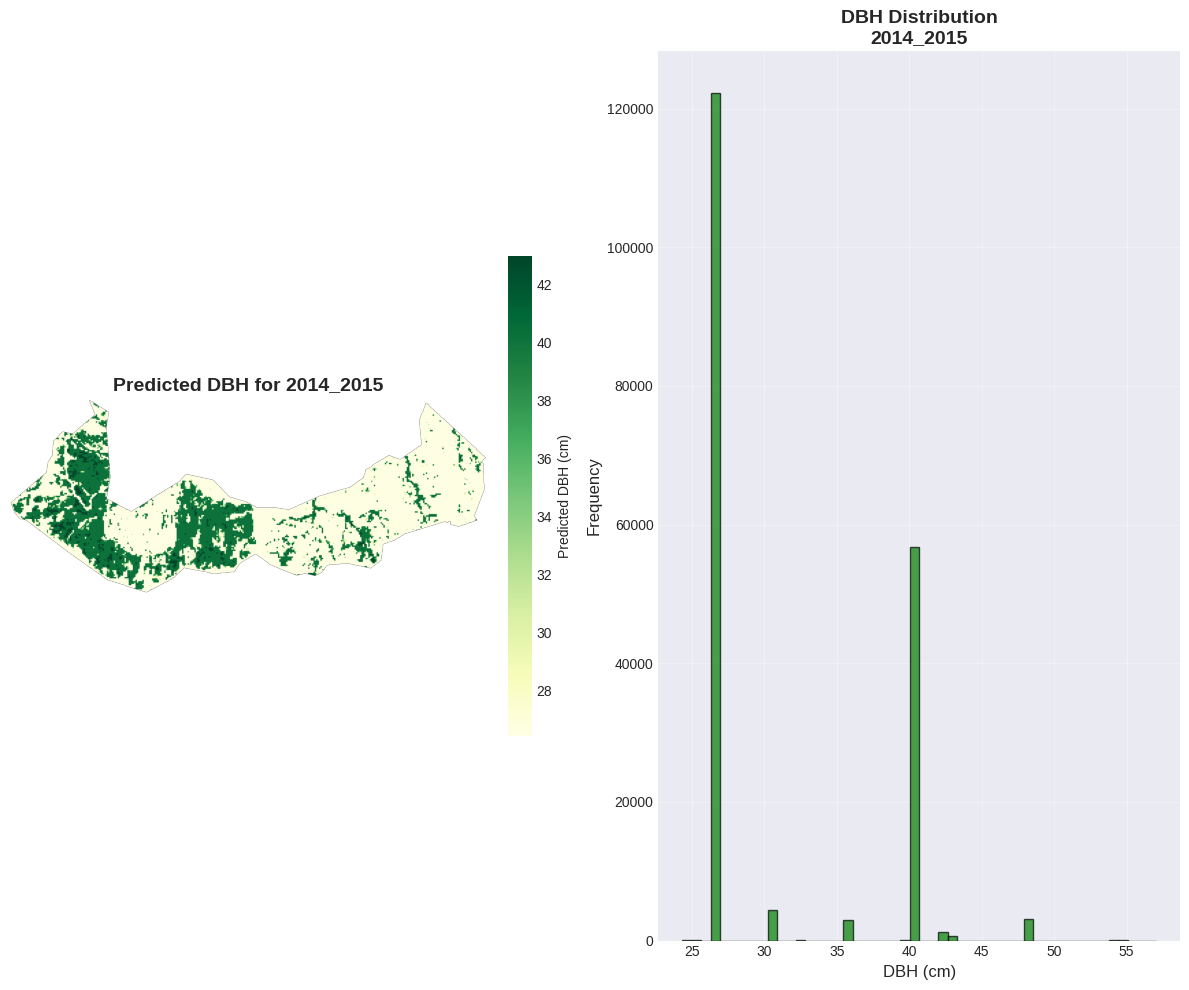


📊 DBH Statistics for 2014_2015:
   Min: 24.33 cm
   Max: 57.05 cm
   Mean: 31.36 cm
   Median: 26.60 cm
   Std: 6.61 cm

Processing period: 2009_2010
Checking raster shapes and metadata...
  NDVI_24_25 (from NDVI): (851, 2089)
  EVI_24_25 (from EVI): (851, 2089)
  Rain_24_25 (from Rain): (2501, 6248)
  LAI_24_25 (from LAI): (851, 2089)
  Slope (from Slope): (427, 1045)
Rasters have different shapes, resampling to common grid...
Using Slope as reference with shape (427, 1045)
  NDVI_24_25: resampling from (851, 2089) to (427, 1045)
  EVI_24_25: resampling from (851, 2089) to (427, 1045)
  Rain_24_25: resampling from (2501, 6248) to (427, 1045)
  LAI_24_25: resampling from (851, 2089) to (427, 1045)
  Slope: using original
Stacked data shape: (427, 1045, 5)
Using features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope']
Predicting for 191848 valid pixels (43.0% of total)...


Predicting batches: 100%|██████████| 2/2 [00:01<00:00,  1.82it/s]


Output saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_2009_2010.tif
✓ Successfully processed 2009_2010


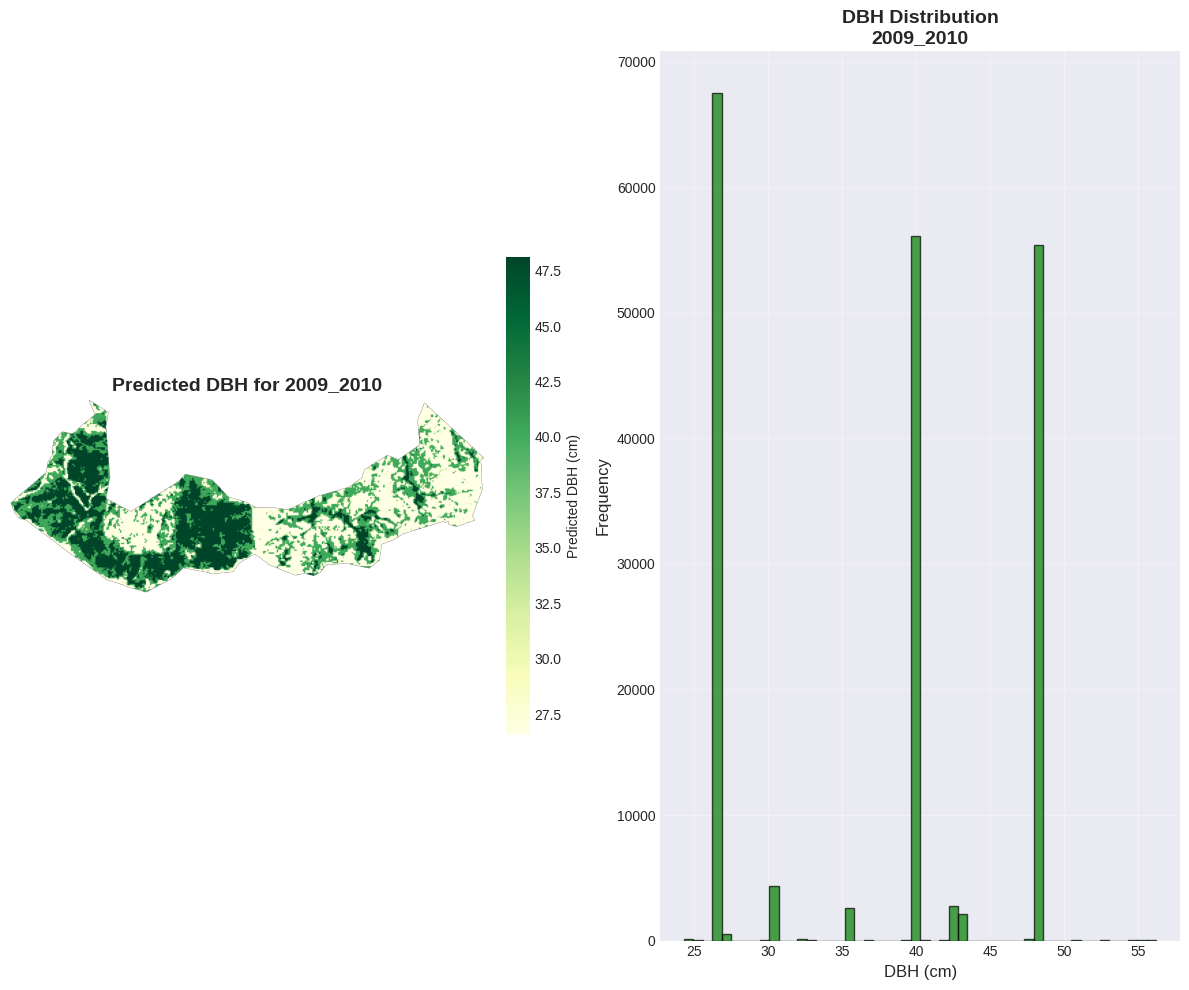


📊 DBH Statistics for 2009_2010:
   Min: 24.33 cm
   Max: 56.23 cm
   Mean: 37.43 cm
   Median: 40.16 cm
   Std: 8.87 cm

Processing period: 2004_2005
Checking raster shapes and metadata...
  NDVI_24_25 (from NDVI): (143, 349)
  EVI_24_25 (from EVI): (143, 349)
  Rain_24_25 (from Rain): (2501, 6248)
  LAI_24_25 (from LAI): (143, 349)
  Slope (from Slope): (427, 1045)
Rasters have different shapes, resampling to common grid...
Using Slope as reference with shape (427, 1045)
  NDVI_24_25: resampling from (143, 349) to (427, 1045)
  EVI_24_25: resampling from (143, 349) to (427, 1045)
  Rain_24_25: resampling from (2501, 6248) to (427, 1045)
  LAI_24_25: resampling from (143, 349) to (427, 1045)
  Slope: using original
Stacked data shape: (427, 1045, 5)
Using features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope']
Predicting for 191821 valid pixels (43.0% of total)...


Predicting batches: 100%|██████████| 2/2 [00:01<00:00,  1.89it/s]


Output saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_2004_2005.tif
✓ Successfully processed 2004_2005


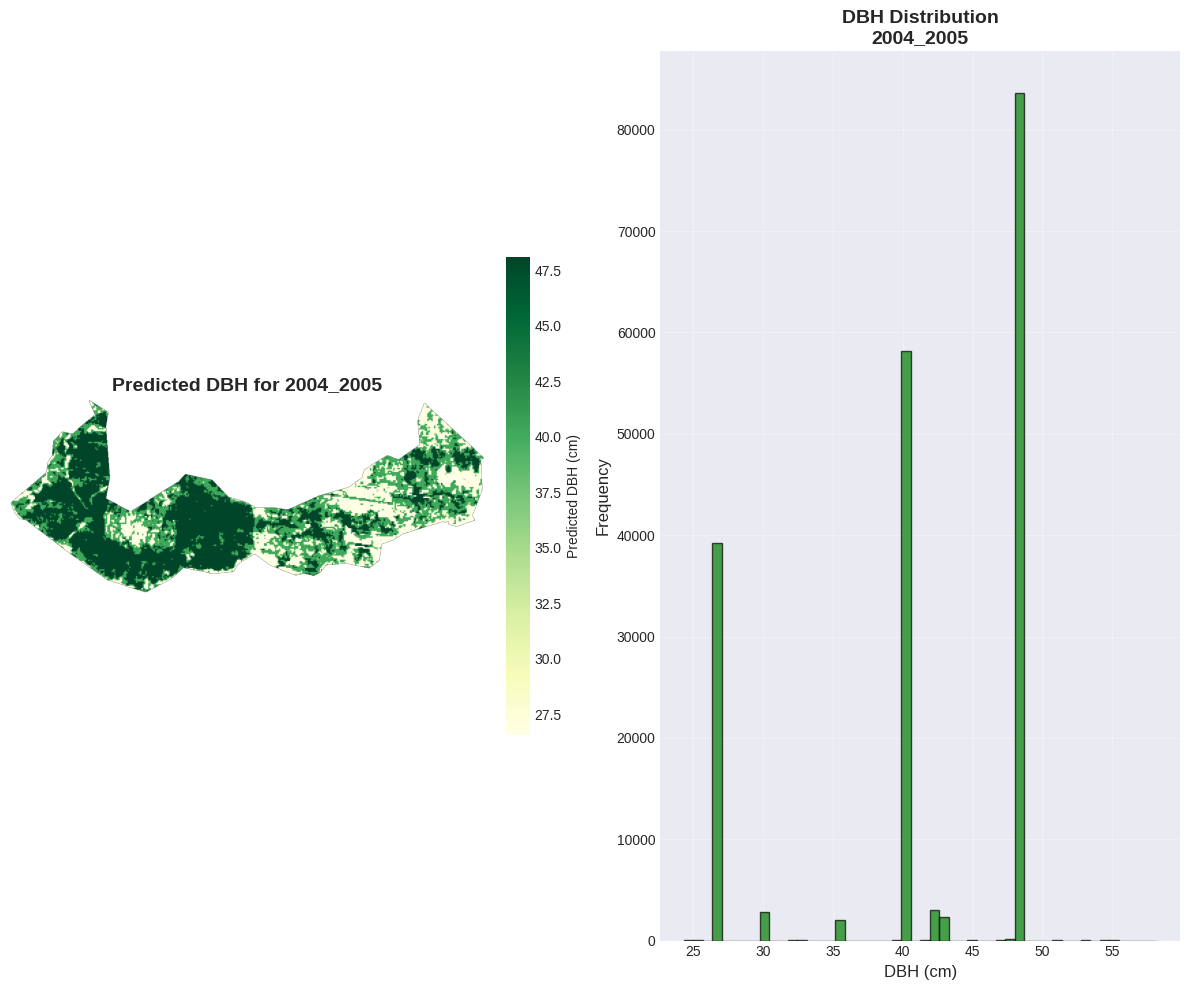


📊 DBH Statistics for 2004_2005:
   Min: 24.33 cm
   Max: 58.16 cm
   Mean: 40.73 cm
   Median: 40.17 cm
   Std: 8.17 cm

Processing period: 1999_2000
Checking raster shapes and metadata...
  NDVI_24_25 (from NDVI): (851, 2089)
  EVI_24_25 (from EVI): (851, 2089)
  Rain_24_25 (from Rain): (2501, 6248)
  LAI_24_25 (from LAI): (851, 2089)
  Slope (from Slope): (427, 1045)
Rasters have different shapes, resampling to common grid...
Using Slope as reference with shape (427, 1045)
  NDVI_24_25: resampling from (851, 2089) to (427, 1045)
  EVI_24_25: resampling from (851, 2089) to (427, 1045)
  Rain_24_25: resampling from (2501, 6248) to (427, 1045)
  LAI_24_25: resampling from (851, 2089) to (427, 1045)
  Slope: using original
Stacked data shape: (427, 1045, 5)
Using features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope']
Predicting for 186734 valid pixels (41.8% of total)...


Predicting batches: 100%|██████████| 2/2 [00:00<00:00,  2.22it/s]


Output saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_1999_2000.tif
✓ Successfully processed 1999_2000


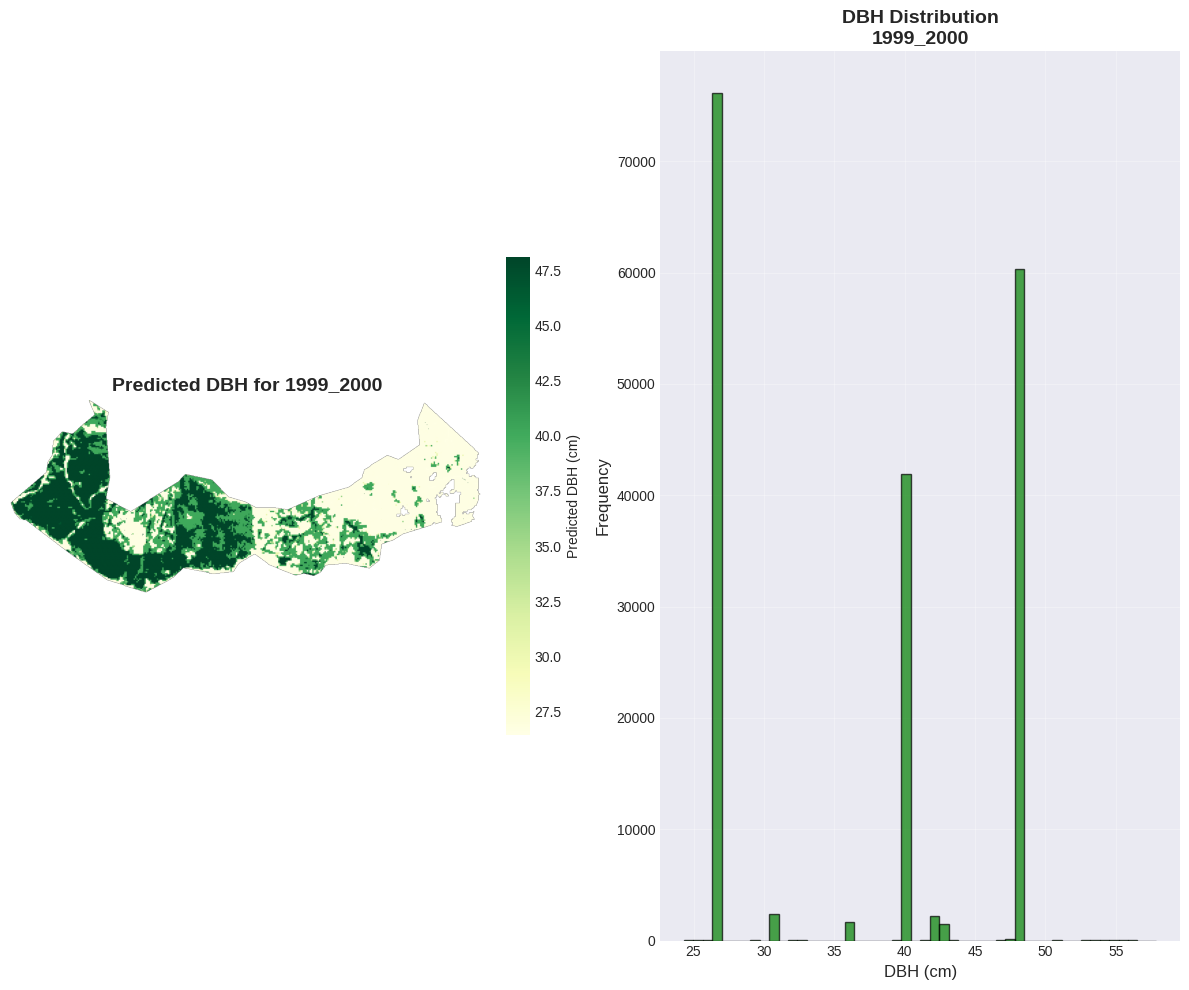


📊 DBH Statistics for 1999_2000:
   Min: 24.33 cm
   Max: 57.88 cm
   Mean: 37.08 cm
   Median: 40.16 cm
   Std: 9.37 cm

Processing period: 1994_1995
Checking raster shapes and metadata...
  NDVI_24_25 (from NDVI): (851, 2089)
  EVI_24_25 (from EVI): (851, 2089)
  Rain_24_25 (from Rain): (2501, 6248)
  LAI_24_25 (from LAI): (851, 2089)
  Slope (from Slope): (427, 1045)
Rasters have different shapes, resampling to common grid...
Using Slope as reference with shape (427, 1045)
  NDVI_24_25: resampling from (851, 2089) to (427, 1045)
  EVI_24_25: resampling from (851, 2089) to (427, 1045)
  Rain_24_25: resampling from (2501, 6248) to (427, 1045)
  LAI_24_25: resampling from (851, 2089) to (427, 1045)
  Slope: using original
Stacked data shape: (427, 1045, 5)
Using features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope']
Predicting for 191848 valid pixels (43.0% of total)...


Predicting batches: 100%|██████████| 2/2 [00:01<00:00,  1.68it/s]


Output saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_1994_1995.tif
✓ Successfully processed 1994_1995


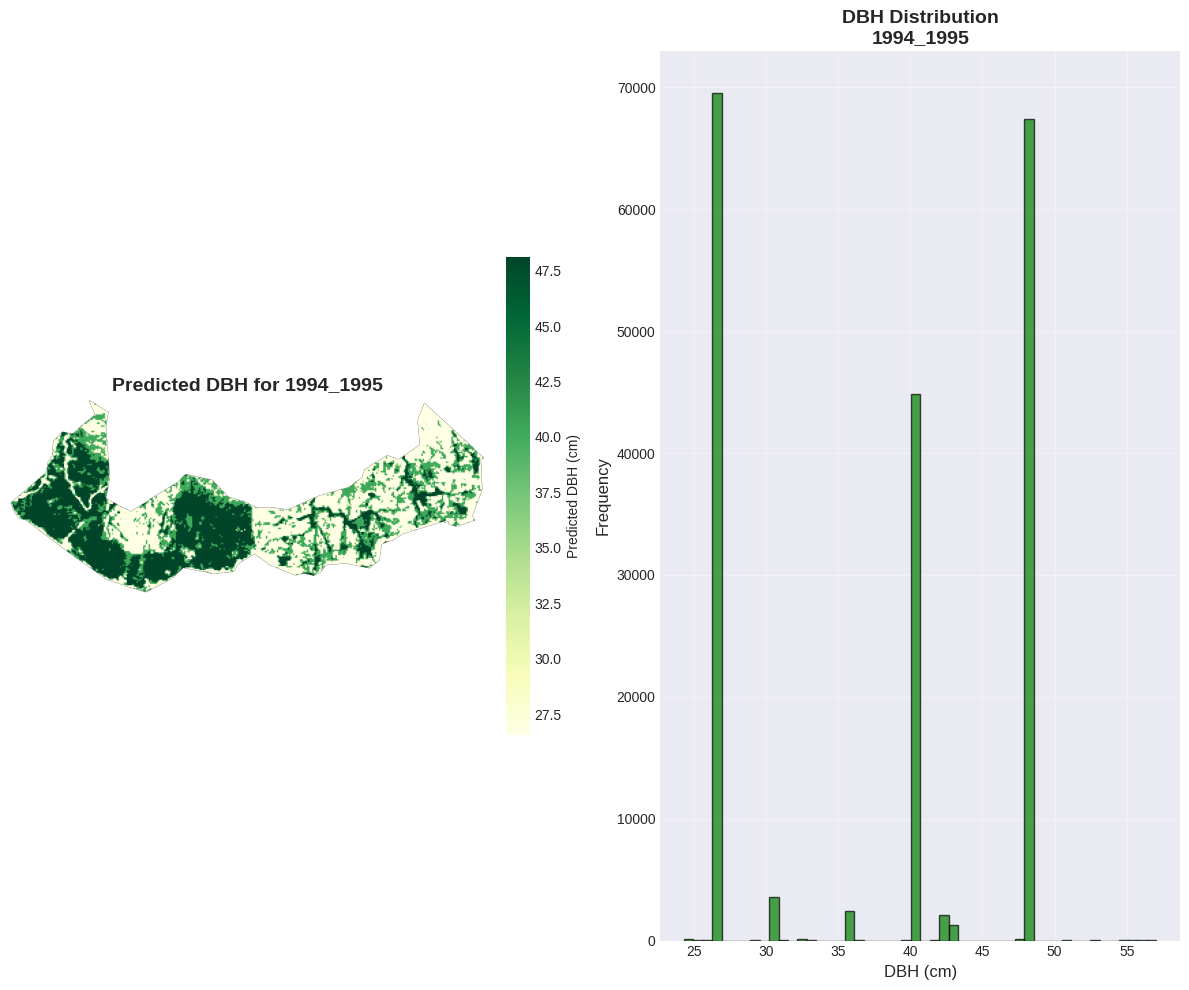


📊 DBH Statistics for 1994_1995:
   Min: 24.33 cm
   Max: 57.05 cm
   Mean: 37.83 cm
   Median: 40.16 cm
   Std: 9.26 cm

Processing period: 1989_1990
Checking raster shapes and metadata...
  NDVI_24_25 (from NDVI): (851, 2089)
  EVI_24_25 (from EVI): (851, 2089)
  Rain_24_25 (from Rain): (2501, 6248)
  LAI_24_25 (from LAI): (851, 2089)
  Slope (from Slope): (427, 1045)
Rasters have different shapes, resampling to common grid...
Using Slope as reference with shape (427, 1045)
  NDVI_24_25: resampling from (851, 2089) to (427, 1045)
  EVI_24_25: resampling from (851, 2089) to (427, 1045)
  Rain_24_25: resampling from (2501, 6248) to (427, 1045)
  LAI_24_25: resampling from (851, 2089) to (427, 1045)
  Slope: using original
Stacked data shape: (427, 1045, 5)
Using features: ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope']
Predicting for 191848 valid pixels (43.0% of total)...


Predicting batches: 100%|██████████| 2/2 [00:00<00:00,  2.86it/s]


Output saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_1989_1990.tif
✓ Successfully processed 1989_1990


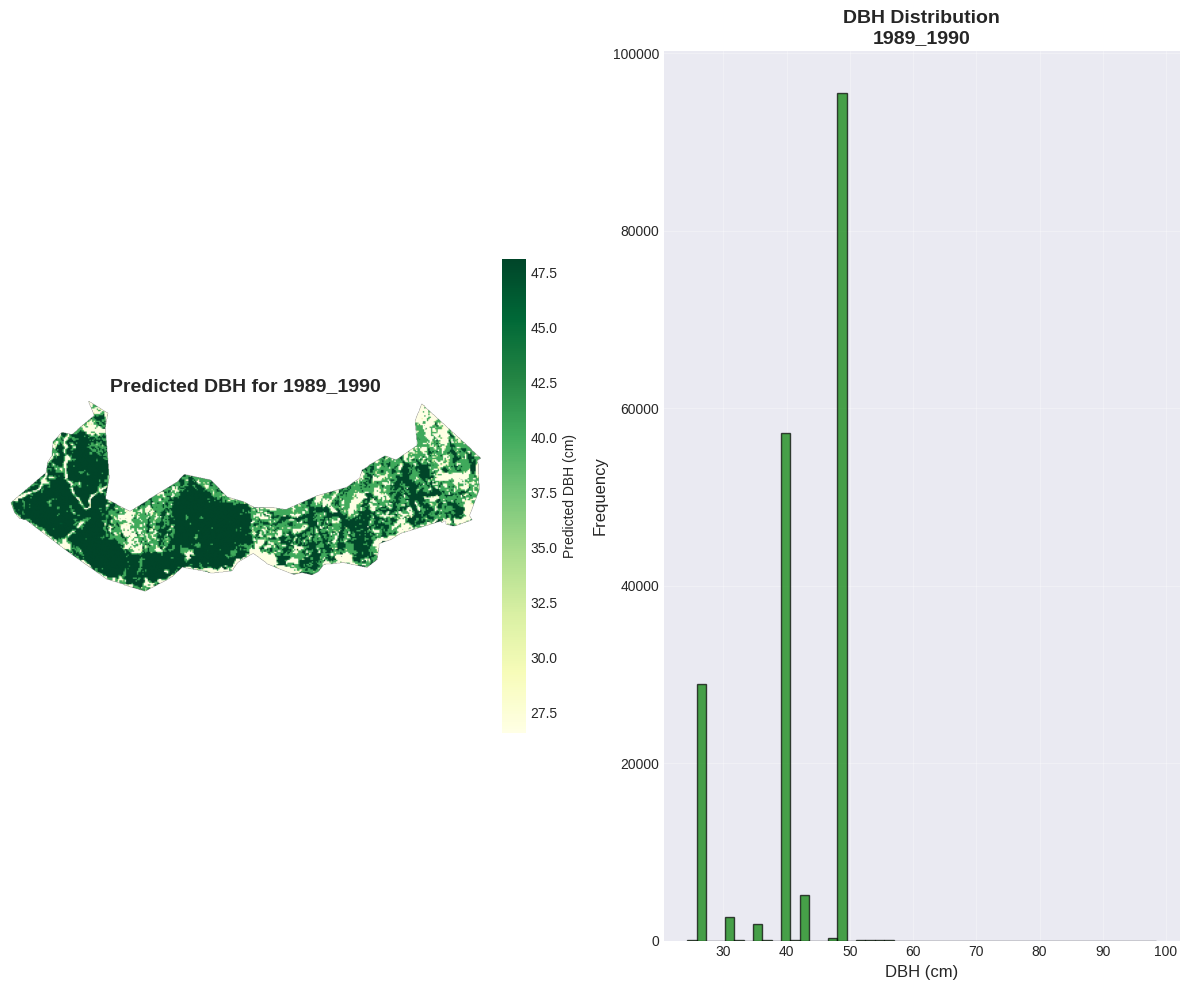


📊 DBH Statistics for 1989_1990:
   Min: 24.33 cm
   Max: 98.44 cm
   Mean: 41.97 cm
   Median: 43.02 cm
   Std: 7.59 cm

PROCESSING SUMMARY
Total periods: 8
Successfully processed: 8
Failed: 0

✅ Successfully processed periods:
  - 2024_2025
  - 2019_2020
  - 2014_2015
  - 2009_2010
  - 2004_2005
  - 1999_2000
  - 1994_1995
  - 1989_1990

🎯 All DBH rasters saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled
Processing complete!


In [58]:
import numpy as np
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestRegressor
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Use the Random Forest model that's already in memory from our training
# First, let's check what features the model expects
print(f"Model expects {model.n_features_in_} features")

# Get the feature names that were used during training
# Based on your training data, the features should be:
# We need to use the same feature names that were used during training
# If you trained with 'NDVI_24_25', 'EVI_24_25', etc., then use those
# But our raster dictionary has different keys, so we need a mapping

# Let me create a feature mapping based on your training features
feature_mapping = {
    'NDVI_24_25': 'NDVI',
    'EVI_24_25': 'EVI',
    'Rain_24_25': 'Rain',
    'LAI_24_25': 'LAI',
    'Slope': 'Slope'
    # Note: DEM is probably not in the model if it expects 5 features
}

# The features the model was trained on (based on your training)
feature_order = ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope']
print(f"Model was trained on features: {feature_order}")

# Define all the time periods and their raster paths
time_periods = {
    "2024_2025": {
        "NDVI": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2024_2025_resampled.tif",
        "EVI": "/content/drive/MyDrive/Kamatira Model Data/EVI_2024_2025_resampled.tif",
        "Rain": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2024_2025_resampled.tif",
        "LAI": "/content/drive/MyDrive/Kamatira Model Data/LAI_2024_2025.tif",
        "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
        "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
    },
    "2019_2020": {
        "NDVI": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2019_2020_resampled.tif",
        "EVI": "/content/drive/MyDrive/Kamatira Model Data/EVI_2019_2020_resampled.tif",
        "Rain": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2019_2020_resampled.tif",
        "LAI": "/content/drive/MyDrive/Kamatira Model Data/LAI_2019_2020.tif",
        "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
        "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
    },
    "2014_2015": {
        "NDVI": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2014_2015_resampled.tif",
        "EVI": "/content/drive/MyDrive/Kamatira Model Data/EVI_2014_2015_resampled.tif",
        "Rain": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2014_2015_resampled.tif",
        "LAI": "/content/drive/MyDrive/Kamatira Model Data/LAI_2014_2015.tif",
        "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
        "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
    },
    "2009_2010": {
        "NDVI": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2009_2010.tif",
        "EVI": "/content/drive/MyDrive/Kamatira Model Data/EVI_2009_2010.tif",
        "Rain": "/content/drive/MyDrive/Kamatira Model Data/Precip_2010.tif",
        "LAI": "/content/drive/MyDrive/Kamatira Model Data/LAI_2009_2010.tif",
        "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
        "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
    },
    "2004_2005": {
        "NDVI": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2004_2004.tif",
        "EVI": "/content/drive/MyDrive/Kamatira Model Data/EVI_2004_2004.tif",
        "Rain": "/content/drive/MyDrive/Kamatira Model Data/Precip_2005.tif",
        "LAI": "/content/drive/MyDrive/Kamatira Model Data/LAI_2004_2004.tif",
        "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
        "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
    },
    "1999_2000": {
        "NDVI": "/content/drive/MyDrive/Kamatira Model Data/NDVI_1999_2000.tif",
        "EVI": "/content/drive/MyDrive/Kamatira Model Data/EVI_1999_2000.tif",
        "Rain": "/content/drive/MyDrive/Kamatira Model Data/Precip_2000.tif",
        "LAI": "/content/drive/MyDrive/Kamatira Model Data/LAI_1999_2000.tif",
        "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
        "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
    },
    "1994_1995": {
        "NDVI": "/content/drive/MyDrive/Kamatira Model Data/NDVI_1994_1995.tif",
        "EVI": "/content/drive/MyDrive/Kamatira Model Data/EVI_1994_1995.tif",
        "Rain": "/content/drive/MyDrive/Kamatira Model Data/Precip_1995.tif",
        "LAI": "/content/drive/MyDrive/Kamatira Model Data/LAI_1994_1995.tif",
        "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
        "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
    },
    "1989_1990": {
        "NDVI": "/content/drive/MyDrive/Kamatira Model Data/NDVI_1989_1990.tif",
        "EVI": "/content/drive/MyDrive/Kamatira Model Data/EVI_1989_1990.tif",
        "Rain": "/content/drive/MyDrive/Kamatira Model Data/Precip1990.tif",
        "LAI": "/content/drive/MyDrive/Kamatira Model Data/LAI_1989_1990.tif",
        "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
        "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
    }
}

# Output directory
output_dir = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled"
os.makedirs(output_dir, exist_ok=True)

def get_raster_metadata(raster_path):
    """Get metadata from a raster file"""
    with rasterio.open(raster_path) as src:
        return {
            'shape': src.shape,
            'transform': src.transform,
            'crs': src.crs,
            'profile': src.profile
        }

def resample_to_target(raster_path, target_shape, target_transform, target_crs, method='nearest'):
    """Resample a raster to match target shape and transform"""
    from rasterio.warp import reproject, Resampling

    with rasterio.open(raster_path) as src:
        # Read the data
        data = src.read(1)

        # Create destination array
        destination = np.zeros(target_shape, dtype=np.float32)

        # Reproject
        reproject(
            source=data,
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.nearest if method == 'nearest' else Resampling.bilinear
        )

        return destination

def map_raster_paths(raster_dict, feature_mapping):
    """Map raster dictionary keys to match model feature names"""
    mapped_dict = {}
    for model_feature, raster_key in feature_mapping.items():
        if raster_key in raster_dict:
            mapped_dict[model_feature] = raster_dict[raster_key]
        else:
            print(f"Warning: {raster_key} not found in raster dictionary")
    return mapped_dict

def apply_model_to_rasters(model, raster_dict, feature_order, feature_mapping, output_path):
    """
    Apply trained model to rasters and save predicted output
    Handles rasters with different shapes by resampling to a common grid
    """
    print("Checking raster shapes and metadata...")

    # Map raster dictionary keys to model feature names
    mapped_raster_dict = map_raster_paths(raster_dict, feature_mapping)

    # Get metadata for all rasters
    metadata = {}
    shapes = {}
    for feature in feature_order:
        if feature in mapped_raster_dict and os.path.exists(mapped_raster_dict[feature]):
            try:
                meta = get_raster_metadata(mapped_raster_dict[feature])
                metadata[feature] = meta
                shapes[feature] = meta['shape']
                print(f"  {feature} (from {feature_mapping[feature]}): {meta['shape']}")
            except Exception as e:
                print(f"Error reading {feature}: {e}")
                return False
        else:
            print(f"Warning: {feature} raster not found")
            return False

    # Check if all rasters have the same shape
    unique_shapes = set(shapes.values())

    if len(unique_shapes) == 1:
        print("All rasters have the same shape, proceeding...")
        target_shape = list(unique_shapes)[0]
        # Use the first raster as reference
        ref_feature = feature_order[0]
        target_transform = metadata[ref_feature]['transform']
        target_crs = metadata[ref_feature]['crs']
        profile = metadata[ref_feature]['profile']
    else:
        print("Rasters have different shapes, resampling to common grid...")
        # Use Slope as reference (since it's one of the smaller ones)
        if 'Slope' in metadata:
            ref_feature = 'Slope'
        else:
            ref_feature = feature_order[0]

        target_shape = metadata[ref_feature]['shape']
        target_transform = metadata[ref_feature]['transform']
        target_crs = metadata[ref_feature]['crs']
        profile = metadata[ref_feature]['profile']
        print(f"Using {ref_feature} as reference with shape {target_shape}")

    # Read and resample if necessary
    arrays = {}
    for feature in feature_order:
        raster_path = mapped_raster_dict[feature]
        current_meta = metadata[feature]

        if (current_meta['shape'] == target_shape and
            current_meta['transform'] == target_transform and
            str(current_meta['crs']) == str(target_crs)):
            # No resampling needed
            with rasterio.open(raster_path) as src:
                arrays[feature] = src.read(1).astype(np.float32)
            print(f"  {feature}: using original")
        else:
            # Resample needed
            print(f"  {feature}: resampling from {current_meta['shape']} to {target_shape}")
            arrays[feature] = resample_to_target(
                raster_path, target_shape, target_transform, target_crs
            )

    # Create a stacked array with only the features the model expects
    try:
        stacked_data = np.stack([arrays[feature] for feature in feature_order], axis=-1)
        print(f"Stacked data shape: {stacked_data.shape}")
        print(f"Using features: {feature_order}")
    except Exception as e:
        print(f"Error stacking arrays: {e}")
        return False

    original_shape = stacked_data.shape

    # Reshape for prediction (flatten the spatial dimensions)
    flat_data = stacked_data.reshape(-1, len(feature_order))

    # Mask for valid pixels (no NaN or extreme values)
    valid_mask = ~np.any(np.isnan(flat_data), axis=1)

    # Also check for extreme values that might cause issues
    for i, feature in enumerate(feature_order):
        if 'NDVI' in feature or 'EVI' in feature:
            valid_mask = valid_mask & ((flat_data[:, i] >= -1) & (flat_data[:, i] <= 1))
        elif 'LAI' in feature:
            valid_mask = valid_mask & (flat_data[:, i] >= 0)
        elif 'Rain' in feature:
            valid_mask = valid_mask & (flat_data[:, i] >= 0)
        elif 'Slope' in feature:
            valid_mask = valid_mask & (flat_data[:, i] >= 0)

    # Initialize output array with NaN
    output_array = np.full(flat_data.shape[0], np.nan, dtype=np.float32)

    # Predict only for valid pixels
    valid_count = np.sum(valid_mask)
    if valid_count > 0:
        print(f"Predicting for {valid_count} valid pixels ({valid_count/flat_data.shape[0]*100:.1f}% of total)...")

        # Apply the model in batches to avoid memory issues
        batch_size = 100000
        n_batches = int(np.ceil(valid_count / batch_size))

        valid_indices = np.where(valid_mask)[0]

        for batch_idx in tqdm(range(n_batches), desc="Predicting batches"):
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, valid_count)
            batch_indices = valid_indices[start_idx:end_idx]

            # Get batch data
            batch_data = flat_data[batch_indices]

            # Predict
            batch_predictions = model.predict(batch_data)

            # Store predictions
            output_array[batch_indices] = batch_predictions

        # Apply reasonable bounds to predictions (DBH should be positive)
        output_array[output_array < 0] = 0
        output_array[output_array > 200] = 200  # Reasonable upper bound for DBH
    else:
        print("No valid pixels found for prediction")
        return False

    # Reshape back to original spatial dimensions
    output_array = output_array.reshape(original_shape[0], original_shape[1])

    # Update profile for output
    profile.update(
        dtype=rasterio.float32,
        count=1,
        compress='lzw',
        nodata=np.nan,
        driver='GTiff'
    )

    # Write output raster
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(output_array, 1)

    print(f"Output saved to: {output_path}")
    return True

# Process all time periods
processed_periods = []
failed_periods = []

for period, raster_dict in time_periods.items():
    print(f"\n{'='*60}")
    print(f"Processing period: {period}")
    print(f"{'='*60}")

    output_path = os.path.join(output_dir, f"DBH_{period}.tif")

    # Check if output already exists
    if os.path.exists(output_path):
        print(f"Output already exists for {period}, skipping...")
        processed_periods.append(period)
        continue

    # Apply model to this time period
    try:
        success = apply_model_to_rasters(model, raster_dict, feature_order, feature_mapping, output_path)

        if success:
            print(f"✓ Successfully processed {period}")
            processed_periods.append(period)

            # Display a preview of the output
            try:
                with rasterio.open(output_path) as src:
                    data = src.read(1)
                    valid_data = data[~np.isnan(data)]

                    if len(valid_data) > 0:
                        plt.figure(figsize=(12, 10))

                        plt.subplot(1, 2, 1)
                        im = plt.imshow(data, cmap='YlGn',
                                       vmin=np.nanpercentile(data, 2),
                                       vmax=np.nanpercentile(data, 98))
                        plt.colorbar(im, fraction=0.046, pad=0.04, label='Predicted DBH (cm)')
                        plt.title(f'Predicted DBH for {period}', fontsize=14, fontweight='bold')
                        plt.axis('off')

                        plt.subplot(1, 2, 2)
                        plt.hist(valid_data, bins=50, color='green', alpha=0.7, edgecolor='black')
                        plt.xlabel('DBH (cm)', fontsize=12)
                        plt.ylabel('Frequency', fontsize=12)
                        plt.title(f'DBH Distribution\n{period}', fontsize=14, fontweight='bold')
                        plt.grid(True, alpha=0.3)

                        plt.tight_layout()
                        plt.show()

                        # Print statistics
                        print(f"\n📊 DBH Statistics for {period}:")
                        print(f"   Min: {np.min(valid_data):.2f} cm")
                        print(f"   Max: {np.max(valid_data):.2f} cm")
                        print(f"   Mean: {np.mean(valid_data):.2f} cm")
                        print(f"   Median: {np.median(valid_data):.2f} cm")
                        print(f"   Std: {np.std(valid_data):.2f} cm")
                    else:
                        print("Warning: No valid data in output raster")
            except Exception as e:
                print(f"Error creating preview for {period}: {e}")
        else:
            print(f"✗ Failed to process {period}")
            failed_periods.append((period, "Processing failed"))
    except Exception as e:
        print(f"✗ Error processing {period}: {e}")
        failed_periods.append((period, str(e)))

# Summary
print(f"\n{'='*60}")
print("PROCESSING SUMMARY")
print(f"{'='*60}")
print(f"Total periods: {len(time_periods)}")
print(f"Successfully processed: {len(processed_periods)}")
print(f"Failed: {len(failed_periods)}")

if processed_periods:
    print(f"\n✅ Successfully processed periods:")
    for period in processed_periods:
        print(f"  - {period}")

if failed_periods:
    print(f"\n❌ Failed periods:")
    for period, reason in failed_periods:
        print(f"  - {period}: {reason}")

print(f"\n🎯 All DBH rasters saved to: {output_dir}")
print("Processing complete!")

Extract Summary Stats

Found 8 DBH raster files

Analyzing: 1989_1990
DEBUG: Pixel width: 8.990604609868534e-05m, height: 8.990604609868534e-05m
DEBUG: Pixel area: 0.0000 m²
DEBUG: Valid pixels: 191848
DEBUG: Total area: 0.00 ha
📊 Summary for 1989_1990:
   Valid pixels: 191,848 (43.0%)
   Mean DBH: 41.97 cm
   Median DBH: 43.02 cm
   Std Dev: 7.59 cm
   Mode: 48.08 cm (count: 45,776)
   Min-Max: 24.33 - 98.44 cm
   Pixel size: 0.00m x 0.00m
   Pixel area: 0.00 m²
   Total Area: 0.00 ha


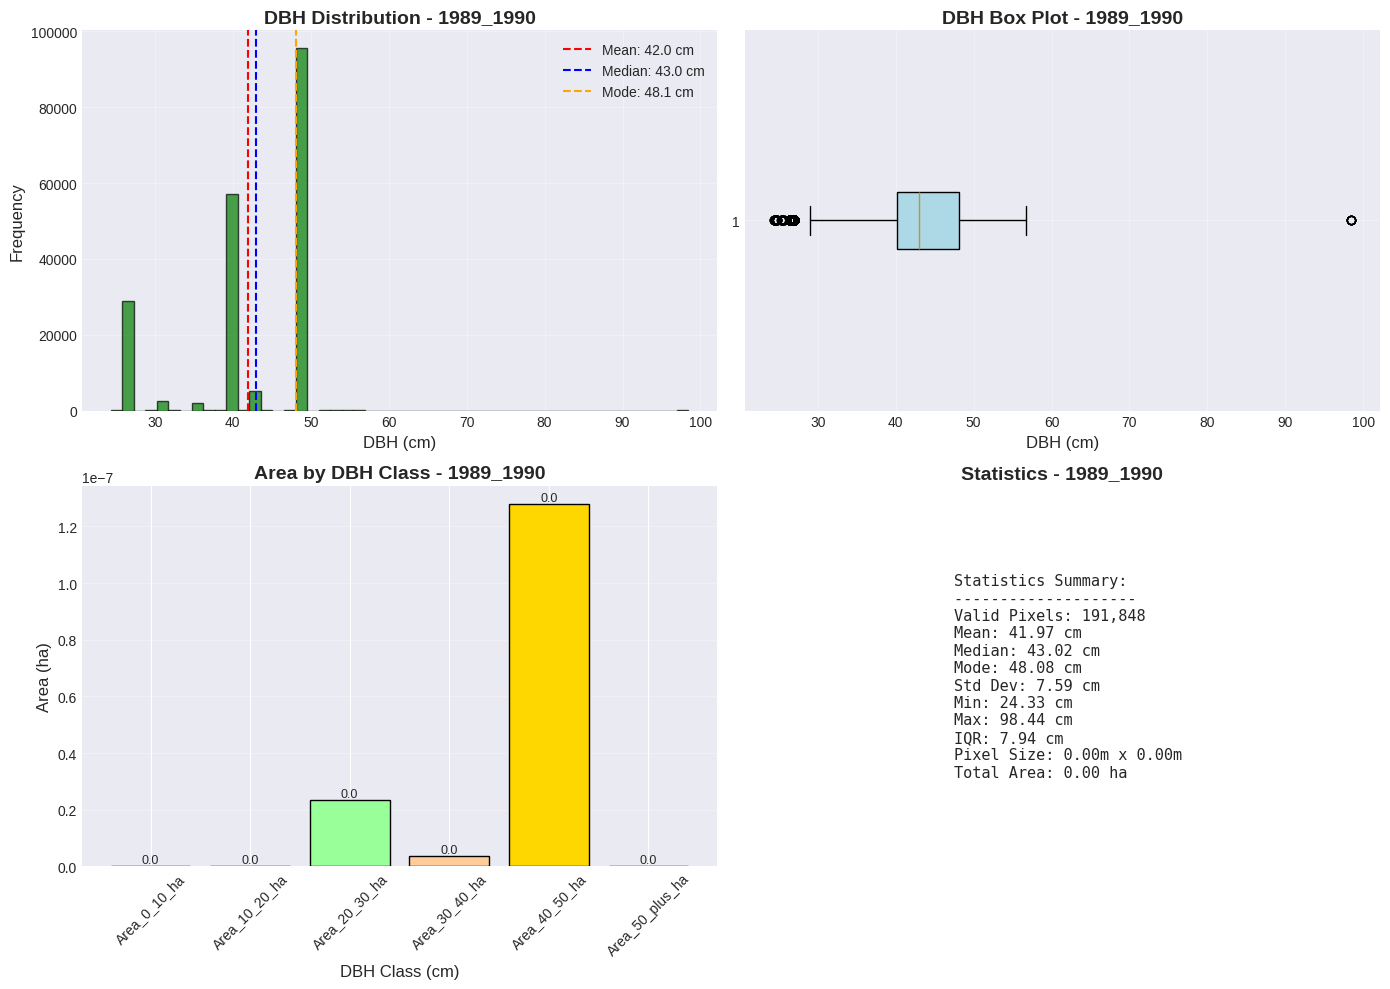


Analyzing: 1994_1995
DEBUG: Pixel width: 8.990604609868534e-05m, height: 8.990604609868534e-05m
DEBUG: Pixel area: 0.0000 m²
DEBUG: Valid pixels: 191848
DEBUG: Total area: 0.00 ha
📊 Summary for 1994_1995:
   Valid pixels: 191,848 (43.0%)
   Mean DBH: 37.83 cm
   Median DBH: 40.16 cm
   Std Dev: 9.26 cm
   Mode: 48.08 cm (count: 27,872)
   Min-Max: 24.33 - 57.05 cm
   Pixel size: 0.00m x 0.00m
   Pixel area: 0.00 m²
   Total Area: 0.00 ha


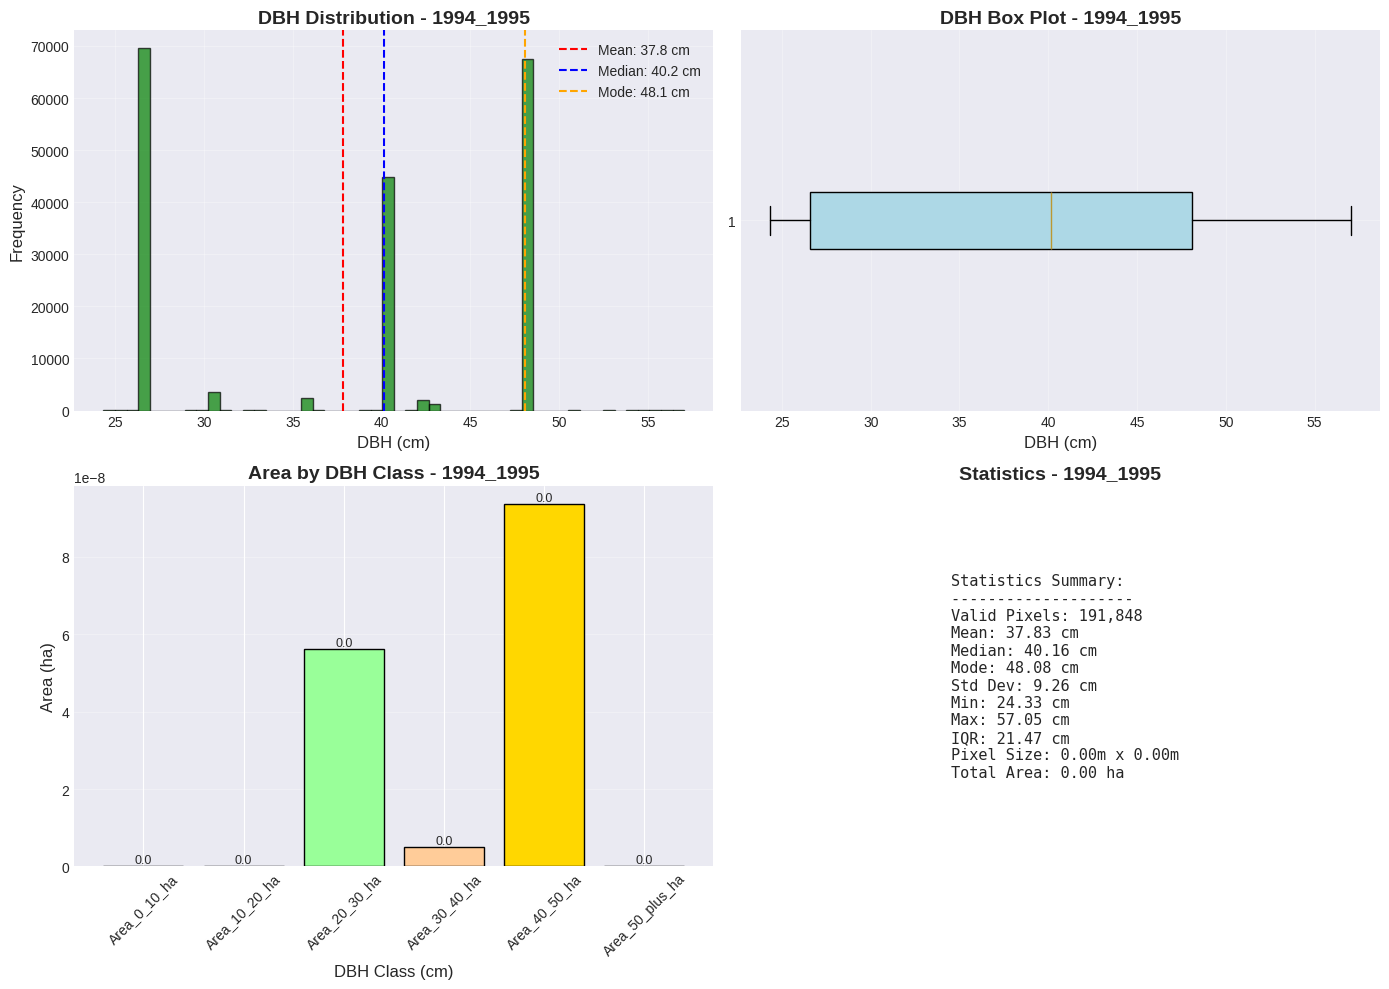


Analyzing: 1999_2000
DEBUG: Pixel width: 8.990604609868534e-05m, height: 8.990604609868534e-05m
DEBUG: Pixel area: 0.0000 m²
DEBUG: Valid pixels: 186734
DEBUG: Total area: 0.00 ha
📊 Summary for 1999_2000:
   Valid pixels: 186,734 (41.8%)
   Mean DBH: 37.08 cm
   Median DBH: 40.16 cm
   Std Dev: 9.37 cm
   Mode: 26.57 cm (count: 34,892)
   Min-Max: 24.33 - 57.88 cm
   Pixel size: 0.00m x 0.00m
   Pixel area: 0.00 m²
   Total Area: 0.00 ha


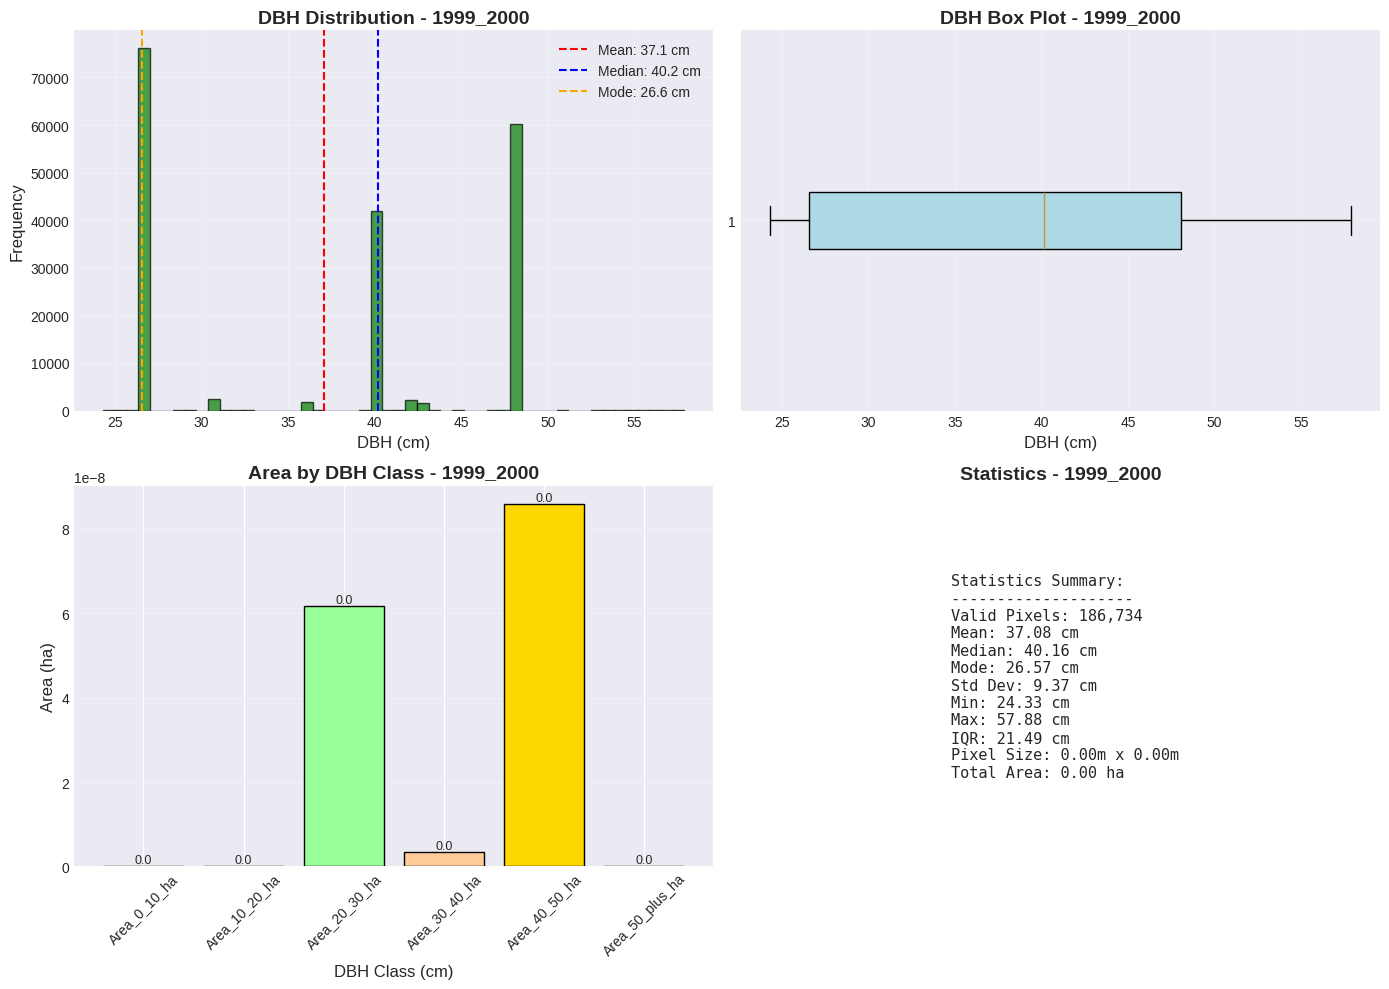


Analyzing: 2004_2005
DEBUG: Pixel width: 8.990604609868534e-05m, height: 8.990604609868534e-05m
DEBUG: Pixel area: 0.0000 m²
DEBUG: Valid pixels: 191821
DEBUG: Total area: 0.00 ha
📊 Summary for 2004_2005:
   Valid pixels: 191,821 (43.0%)
   Mean DBH: 40.73 cm
   Median DBH: 40.17 cm
   Std Dev: 8.17 cm
   Mode: 40.16 cm (count: 47,849)
   Min-Max: 24.33 - 58.16 cm
   Pixel size: 0.00m x 0.00m
   Pixel area: 0.00 m²
   Total Area: 0.00 ha


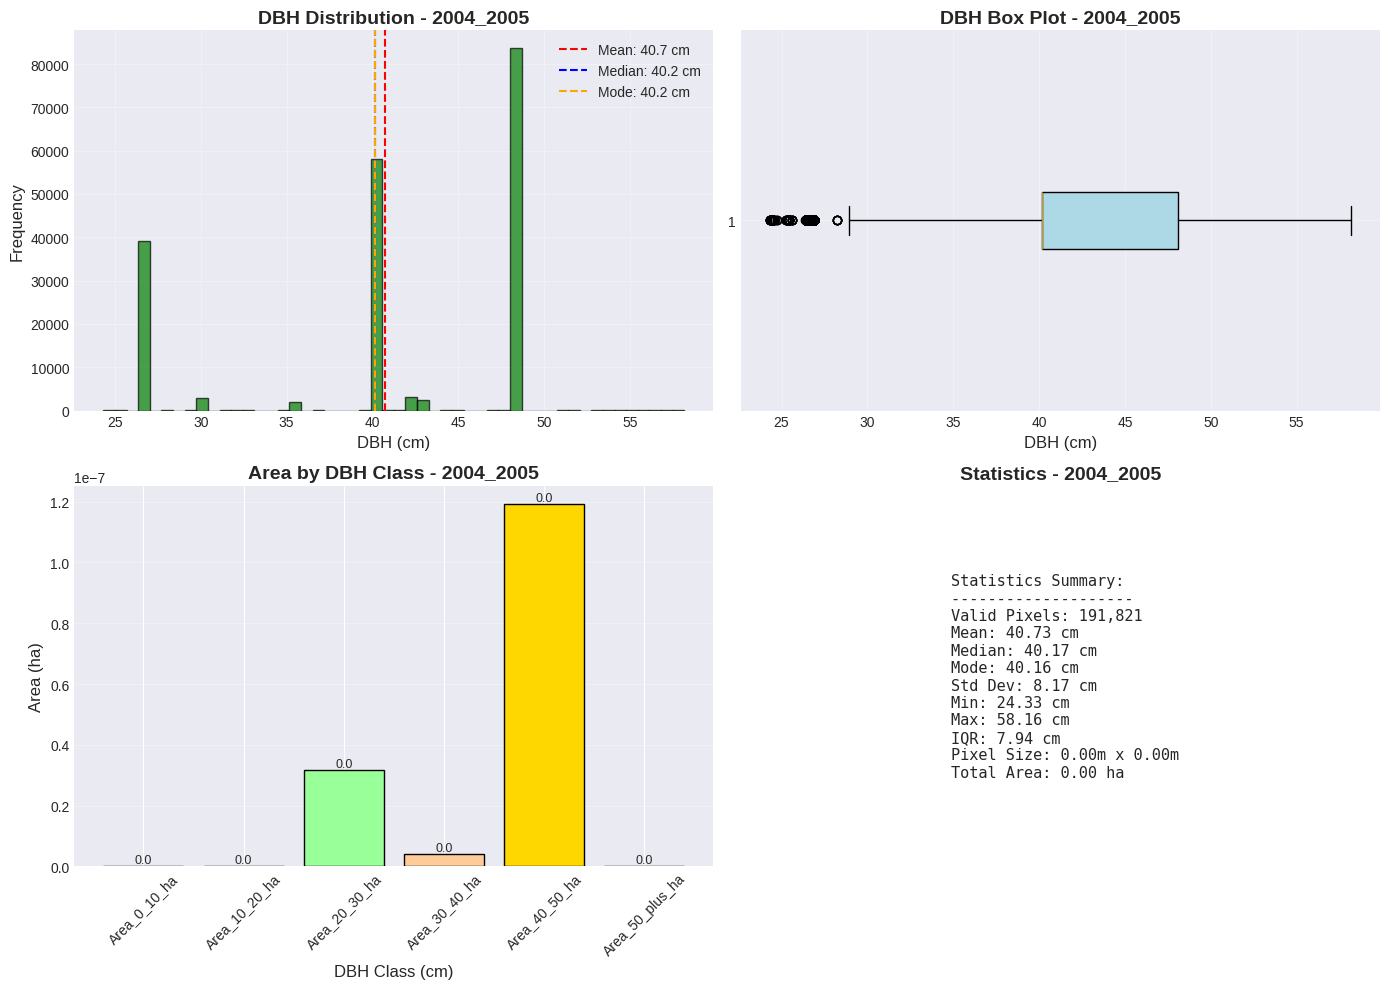


Analyzing: 2009_2010
DEBUG: Pixel width: 8.990604609868534e-05m, height: 8.990604609868534e-05m
DEBUG: Pixel area: 0.0000 m²
DEBUG: Valid pixels: 191848
DEBUG: Total area: 0.00 ha
📊 Summary for 2009_2010:
   Valid pixels: 191,848 (43.0%)
   Mean DBH: 37.43 cm
   Median DBH: 40.16 cm
   Std Dev: 8.87 cm
   Mode: 40.16 cm (count: 34,303)
   Min-Max: 24.33 - 56.23 cm
   Pixel size: 0.00m x 0.00m
   Pixel area: 0.00 m²
   Total Area: 0.00 ha


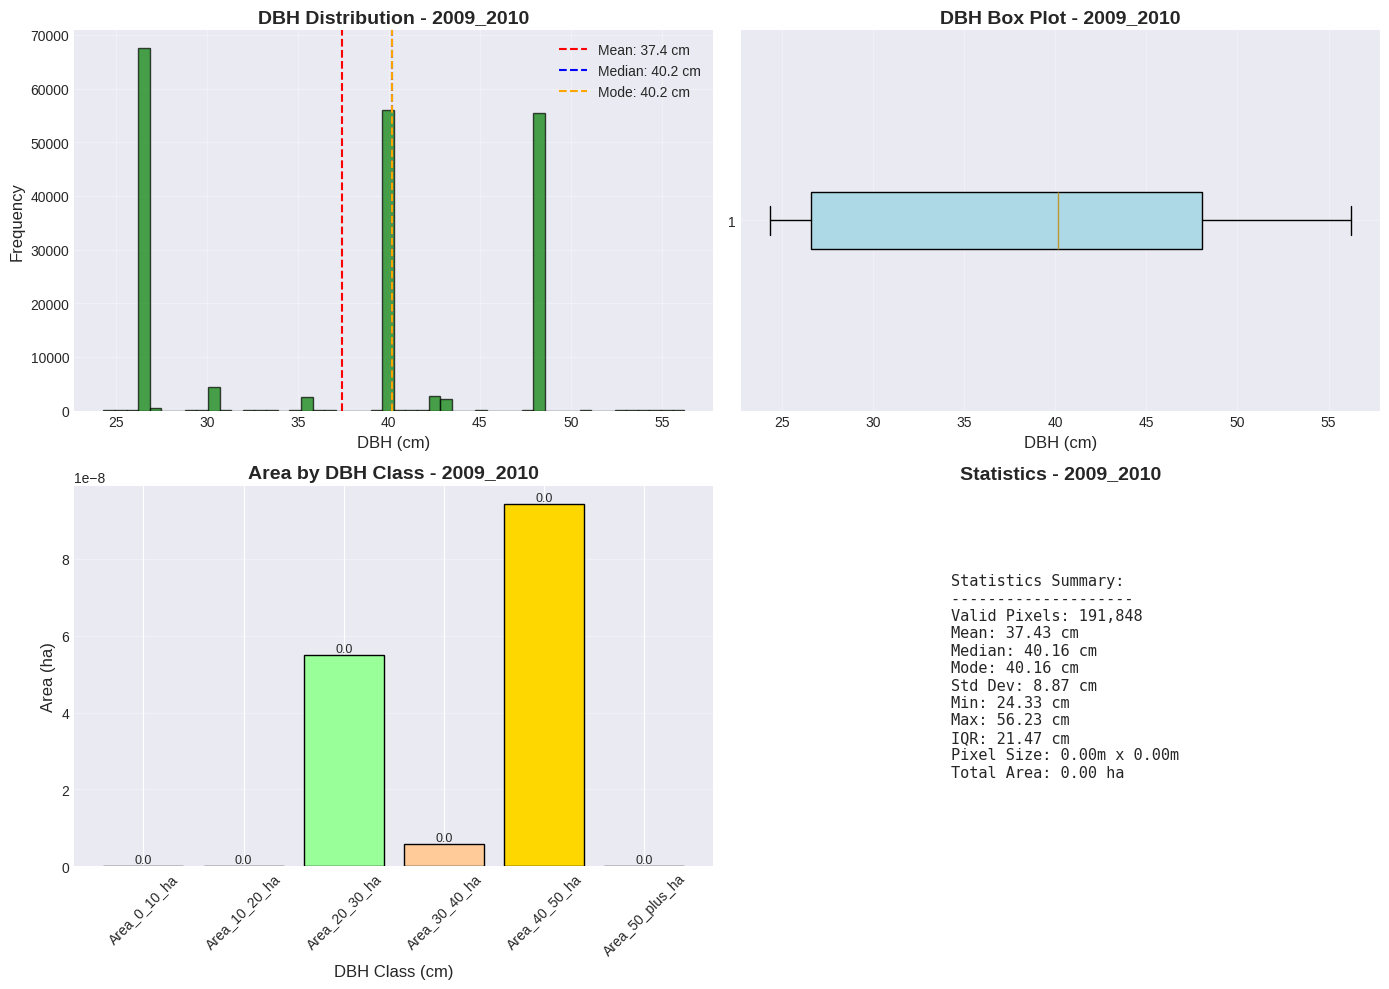


Analyzing: 2014_2015
DEBUG: Pixel width: 8.990604609868534e-05m, height: 8.990604609868534e-05m
DEBUG: Pixel area: 0.0000 m²
DEBUG: Valid pixels: 191848
DEBUG: Total area: 0.00 ha
📊 Summary for 2014_2015:
   Valid pixels: 191,848 (43.0%)
   Mean DBH: 31.36 cm
   Median DBH: 26.60 cm
   Std Dev: 6.61 cm
   Mode: 40.16 cm (count: 56,048)
   Min-Max: 24.33 - 57.05 cm
   Pixel size: 0.00m x 0.00m
   Pixel area: 0.00 m²
   Total Area: 0.00 ha


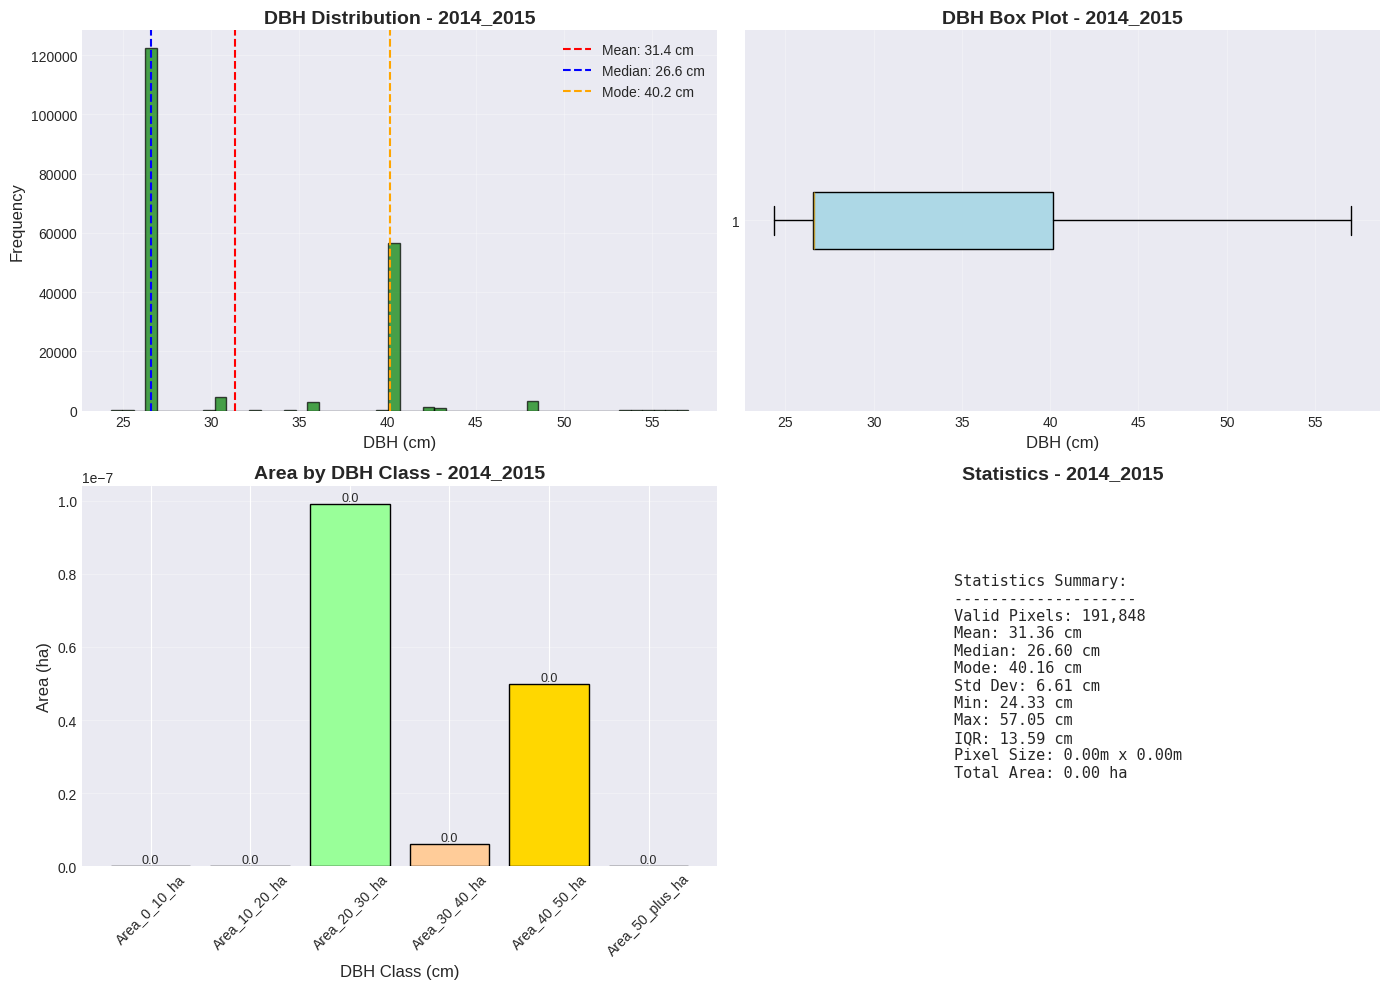


Analyzing: 2019_2020
DEBUG: Pixel width: 8.990604609868534e-05m, height: 8.990604609868534e-05m
DEBUG: Pixel area: 0.0000 m²
DEBUG: Valid pixels: 191848
DEBUG: Total area: 0.00 ha
📊 Summary for 2019_2020:
   Valid pixels: 191,848 (43.0%)
   Mean DBH: 41.30 cm
   Median DBH: 40.16 cm
   Std Dev: 6.66 cm
   Mode: 40.16 cm (count: 80,626)
   Min-Max: 24.33 - 58.21 cm
   Pixel size: 0.00m x 0.00m
   Pixel area: 0.00 m²
   Total Area: 0.00 ha


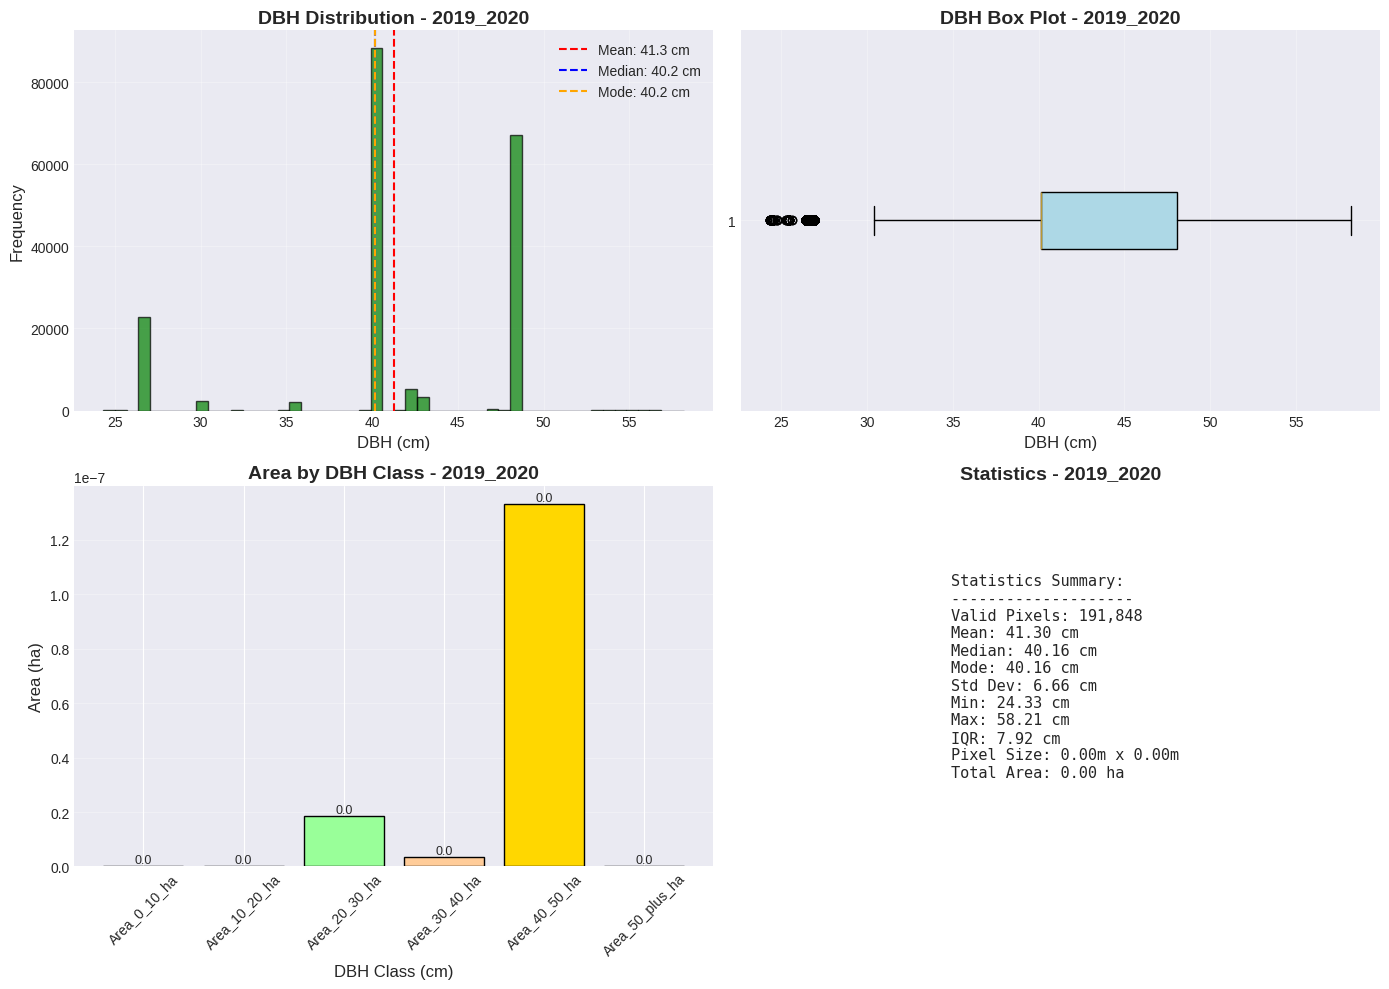


Analyzing: 2024_2025
DEBUG: Pixel width: 8.990604609868534e-05m, height: 8.990604609868534e-05m
DEBUG: Pixel area: 0.0000 m²
DEBUG: Valid pixels: 191848
DEBUG: Total area: 0.00 ha
📊 Summary for 2024_2025:
   Valid pixels: 191,848 (43.0%)
   Mean DBH: 37.11 cm
   Median DBH: 40.16 cm
   Std Dev: 7.71 cm
   Mode: 40.16 cm (count: 82,153)
   Min-Max: 24.33 - 56.98 cm
   Pixel size: 0.00m x 0.00m
   Pixel area: 0.00 m²
   Total Area: 0.00 ha


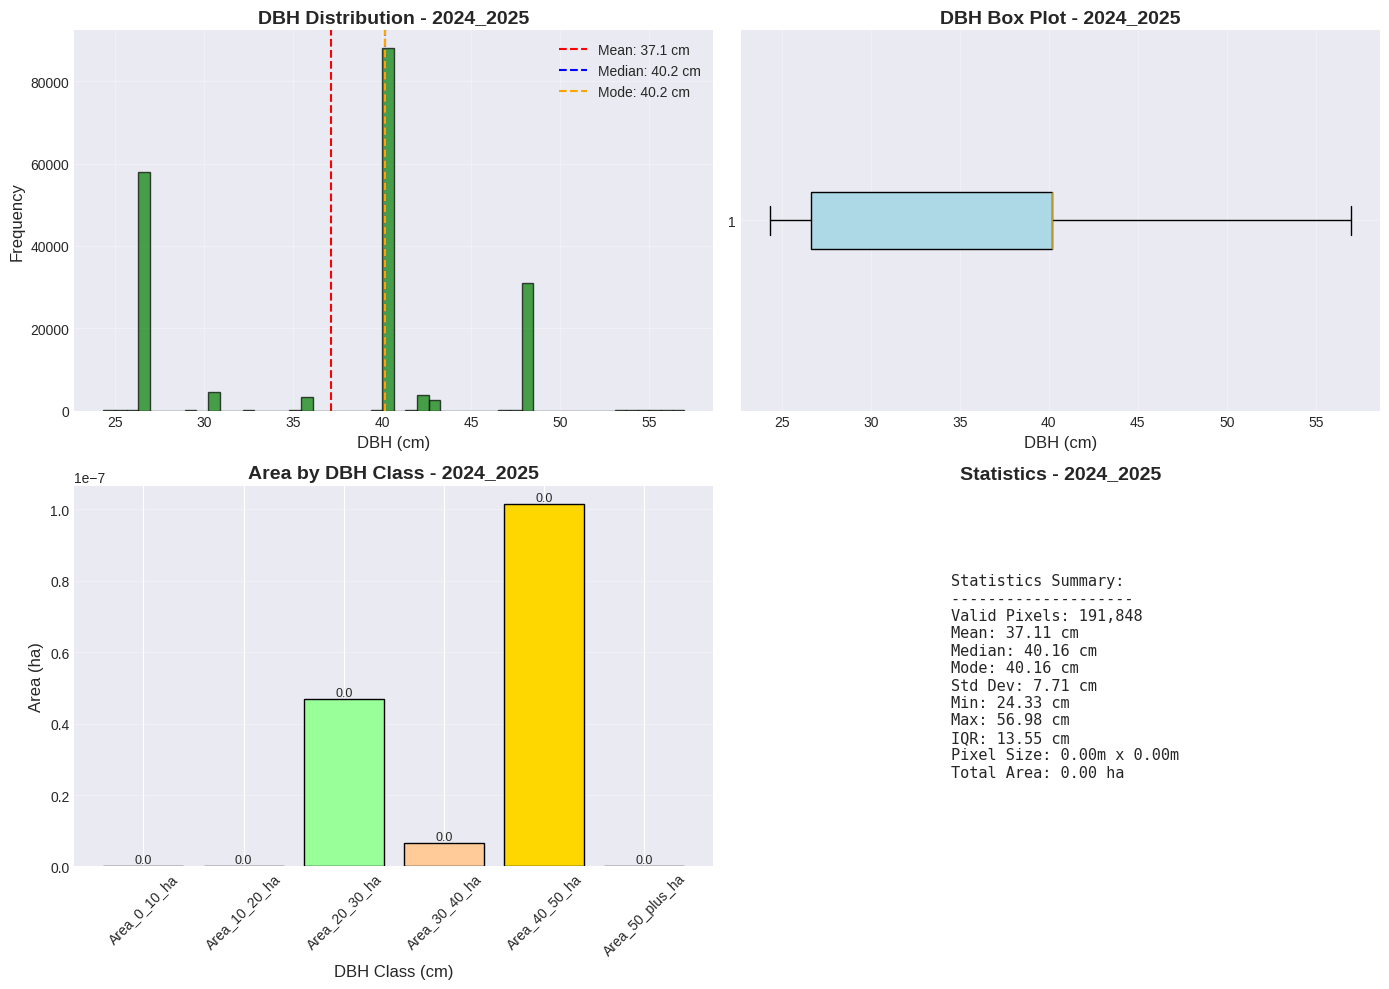


📊 COMPREHENSIVE STATISTICS SUMMARY

Summary Statistics Table:
----------------------------------------------------------------------------------------------------
     Year  Valid_Pixels  Mean_DBH_cm  Mean_DBH_cm  Median_DBH_cm  Mode_DBH_cm  Std_Dev_cm  Pixel_Width_m  Total_Area_ha
1989_1990        191848        41.97        41.97          43.02        48.08        7.59           0.00           0.00
1994_1995        191848        37.83        37.83          40.16        48.08        9.26           0.00           0.00
1999_2000        186734        37.08        37.08          40.16        26.57        9.37           0.00           0.00
2004_2005        191821        40.73        40.73          40.17        40.16        8.17           0.00           0.00
2009_2010        191848        37.43        37.43          40.16        40.16        8.87           0.00           0.00
2014_2015        191848        31.36        31.36          26.60        40.16        6.61           0.00           0

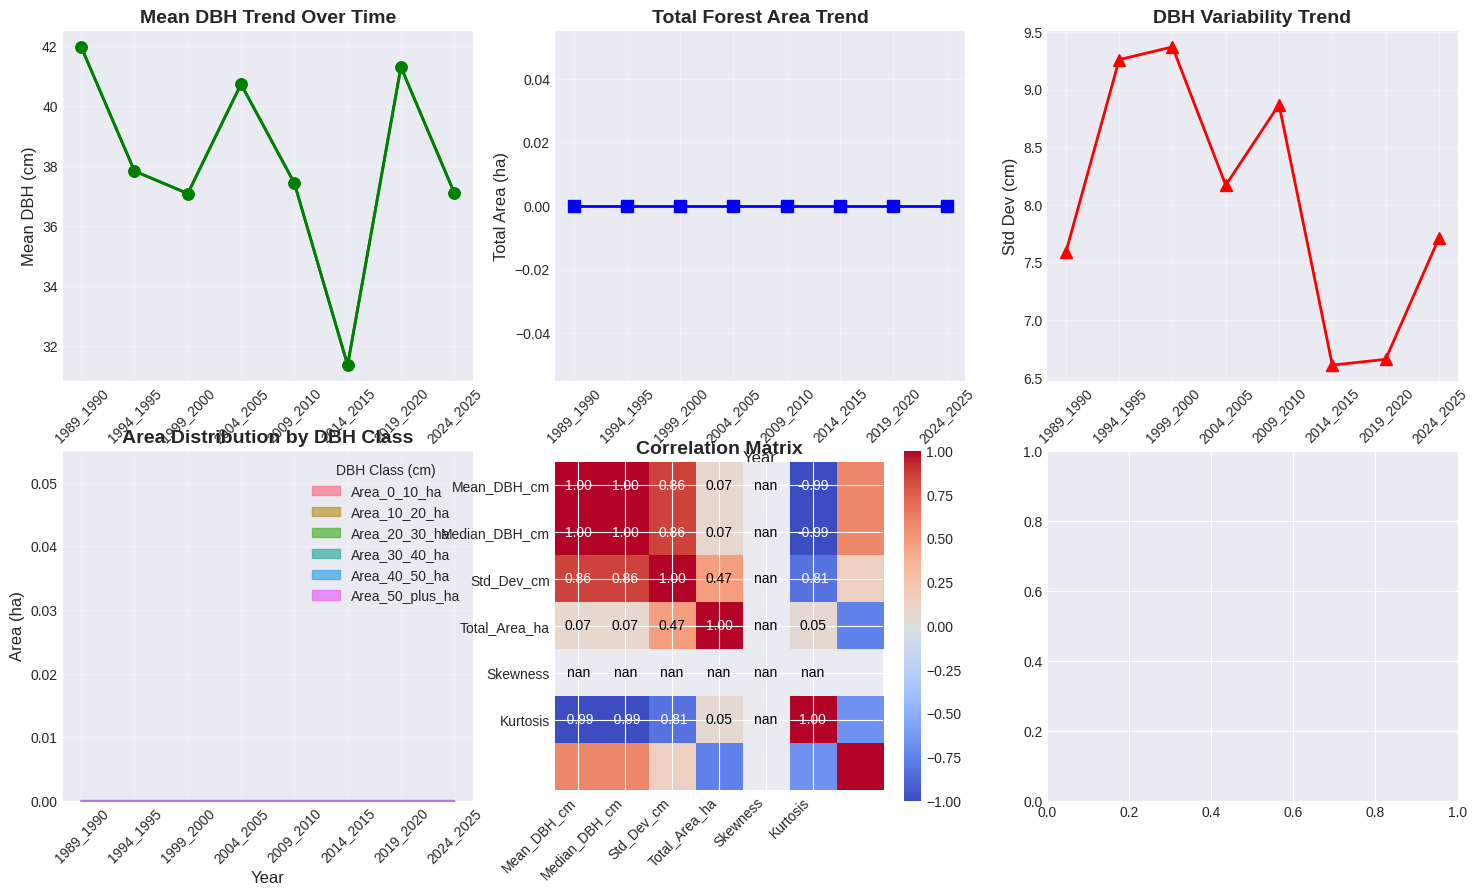

In [73]:
import numpy as np
import rasterio
import pandas as pd
import os
import glob
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the directory containing DBH rasters
raster_dir = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled"

# Get all DBH raster files
dbh_rasters = glob.glob(os.path.join(raster_dir, "DBH_*.tif"))
print(f"Found {len(dbh_rasters)} DBH raster files")

# Create an empty list to store statistics
all_stats = []

# Process each raster
for raster_path in sorted(dbh_rasters):
    try:
        # Extract year from filename
        filename = os.path.basename(raster_path)
        # Extract period (e.g., "2024_2025" from "DBH_2024_2025.tif")
        period = filename.replace("DBH_", "").replace(".tif", "")

        print(f"\n{'='*60}")
        print(f"Analyzing: {period}")
        print(f"{'='*60}")

        # Open the raster
        with rasterio.open(raster_path) as src:
            # Read the data
            data = src.read(1)

            # Get metadata
            rows, cols = data.shape
            total_pixels = rows * cols

            # Create mask for valid (non-NaN) data
            valid_mask = ~np.isnan(data)
            valid_data = data[valid_mask]

            # Calculate basic statistics
            pixel_count = np.sum(valid_mask)
            valid_percentage = (pixel_count / total_pixels) * 100

            if len(valid_data) > 0:
                # Basic statistics
                min_val = np.min(valid_data)
                max_val = np.max(valid_data)
                mean_val = np.mean(valid_data)
                median_val = np.median(valid_data)
                std_dev = np.std(valid_data)

                # Calculate mode using scipy
                try:
                    mode_result = stats.mode(valid_data, keepdims=True)
                    mode_val = mode_result.mode[0]
                    mode_count = mode_result.count[0]
                except:
                    # If mode calculation fails, use histogram-based mode
                    hist, bin_edges = np.histogram(valid_data, bins=50)
                    mode_idx = np.argmax(hist)
                    mode_val = (bin_edges[mode_idx] + bin_edges[mode_idx + 1]) / 2
                    mode_count = hist[mode_idx]

                # Calculate percentiles
                p25 = np.percentile(valid_data, 25)
                p75 = np.percentile(valid_data, 75)
                iqr = p75 - p25

                # Calculate skewness and kurtosis
                skewness = stats.skew(valid_data)
                kurtosis = stats.kurtosis(valid_data)

                # CORRECTED: Calculate area in hectares with proper transform handling
                transform = src.transform
                # Get pixel width and height in the CRS units (usually meters)
                pixel_width = abs(transform[0])  # x resolution (width)
                pixel_height = abs(transform[4])  # y resolution (height) - take absolute value
                pixel_area_m2 = pixel_width * pixel_height

                # Calculate total area in hectares
                total_area_ha = (pixel_count * pixel_area_m2) / 10000

                print(f"DEBUG: Pixel width: {pixel_width}m, height: {pixel_height}m")
                print(f"DEBUG: Pixel area: {pixel_area_m2:.4f} m²")
                print(f"DEBUG: Valid pixels: {pixel_count}")
                print(f"DEBUG: Total area: {total_area_ha:.2f} ha")

                # Calculate area by DBH classes (cm)
                dbh_classes = {
                    'Area_0_10_ha': ((valid_data >= 0) & (valid_data < 10)).sum() * pixel_area_m2 / 10000,
                    'Area_10_20_ha': ((valid_data >= 10) & (valid_data < 20)).sum() * pixel_area_m2 / 10000,
                    'Area_20_30_ha': ((valid_data >= 20) & (valid_data < 30)).sum() * pixel_area_m2 / 10000,
                    'Area_30_40_ha': ((valid_data >= 30) & (valid_data < 40)).sum() * pixel_area_m2 / 10000,
                    'Area_40_50_ha': ((valid_data >= 40) & (valid_data < 50)).sum() * pixel_area_m2 / 10000,
                    'Area_50_plus_ha': (valid_data >= 50).sum() * pixel_area_m2 / 10000,
                }

                # Calculate mean DBH by area class
                mean_by_class = {}
                for class_name, class_range in [
                    ('Mean_0_10', (0, 10)),
                    ('Mean_10_20', (10, 20)),
                    ('Mean_20_30', (20, 30)),
                    ('Mean_30_40', (30, 40)),
                    ('Mean_40_50', (40, 50)),
                    ('Mean_50_plus', (50, np.inf))
                ]:
                    mask = (valid_data >= class_range[0]) & (valid_data < class_range[1])
                    if mask.any():
                        mean_by_class[class_name] = np.mean(valid_data[mask])
                    else:
                        mean_by_class[class_name] = np.nan

                # Create statistics dictionary
                stats_dict = {
                    'Year': period,
                    'Raster_File': filename,
                    'Total_Pixels': total_pixels,
                    'Valid_Pixels': int(pixel_count),
                    'Valid_Percentage': round(valid_percentage, 2),
                    'Missing_Pixels': int(total_pixels - pixel_count),
                    'Min_DBH_cm': round(min_val, 2),
                    'Max_DBH_cm': round(max_val, 2),
                    'Mean_DBH_cm': round(mean_val, 2),
                    'Median_DBH_cm': round(median_val, 2),
                    'Mode_DBH_cm': round(mode_val, 2),
                    'Mode_Count': int(mode_count),
                    'Std_Dev_cm': round(std_dev, 2),
                    'P25_cm': round(p25, 2),
                    'P75_cm': round(p75, 2),
                    'IQR_cm': round(iqr, 2),
                    'Skewness': round(skewness, 3),
                    'Kurtosis': round(kurtosis, 3),
                    'Pixel_Width_m': round(pixel_width, 4),
                    'Pixel_Height_m': round(pixel_height, 4),
                    'Pixel_Area_m2': round(pixel_area_m2, 4),
                    'Total_Area_ha': round(total_area_ha, 2),
                }

                # Add area by class
                stats_dict.update({k: round(v, 2) for k, v in dbh_classes.items()})

                # Add mean by class
                stats_dict.update({k: round(v, 2) if not np.isnan(v) else np.nan for k, v in mean_by_class.items()})

                # Calculate summary metrics
                stats_dict['CV_Percent'] = round((std_dev / mean_val) * 100, 2) if mean_val > 0 else np.nan
                stats_dict['Range_cm'] = round(max_val - min_val, 2)

                # Add to list
                all_stats.append(stats_dict)

                # Print summary
                print(f"📊 Summary for {period}:")
                print(f"   Valid pixels: {int(pixel_count):,} ({valid_percentage:.1f}%)")
                print(f"   Mean DBH: {mean_val:.2f} cm")
                print(f"   Median DBH: {median_val:.2f} cm")
                print(f"   Std Dev: {std_dev:.2f} cm")
                print(f"   Mode: {mode_val:.2f} cm (count: {mode_count:,})")
                print(f"   Min-Max: {min_val:.2f} - {max_val:.2f} cm")
                print(f"   Pixel size: {pixel_width:.2f}m x {pixel_height:.2f}m")
                print(f"   Pixel area: {pixel_area_m2:.2f} m²")
                print(f"   Total Area: {total_area_ha:.2f} ha")

                # Create visualization
                fig, axes = plt.subplots(2, 2, figsize=(14, 10))

                # 1. Histogram
                axes[0, 0].hist(valid_data, bins=50, color='green', alpha=0.7, edgecolor='black')
                axes[0, 0].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f} cm')
                axes[0, 0].axvline(median_val, color='blue', linestyle='--', label=f'Median: {median_val:.1f} cm')
                axes[0, 0].axvline(mode_val, color='orange', linestyle='--', label=f'Mode: {mode_val:.1f} cm')
                axes[0, 0].set_xlabel('DBH (cm)', fontsize=12)
                axes[0, 0].set_ylabel('Frequency', fontsize=12)
                axes[0, 0].set_title(f'DBH Distribution - {period}', fontsize=14, fontweight='bold')
                axes[0, 0].legend()
                axes[0, 0].grid(True, alpha=0.3)

                # 2. Box plot
                axes[0, 1].boxplot(valid_data, vert=False, patch_artist=True,
                                   boxprops=dict(facecolor='lightblue'))
                axes[0, 1].set_xlabel('DBH (cm)', fontsize=12)
                axes[0, 1].set_title(f'DBH Box Plot - {period}', fontsize=14, fontweight='bold')
                axes[0, 1].grid(True, alpha=0.3)

                # 3. Area by DBH class (bar chart)
                dbh_class_names = list(dbh_classes.keys())
                dbh_class_areas = list(dbh_classes.values())
                colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700', '#DA70D6']

                axes[1, 0].bar(dbh_class_names, dbh_class_areas, color=colors, edgecolor='black')
                axes[1, 0].set_xlabel('DBH Class (cm)', fontsize=12)
                axes[1, 0].set_ylabel('Area (ha)', fontsize=12)
                axes[1, 0].set_title(f'Area by DBH Class - {period}', fontsize=14, fontweight='bold')
                axes[1, 0].tick_params(axis='x', rotation=45)
                axes[1, 0].grid(True, alpha=0.3, axis='y')

                # Add value labels on bars
                for i, v in enumerate(dbh_class_areas):
                    axes[1, 0].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

                # 4. Statistics summary table
                stats_text = f"""
                Statistics Summary:
                --------------------
                Valid Pixels: {int(pixel_count):,}
                Mean: {mean_val:.2f} cm
                Median: {median_val:.2f} cm
                Mode: {mode_val:.2f} cm
                Std Dev: {std_dev:.2f} cm
                Min: {min_val:.2f} cm
                Max: {max_val:.2f} cm
                IQR: {iqr:.2f} cm
                Pixel Size: {pixel_width:.2f}m x {pixel_height:.2f}m
                Total Area: {total_area_ha:.2f} ha
                """

                axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                               verticalalignment='center', transform=axes[1, 1].transAxes)
                axes[1, 1].set_title(f'Statistics - {period}', fontsize=14, fontweight='bold')
                axes[1, 1].axis('off')

                plt.tight_layout()
                plt.show()

            else:
                print(f"⚠️ Warning: No valid data in {period}")
                # Get pixel size even for empty data
                transform = src.transform
                pixel_width = abs(transform[0])
                pixel_height = abs(transform[4])
                pixel_area_m2 = pixel_width * pixel_height

                # Create empty stats dict for missing data
                stats_dict = {
                    'Year': period,
                    'Raster_File': filename,
                    'Total_Pixels': total_pixels,
                    'Valid_Pixels': 0,
                    'Valid_Percentage': 0,
                    'Missing_Pixels': total_pixels,
                    'Min_DBH_cm': np.nan,
                    'Max_DBH_cm': np.nan,
                    'Mean_DBH_cm': np.nan,
                    'Median_DBH_cm': np.nan,
                    'Mode_DBH_cm': np.nan,
                    'Mode_Count': 0,
                    'Std_Dev_cm': np.nan,
                    'P25_cm': np.nan,
                    'P75_cm': np.nan,
                    'IQR_cm': np.nan,
                    'Skewness': np.nan,
                    'Kurtosis': np.nan,
                    'Pixel_Width_m': round(pixel_width, 4),
                    'Pixel_Height_m': round(pixel_height, 4),
                    'Pixel_Area_m2': round(pixel_area_m2, 4),
                    'Total_Area_ha': 0,
                }
                all_stats.append(stats_dict)

    except Exception as e:
        print(f"❌ Error processing {raster_path}: {e}")
        # Create error entry
        all_stats.append({
            'Year': period if 'period' in locals() else 'Unknown',
            'Raster_File': filename if 'filename' in locals() else 'Unknown',
            'Error': str(e)
        })

# Create DataFrame from all statistics
if all_stats:
    df_stats = pd.DataFrame(all_stats)

    # Reorder columns for better readability
    column_order = [
        'Year', 'Raster_File', 'Total_Pixels', 'Valid_Pixels', 'Valid_Percentage',
        'Missing_Pixels', 'Min_DBH_cm', 'Max_DBH_cm', 'Mean_DBH_cm', 'Median_DBH_cm',
        'Mode_DBH_cm', 'Mode_Count', 'Std_Dev_cm', 'P25_cm', 'P75_cm', 'IQR_cm',
        'Range_cm', 'CV_Percent', 'Skewness', 'Kurtosis', 'Pixel_Width_m',
        'Pixel_Height_m', 'Pixel_Area_m2', 'Total_Area_ha'
    ]

    # Add area class columns if they exist
    area_class_cols = [col for col in df_stats.columns if col.startswith('Area_')]
    mean_class_cols = [col for col in df_stats.columns if col.startswith('Mean_')]

    # Reconstruct column order
    final_column_order = column_order + area_class_cols + mean_class_cols

    # Keep only columns that exist in DataFrame
    final_column_order = [col for col in final_column_order if col in df_stats.columns]

    # Reorder DataFrame
    df_stats = df_stats[final_column_order]

    # Sort by Year
    df_stats = df_stats.sort_values('Year')

    # Save to CSV
    csv_path = os.path.join(raster_dir, "DBH_Statistics_Summary.csv")
    df_stats.to_csv(csv_path, index=False)

    print(f"\n{'='*60}")
    print("📊 COMPREHENSIVE STATISTICS SUMMARY")
    print(f"{'='*60}")

    # Display summary table
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', '{:.2f}'.format)

    print("\nSummary Statistics Table:")
    print("-" * 100)

    # Display key statistics
    display_cols = ['Year', 'Valid_Pixels', 'Mean_DBH_cm', 'Median_DBH_cm',
                   'Mode_DBH_cm', 'Std_Dev_cm', 'Pixel_Width_m', 'Total_Area_ha']
    display_cols = [col for col in display_cols if col in df_stats.columns]

    print(df_stats[display_cols].to_string(index=False))

    print(f"\n✅ Detailed statistics saved to: {csv_path}")

    # Create temporal trend visualization
    if 'Mean_DBH_cm' in df_stats.columns and 'Year' in df_stats.columns:
        try:
            # Extract numeric year for sorting (take first year of period)
            df_stats['Year_Num'] = df_stats['Year'].str.split('_').str[0].astype(int)
            df_stats = df_stats.sort_values('Year_Num')

            fig, axes = plt.subplots(2, 3, figsize=(18, 10))

            # 1. Mean DBH trend
            axes[0, 0].plot(df_stats['Year'], df_stats['Mean_DBH_cm'], marker='o',
                           linewidth=2, markersize=8, color='green')
            axes[0, 0].set_xlabel('Year', fontsize=12)
            axes[0, 0].set_ylabel('Mean DBH (cm)', fontsize=12)
            axes[0, 0].set_title('Mean DBH Trend Over Time', fontsize=14, fontweight='bold')
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].tick_params(axis='x', rotation=45)

            # 2. Total Area trend
            axes[0, 1].plot(df_stats['Year'], df_stats['Total_Area_ha'], marker='s',
                           linewidth=2, markersize=8, color='blue')
            axes[0, 1].set_xlabel('Year', fontsize=12)
            axes[0, 1].set_ylabel('Total Area (ha)', fontsize=12)
            axes[0, 1].set_title('Total Forest Area Trend', fontsize=14, fontweight='bold')
            axes[0, 1].grid(True, alpha=0.3)
            axes[0, 1].tick_params(axis='x', rotation=45)

            # 3. Std Dev trend
            axes[0, 2].plot(df_stats['Year'], df_stats['Std_Dev_cm'], marker='^',
                           linewidth=2, markersize=8, color='red')
            axes[0, 2].set_xlabel('Year', fontsize=12)
            axes[0, 2].set_ylabel('Std Dev (cm)', fontsize=12)
            axes[0, 2].set_title('DBH Variability Trend', fontsize=14, fontweight='bold')
            axes[0, 2].grid(True, alpha=0.3)
            axes[0, 2].tick_params(axis='x', rotation=45)

            # 4. Area by DBH class (stacked area chart)
            if area_class_cols:
                area_data = df_stats[['Year'] + area_class_cols].set_index('Year')
                area_data.plot(kind='area', ax=axes[1, 0], alpha=0.7, stacked=True)
                axes[1, 0].set_xlabel('Year', fontsize=12)
                axes[1, 0].set_ylabel('Area (ha)', fontsize=12)
                axes[1, 0].set_title('Area Distribution by DBH Class', fontsize=14, fontweight='bold')
                axes[1, 0].legend(title='DBH Class (cm)')
                axes[1, 0].grid(True, alpha=0.3)
                axes[1, 0].tick_params(axis='x', rotation=45)

            # 5. Correlation heatmap of key metrics
            corr_cols = ['Mean_DBH_cm', 'Median_DBH_cm', 'Std_Dev_cm', 'Total_Area_ha',
                        'Skewness', 'Kurtosis']
            corr_cols = [col for col in corr_cols if col in df_stats.columns]

            if len(corr_cols) > 1:
                corr_matrix = df_stats[corr_cols].corr()
                im = axes[1, 1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
                axes[1, 1].set_xticks(range(len(corr_cols)))
                axes[1, 1].set_yticks(range(len(corr_cols)))
                axes[1, 1].set_xticklabels(corr_cols, rotation=45, ha='right')
                axes[1, 1].set_yticklabels(corr_cols)
                axes[1, 1].set_title('Correlation Matrix', fontsize=14, fontweight='bold')

                # Add correlation values
                for i in range(len(corr_cols)):
                    for j in range(len(corr_cols)):
                        text = axes[1, 1].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                                             ha='center', va='center', color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

                plt.colorbar(im, ax=axes[1, 1])

            # 6. Summary statistics table
            summary_text = f"""
            Dataset Summary:
            ----------------
            Total Rasters: {len(df_stats)}
            Time Period: {df_stats['Year'].min()} to {df_stats['Year'].max()}
            Average Mean DBH: {df_stats['Mean_DBH_cm'].mean():.2f} cm
            Average Area: {df_stats['Total_Area_ha'].mean():.2f} ha
            Total Valid Pixels: {df_stats['Valid_Pixels'].sum():,}
            """

            axes[1, 2].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
                           verticalalignment='center', transform=axes[1, 2].transAxes)
            axes[1, 2].set_title('Dataset Overview', fontsize=14, fontweight='bold')
            axes[1, 2].axis('off')

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Note: Could not create trend visualization: {e}")

    # Export additional summary files
    # 1. Summary by DBH class
    if area_class_cols:
        dbh_class_summary = df_stats[['Year'] + area_class_cols].set_index('Year')
        dbh_class_csv = os.path.join(raster_dir, "DBH_Class_Area_Summary.csv")
        dbh_class_summary.to_csv(dbh_class_csv)
        print(f"✅ DBH class area summary saved to: {dbh_class_csv}")

    # 2. Basic statistics only
    basic_stats = df_stats[['Year', 'Mean_DBH_cm', 'Median_DBH_cm', 'Std_Dev_cm',
                           'Total_Area_ha', 'Valid_Pixels']]
    basic_stats_csv = os.path.join(raster_dir, "DBH_Basic_Statistics.csv")
    basic_stats.to_csv(basic_stats_csv, index=False)
    print(f"✅ Basic statistics saved to: {basic_stats_csv}")

    # 3. Export to Excel with multiple sheets
    try:
        excel_path = os.path.join(raster_dir, "DBH_Complete_Analysis.xlsx")
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            df_stats.to_excel(writer, sheet_name='Complete_Statistics', index=False)
            if area_class_cols:
                dbh_class_summary.to_excel(writer, sheet_name='DBH_Class_Areas')
            basic_stats.to_excel(writer, sheet_name='Key_Metrics', index=False)

            # Add summary sheet
            summary_df = pd.DataFrame({
                'Metric': ['Total Rasters', 'Time Span', 'Avg Mean DBH', 'Avg Total Area',
                          'Total Valid Pixels'],
                'Value': [len(df_stats),
                         f"{df_stats['Year'].min()} to {df_stats['Year'].max()}",
                         f"{df_stats['Mean_DBH_cm'].mean():.2f} cm",
                         f"{df_stats['Total_Area_ha'].mean():.2f} ha",
                         f"{df_stats['Valid_Pixels'].sum():,}"]
            })
            summary_df.to_excel(writer, sheet_name='Dataset_Summary', index=False)

        print(f"✅ Complete analysis exported to Excel: {excel_path}")
    except Exception as e:
        print(f"Note: Excel export failed: {e}")

else:
    print("❌ No statistics were generated. Check if any rasters were processed successfully.")

In [75]:
import pandas as pd

# Read the CSV file
csv_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_Basic_Statistics.csv"
summary_df = pd.read_csv(csv_path)

# Display basic information about the DataFrame
print(f"DataFrame shape: {summary_df.shape}")
print(f"\nColumns: {list(summary_df.columns)}")
print(f"\nFirst few rows:")
print(summary_df.head())

DataFrame shape: (8, 7)

Columns: ['Year', 'Mean_DBH_cm', 'Mean_DBH_cm.1', 'Median_DBH_cm', 'Std_Dev_cm', 'Total_Area_ha', 'Valid_Pixels']

First few rows:
        Year  Mean_DBH_cm  Mean_DBH_cm.1  Median_DBH_cm  Std_Dev_cm  Total_Area_ha  Valid_Pixels
0  1989_1990        41.97          41.97          43.02        7.59           0.00        191848
1  1994_1995        37.83          37.83          40.16        9.26           0.00        191848
2  1999_2000        37.08          37.08          40.16        9.37           0.00        186734
3  2004_2005        40.73          40.73          40.17        8.17           0.00        191821
4  2009_2010        37.43          37.43          40.16        8.87           0.00        191848


In [76]:
import rasterio

# Path to the directory containing DBH rasters
raster_dir = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled"

# Get first DBH raster file
first_raster_path = raster_dir + "/DBH_2024_2025.tif"

# Open the raster and print information
with rasterio.open(first_raster_path) as src:
    print(src)

<open DatasetReader name='/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_2024_2025.tif' mode='r'>


In [89]:
import rasterio

# Open the raster file
with rasterio.open('/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Finalized/Tree_Height_1989_1990_Predicted.tif') as src:
    # Get pixel size from the transform
    pixel_size_x = src.transform[0]
    pixel_size_y = -src.transform[4]  # Negative because y resolution is typically negative

    print(f"Pixel size X: {pixel_size_x}")
    print(f"Pixel size Y: {pixel_size_y}")
    print(f"Pixel area: {abs(pixel_size_x * pixel_size_y)} square units")

Pixel size X: 4.9958655967231955
Pixel size Y: 4.9958655967231955
Pixel area: 24.95867306052241 square units


In [81]:
import os
import glob

# Define the base path
base_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/"

# Find all .tif files in the directory and subdirectories
tif_files = glob.glob(os.path.join(base_path, "**", "*.tif"), recursive=True)

# Print results
print(f"Found {len(tif_files)} .tif file(s):")
print("-" * 50)

for i, file_path in enumerate(tif_files, 1):
    # Get relative path from base_path
    rel_path = os.path.relpath(file_path, base_path)
    file_size = os.path.getsize(file_path)

    print(f"{i}. {rel_path}")
    print(f"   Full path: {file_path}")
    print(f"   Size: {file_size:,} bytes ({file_size/1024/1024:.2f} MB)")

    # Optional: Read basic raster info
    try:
        import rasterio
        with rasterio.open(file_path) as src:
            print(f"   Dimensions: {src.width} x {src.height}")
            print(f"   Bands: {src.count}")
            print(f"   CRS: {src.crs}")
    except ImportError:
        print("   (Install rasterio for more details)")
    except Exception as e:
        print(f"   Error reading raster: {e}")

    print("-" * 50)

Found 16 .tif file(s):
--------------------------------------------------
1. Tree_Height_2024_2025_Predicted.tif
   Full path: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Tree_Height_2024_2025_Predicted.tif
   Size: 3,268,125 bytes (3.12 MB)
   Dimensions: 2089 x 851
   Bands: 1
   CRS: EPSG:4326
--------------------------------------------------
2. Tree_Height_2019_2020_Predicted.tif
   Full path: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Tree_Height_2019_2020_Predicted.tif
   Size: 3,258,557 bytes (3.11 MB)
   Dimensions: 2089 x 851
   Bands: 1
   CRS: EPSG:4326
--------------------------------------------------
3. Tree_Height_2014_2015_Predicted.tif
   Full path: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Tree_Height_2014_2015_Predicted.tif
   Size: 3,219,567 bytes (3.07 MB)
   Dimensions: 2089 x 851
   Bands: 1
   CRS: EPSG:4326
--------------------------------------------------
4. Tree_Height_2009_2010_Predicted.tif
   Full 

In [82]:
import os
import rasterio
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas as gpd

# Define paths
base_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/"
output_dir = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Finalized/"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

# Target CRS (Arc 1960 UTM 36N - EPSG:21096)
target_crs = 'EPSG:21096'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load the mask geometry
print("Loading mask geometry...")
mask_gdf = gpd.read_file(mask_path)
print(f"Mask CRS: {mask_gdf.crs}")

# Get all .tif files
tif_files = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.tif'):
            tif_files.append(os.path.join(root, file))

print(f"Found {len(tif_files)} .tif files to process")
print("-" * 50)

# Process each file
for i, input_path in enumerate(tif_files, 1):
    filename = os.path.basename(input_path)
    output_path = os.path.join(output_dir, filename)

    print(f"Processing {i}/{len(tif_files)}: {filename}")

    try:
        # Open source file
        with rasterio.open(input_path) as src:
            print(f"  Original CRS: {src.crs}")
            print(f"  Original shape: {src.height} x {src.width}")

            # Step 1: Reproject to target CRS
            transform, width, height = calculate_default_transform(
                src.crs, target_crs, src.width, src.height, *src.bounds
            )

            # Update metadata
            kwargs = src.meta.copy()
            kwargs.update({
                'crs': target_crs,
                'transform': transform,
                'width': width,
                'height': height
            })

            # Create temporary reprojected file
            temp_path = output_path.replace('.tif', '_temp.tif')
            with rasterio.open(temp_path, 'w', **kwargs) as dst:
                for band in range(1, src.count + 1):
                    reproject(
                        source=rasterio.band(src, band),
                        destination=rasterio.band(dst, band),
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=transform,
                        dst_crs=target_crs,
                        resampling=Resampling.nearest
                    )

            # Step 2: Reproject mask to match the reprojected raster
            print(f"  Reprojecting mask to {target_crs}...")
            mask_gdf_reprojected = mask_gdf.to_crs(target_crs)
            mask_geometry = [geom for geom in mask_gdf_reprojected.geometry]

            # Step 3: Apply mask to reprojected raster
            with rasterio.open(temp_path) as src_temp:
                print(f"  Applying mask...")
                out_image, out_transform = mask(
                    src_temp,
                    mask_geometry,
                    crop=True,
                    all_touched=True
                )

                # Update metadata for masked output
                kwargs_temp = src_temp.meta.copy()
                kwargs_temp.update({
                    "height": out_image.shape[1],
                    "width": out_image.shape[2],
                    "transform": out_transform,
                    "nodata": src_temp.nodata if src_temp.nodata else -9999
                })

                # Write final output
                with rasterio.open(output_path, 'w', **kwargs_temp) as dst_final:
                    dst_final.write(out_image)

                print(f"  Final shape: {out_image.shape[1]} x {out_image.shape[2]}")

            # Clean up temporary file
            os.remove(temp_path)
            print(f"  ✓ Saved to: {output_path}")

    except Exception as e:
        print(f"  ✗ Error processing {filename}: {str(e)}")

    print("-" * 50)

print("Processing complete!")
print(f"All files saved to: {output_dir}")

Loading mask geometry...
Mask CRS: EPSG:4326
Found 16 .tif files to process
--------------------------------------------------
Processing 1/16: Tree_Height_2024_2025_Predicted.tif
  Original CRS: EPSG:4326
  Original shape: 851 x 2089
  Reprojecting mask to EPSG:21096...
  Applying mask...
  Final shape: 845 x 2091
  ✓ Saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Finalized/Tree_Height_2024_2025_Predicted.tif
--------------------------------------------------
Processing 2/16: Tree_Height_2019_2020_Predicted.tif
  Original CRS: EPSG:4326
  Original shape: 851 x 2089
  Reprojecting mask to EPSG:21096...
  Applying mask...
  Final shape: 845 x 2091
  ✓ Saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Finalized/Tree_Height_2019_2020_Predicted.tif
--------------------------------------------------
Processing 3/16: Tree_Height_2014_2015_Predicted.tif
  Original CRS: EPSG:4326
  Original shape: 851 x 2089
  Reprojecting mask to EPSG:21096...
  

In [91]:
import os
import rasterio
import numpy as np
import pandas as pd
from datetime import datetime

# Define paths
finalized_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Finalized/"

# Pixel dimensions
pixel_size_x = 4.9958655967231955
pixel_size_y = 4.9958655967231955
pixel_area_sq_m = pixel_size_x * pixel_size_y
pixel_area_hectares = pixel_area_sq_m / 10000  # Convert to hectares

print(f"Pixel size X: {pixel_size_x}")
print(f"Pixel size Y: {pixel_size_y}")
print(f"Pixel area: {pixel_area_sq_m:.6f} square meters")
print(f"Pixel area: {pixel_area_hectares:.8f} hectares")
print("-" * 60)

# Get all Tree_Height .tif files
tree_height_files = []
for file in os.listdir(finalized_path):
    if file.startswith('Tree_Height') and file.endswith('.tif'):
        tree_height_files.append(os.path.join(finalized_path, file))

print(f"Found {len(tree_height_files)} Tree_Height .tif files")

# Create a list to store statistics for each file
stats_list = []

# Process each Tree_Height file
for input_path in sorted(tree_height_files):
    filename = os.path.basename(input_path)

    # Extract year from filename (assuming format like "Tree_Height_1990.tif")
    year_part = filename.replace('Tree_Height_', '').replace('.tif', '')

    try:
        with rasterio.open(input_path) as src:
            # Read the data
            data = src.read(1, out_shape=(src.height, src.width))

            # Handle nodata values
            if src.nodata is not None:
                valid_data = data[data != src.nodata]
            else:
                valid_data = data[~np.isnan(data)]

            if len(valid_data) > 0:
                # Calculate statistics
                min_height = np.min(valid_data)
                max_height = np.max(valid_data)
                mean_height = np.mean(valid_data)
                median_height = np.median(valid_data)
                std_height = np.std(valid_data)

                # Calculate area
                valid_pixel_count = len(valid_data)
                total_area_ha = valid_pixel_count * pixel_area_hectares

                # Store statistics
                stats_list.append({
                    'Year': year_part,
                    'Mean_Height_m': mean_height,
                    'Median_Height_m': median_height,
                    'Std_Dev_Height_m': std_height,
                    'Min_Height_m': min_height,
                    'Max_Height_m': max_height,
                    'Total_Area_ha': total_area_ha,
                    'Valid_Pixels_Height': valid_pixel_count
                })

                print(f"Processed {filename}: {valid_pixel_count:,} valid pixels, {total_area_ha:.2f} ha")

            else:
                print(f"Warning: No valid data found in {filename}")

    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")

# Create DataFrame from collected statistics
height_stats_df = pd.DataFrame(stats_list)

# Display the height statistics
print("\nTree Height Statistics:")
print(height_stats_df)
print("-" * 60)

# Now merge with your existing summary_df
# Assuming summary_df already exists with your DBH data
print("Merging with existing summary data...")

# First, let's check if summary_df exists and see its structure
try:
    print("Existing summary_df:")
    print(summary_df.head())
    print(f"Shape: {summary_df.shape}")

    # Merge the dataframes on Year column
    final_summary_df = pd.merge(summary_df, height_stats_df, on='Year', how='left')

    print("\nFinal combined summary:")
    print(final_summary_df)
    print(f"Final shape: {final_summary_df.shape}")

    # Save the complete summary
    output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/complete_forest_summary.csv"
    final_summary_df.to_csv(output_path, index=False)
    print(f"\nComplete summary saved to: {output_path}")

except NameError:
    print("summary_df not found. Creating new summary with height data only.")
    final_summary_df = height_stats_df

    # Save the height summary
    output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/tree_height_summary.csv"
    final_summary_df.to_csv(output_path, index=False)
    print(f"Tree height summary saved to: {output_path}")

# Display final statistics
print("\nFinal Summary Statistics:")
print("-" * 40)
for col in final_summary_df.columns:
    if final_summary_df[col].dtype in [np.float64, np.int64]:
        print(f"{col}:")
        print(f"  Min: {final_summary_df[col].min():.2f}")
        print(f"  Max: {final_summary_df[col].max():.2f}")
        print(f"  Mean: {final_summary_df[col].mean():.2f}")
        print(f"  Std: {final_summary_df[col].std():.2f}")
        print()

Pixel size X: 4.9958655967231955
Pixel size Y: 4.9958655967231955
Pixel area: 24.958673 square meters
Pixel area: 0.00249587 hectares
------------------------------------------------------------
Found 8 Tree_Height .tif files
Processed Tree_Height_1989_1990_Predicted.tif: 1,766,895 valid pixels, 4409.94 ha
Processed Tree_Height_1994_1995_Predicted.tif: 1,766,895 valid pixels, 4409.94 ha
Processed Tree_Height_1999_2000_Predicted.tif: 1,766,895 valid pixels, 4409.94 ha
Processed Tree_Height_2004_2005_Predicted.tif: 49,416 valid pixels, 123.34 ha
Processed Tree_Height_2009_2010_Predicted.tif: 1,766,895 valid pixels, 4409.94 ha
Processed Tree_Height_2014_2015_Predicted.tif: 1,766,895 valid pixels, 4409.94 ha
Processed Tree_Height_2019_2020_Predicted.tif: 1,766,895 valid pixels, 4409.94 ha
Processed Tree_Height_2024_2025_Predicted.tif: 1,766,895 valid pixels, 4409.94 ha

Tree Height Statistics:
                  Year  Mean_Height_m  Median_Height_m  Std_Dev_Height_m  Min_Height_m  Max_Heigh

In [92]:
final_summary_df.head()

,Year,Mean_DBH_cm,Mean_DBH_cm.1,Median_DBH_cm,Std_Dev_cm,Total_Area_ha_x,Valid_Pixels,Mean_Height_m,Median_Height_m,Std_Dev_Height_m,Min_Height_m,Max_Height_m,Total_Area_ha_y,Valid_Pixels_Height
0,1989_1990,41.97,41.97,43.02,7.59,1918.47,191848,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1994_1995,37.83,37.83,40.16,9.26,1918.47,191848,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1999_2000,37.08,37.08,40.16,9.37,1867.33,186734,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2004_2005,40.73,40.73,40.17,8.17,1918.20,191821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009_2010,37.43,37.43,40.16,8.87,1918.47,191848,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Apply DBH Area Summaries

In [100]:
import pandas as pd
import numpy as np

# Assuming you have summary_df from before
# If not, recreate it:
# summary_df = pd.read_csv('path_to_your_summary_csv_file.csv')  # or however you loaded it

# Pixel area in square meters
pixel_area_sq_m = 99.99943327549732

# Convert pixel area to hectares (1 hectare = 10,000 square meters)
pixel_area_hectares = pixel_area_sq_m / 10000

print(f"Pixel area: {pixel_area_sq_m:.2f} square meters")
print(f"Pixel area: {pixel_area_hectares:.6f} hectares")
print("-" * 50)

# Calculate area in hectares for each row
summary_df['Total_Area_ha'] = summary_df['Valid_Pixels'] * pixel_area_hectares

# Round the area to 2 decimal places
summary_df['Total_Area_ha'] = summary_df['Total_Area_ha'].round(2)

# Display the updated DataFrame
print("Updated DataFrame:")
print(summary_df[['Year', 'Total_Area_ha', 'Valid_Pixels']])

# Display some statistics
print("\nArea Statistics:")
print(f"Min area: {summary_df['Total_Area_ha'].min():.2f} ha")
print(f"Max area: {summary_df['Total_Area_ha'].max():.2f} ha")
print(f"Mean area: {summary_df['Total_Area_ha'].mean():.2f} ha")



Pixel area: 100.00 square meters
Pixel area: 0.010000 hectares
--------------------------------------------------
Updated DataFrame:
        Year  Total_Area_ha  Valid_Pixels
0  1989_1990        1918.47        191848
1  1994_1995        1918.47        191848
2  1999_2000        1867.33        186734
3  2004_2005        1918.20        191821
4  2009_2010        1918.47        191848
5  2014_2015        1918.47        191848
6  2019_2020        1918.47        191848
7  2024_2025        1918.47        191848

Area Statistics:
Min area: 1867.33 ha
Max area: 1918.47 ha
Mean area: 1912.04 ha


In [101]:
summary_df.head()

,Year,Mean_DBH_cm,Mean_DBH_cm.1,Median_DBH_cm,Std_Dev_cm,Total_Area_ha,Valid_Pixels
0,1989_1990,41.97,41.97,43.02,7.59,1918.47,191848
1,1994_1995,37.83,37.83,40.16,9.26,1918.47,191848
2,1999_2000,37.08,37.08,40.16,9.37,1867.33,186734
3,2004_2005,40.73,40.73,40.17,8.17,1918.20,191821
4,2009_2010,37.43,37.43,40.16,8.87,1918.47,191848


In [87]:
#Save the updated DataFrame if needed
summary_df.to_csv('/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_summary_updated.csv', index=False)
print("\nUpdated summary saved to CSV file")


Updated summary saved to CSV file


Append H Summaries

In [105]:
import os
import numpy as np
import pandas as pd
import rasterio

def process_tree_height_files():
    """
    Process all Tree_Height .tif files in the specified directory
    and return a DataFrame with statistics and pixel counts.
    """
    # Set the directory path
    tif_directory = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Finalized/"

    # Find all Tree_Height TIFF files
    tree_height_files = []
    for file in os.listdir(tif_directory):
        if file.startswith('Tree_Height') and file.endswith('.tif'):
            tree_height_files.append(os.path.join(tif_directory, file))

    print(f"Found {len(tree_height_files)} Tree_Height .tif files")
    print("Files found:")
    for file in sorted(tree_height_files):
        print(f"  {os.path.basename(file)}")

    # Pixel dimensions for area calculation (from your code)
    pixel_size_x = 4.9958655967231955
    pixel_size_y = 4.9958655967231955
    pixel_area_sq_m = pixel_size_x * pixel_size_y
    pixel_area_hectares = pixel_area_sq_m / 10000

    # List to store results
    results = []

    # Process each file
    for file_path in sorted(tree_height_files):
        filename = os.path.basename(file_path)

        # Extract year range from filename
        # Format: Tree_Height_YYYY_YYYY_Predicted.tif
        year_part = filename.replace('Tree_Height_', '').replace('_Predicted.tif', '')

        try:
            with rasterio.open(file_path) as src:
                # Read the data
                data = src.read(1)

                print(f"\nProcessing {filename}:")
                print(f"  Raster shape: {data.shape}")
                print(f"  Total pixels: {data.size:,}")
                print(f"  Nodata value: {src.nodata}")
                print(f"  Data type: {data.dtype}")

                # First, check for NaN values
                nan_mask = np.isnan(data)
                print(f"  NaN pixels: {np.sum(nan_mask):,}")

                # Handle nodata values
                if src.nodata is not None:
                    # Create mask for valid data (excluding nodata)
                    nodata_mask = data == src.nodata
                    print(f"  Nodata value pixels: {np.sum(nodata_mask):,}")

                    # Combine masks: exclude both NaN and nodata values
                    valid_mask = ~nan_mask & ~nodata_mask
                else:
                    # If no nodata value specified, just exclude NaN
                    valid_mask = ~nan_mask

                valid_data = data[valid_mask]
                print(f"  Valid pixels after nodata removal: {len(valid_data):,}")

                # Also exclude negative values (often used as nodata)
                if len(valid_data) > 0:
                    positive_mask = valid_data >= 0
                    valid_data = valid_data[positive_mask]
                    print(f"  Negative values removed: {np.sum(~positive_mask)}")
                    print(f"  Final valid pixels: {len(valid_data):,}")

                # Calculate statistics
                if len(valid_data) > 0:
                    mean_height = np.mean(valid_data)
                    median_height = np.median(valid_data)
                    std_height = np.std(valid_data)
                    min_height = np.min(valid_data)
                    max_height = np.max(valid_data)
                    valid_pixels = len(valid_data)
                    area_ha = valid_pixels * pixel_area_hectares

                    # Calculate percentiles
                    percentiles = np.percentile(valid_data, [10, 25, 50, 75, 90])

                    # Count pixels in different height ranges
                    low_height = np.sum((valid_data >= 0) & (valid_data < 5))
                    medium_height = np.sum((valid_data >= 5) & (valid_data < 15))
                    high_height = np.sum(valid_data >= 15)
                    very_high_height = np.sum(valid_data >= 30)

                    results.append({
                        'Year_Range': year_part,
                        'Filename': filename,
                        'Mean_Height_m': round(mean_height, 2),
                        'Median_Height_m': round(median_height, 2),
                        'Std_Dev_Height_m': round(std_height, 2),
                        'Min_Height_m': round(min_height, 2),
                        'Max_Height_m': round(max_height, 2),
                        'P10_Height_m': round(percentiles[0], 2),
                        'P25_Height_m': round(percentiles[1], 2),
                        'P75_Height_m': round(percentiles[3], 2),
                        'P90_Height_m': round(percentiles[4], 2),
                        'Total_Pixels': data.size,
                        'Valid_Pixels': valid_pixels,
                        'NoData_Pixels': data.size - valid_pixels,
                        'Area_ha': round(area_ha, 2),
                        'Pixels_0_5m': low_height,
                        'Pixels_5_15m': medium_height,
                        'Pixels_15m_plus': high_height,
                        'Pixels_30m_plus': very_high_height
                    })

                    print(f"  ✓ Processed: {valid_pixels:,} valid pixels")
                    print(f"    Mean height: {mean_height:.2f} m")
                    print(f"    Area: {area_ha:.2f} ha")

                else:
                    results.append({
                        'Year_Range': year_part,
                        'Filename': filename,
                        'Mean_Height_m': np.nan,
                        'Median_Height_m': np.nan,
                        'Std_Dev_Height_m': np.nan,
                        'Min_Height_m': np.nan,
                        'Max_Height_m': np.nan,
                        'P10_Height_m': np.nan,
                        'P25_Height_m': np.nan,
                        'P75_Height_m': np.nan,
                        'P90_Height_m': np.nan,
                        'Total_Pixels': data.size,
                        'Valid_Pixels': 0,
                        'NoData_Pixels': data.size,
                        'Area_ha': 0,
                        'Pixels_0_5m': 0,
                        'Pixels_5_15m': 0,
                        'Pixels_15m_plus': 0,
                        'Pixels_30m_plus': 0
                    })
                    print(f"  ⚠ No valid data found")

        except Exception as e:
            print(f"\n❌ Error processing {filename}: {str(e)}")
            results.append({
                'Year_Range': year_part,
                'Filename': filename,
                'Mean_Height_m': np.nan,
                'Median_Height_m': np.nan,
                'Std_Dev_Height_m': np.nan,
                'Min_Height_m': np.nan,
                'Max_Height_m': np.nan,
                'P10_Height_m': np.nan,
                'P25_Height_m': np.nan,
                'P75_Height_m': np.nan,
                'P90_Height_m': np.nan,
                'Total_Pixels': np.nan,
                'Valid_Pixels': np.nan,
                'NoData_Pixels': np.nan,
                'Area_ha': np.nan,
                'Pixels_0_5m': np.nan,
                'Pixels_5_15m': np.nan,
                'Pixels_15m_plus': np.nan,
                'Pixels_30m_plus': np.nan
            })

    # Create DataFrame
    df = pd.DataFrame(results)

    # Calculate summary statistics
    if not df.empty:
        valid_df = df[df['Valid_Pixels'] > 0]
        if not valid_df.empty:
            print("\n" + "="*80)
            print("OVERALL SUMMARY STATISTICS:")
            print("="*80)
            print(f"Average tree height across all periods: {valid_df['Mean_Height_m'].mean():.2f} m")
            print(f"Total area with valid tree height data: {valid_df['Area_ha'].sum():.2f} ha")
            print(f"Total valid pixels across all periods: {valid_df['Valid_Pixels'].sum():,}")
            print(f"Periods with valid data: {len(valid_df)} out of {len(df)}")
            print(f"Average valid pixels per period: {valid_df['Valid_Pixels'].mean():,.0f}")
            print(f"Average area per period: {valid_df['Area_ha'].mean():.2f} ha")

    return df

# Run the processing
if __name__ == "__main__":
    # Process the files
    print("Starting Tree Height Analysis...")
    print("="*80)

    height_stats_df = process_tree_height_files()

    # Display the results in a nice format
    print("\n" + "="*80)
    print("DETAILED HEIGHT STATISTICS BY YEAR RANGE:")
    print("="*80)

    # Select and display key columns
    display_cols = [
        'Year_Range',
        'Valid_Pixels',
        'Area_ha',
        'Mean_Height_m',
        'Median_Height_m',
        'Min_Height_m',
        'Max_Height_m',
        'Pixels_0_5m',
        'Pixels_5_15m',
        'Pixels_15m_plus'
    ]

    # Filter to only show columns that exist
    available_cols = [col for col in display_cols if col in height_stats_df.columns]

    # Format the display
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)

    print(height_stats_df[available_cols].to_string(index=False,
                                                    formatters={
                                                        'Valid_Pixels': lambda x: f"{x:,}",
                                                        'Area_ha': lambda x: f"{x:.2f}",
                                                        'Pixels_0_5m': lambda x: f"{x:,}",
                                                        'Pixels_5_15m': lambda x: f"{x:,}",
                                                        'Pixels_15m_plus': lambda x: f"{x:,}"
                                                    }))



Starting Tree Height Analysis...
Found 8 Tree_Height .tif files
Files found:
  Tree_Height_1989_1990_Predicted.tif
  Tree_Height_1994_1995_Predicted.tif
  Tree_Height_1999_2000_Predicted.tif
  Tree_Height_2004_2005_Predicted.tif
  Tree_Height_2009_2010_Predicted.tif
  Tree_Height_2014_2015_Predicted.tif
  Tree_Height_2019_2020_Predicted.tif
  Tree_Height_2024_2025_Predicted.tif

Processing Tree_Height_1989_1990_Predicted.tif:
  Raster shape: (845, 2091)
  Total pixels: 1,766,895
  Nodata value: nan
  Data type: float32
  NaN pixels: 987,848
  Nodata value pixels: 0
  Valid pixels after nodata removal: 779,047
  Negative values removed: 0
  Final valid pixels: 779,047
  ✓ Processed: 779,047 valid pixels
    Mean height: 20.99 m
    Area: 1944.40 ha

Processing Tree_Height_1994_1995_Predicted.tif:
  Raster shape: (845, 2091)
  Total pixels: 1,766,895
  Nodata value: nan
  Data type: float32
  NaN pixels: 987,848
  Nodata value pixels: 0
  Valid pixels after nodata removal: 779,047
  Nega

In [106]:
    # Save to CSV
    output_csv = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Finalized/tree_height_statistics.csv"
    height_stats_df.to_csv(output_csv, index=False)
    print(f"\nResults saved to: {output_csv}")

    # Also save a simplified version
    simple_csv = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Finalized/tree_height_summary.csv"
    height_stats_df[available_cols].to_csv(simple_csv, index=False)
    print(f"Simplified summary saved to: {simple_csv}")


Results saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Finalized/tree_height_statistics.csv
Simplified summary saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Finalized/tree_height_summary.csv
